# WR-STV Paper Pipeline

## Research Question
Can weighted residual Service Trace Vectors reduce trace-complexity bias and improve lightweight microservice trace anomaly detection?

## Hypotheses
H1: Raw STV + generic outlier detection is biased toward trace complexity such as number of spans and number of services.  
H2: Residual normalization improves anomaly scoring by comparing each service-path duration with its expected behavior.  
H3: Reliability weighting improves residual scoring by giving more importance to frequently observed STV features.  
H4: Request-aware calibration reduces complexity bias across different root operations.

## Expected Paper Outputs
1. Dataset quality table  
2. Complexity-bias correlation table  
3. Multi-dataset, multi-seed synthetic latency anomaly results  
4. Ablation table  
5. Interpretability table showing top abnormal service-paths

## Notebook Contents

- Cell 0: WR-STV Paper Pipeline
- Cell 34: STV COVERAGE ANALYSIS
- Cell 43: Research Question:
- Cell 59: AGGREGATE EXPLAINABILITY MODULE
- Cell 66: Research Question:
- Cell 76: FAILURE CATEGORIZATION CODE
- Cell 84: deduplicated failure analysis
- Cell 90: Statistical Significance
- Cell 95: Injection strength sensitivity
- Cell 102: Runtime / Lightweight Analysis Module
- Cell 110: Complexity Bias Table for WR-STV and Baselines
- Cell 118: Research Question:
- Cell 125: Research Question:
- Cell 133: VALIDATE k=1 and Clip =5
- Cell 139: Random-visible injection strength sensitivity

---


In [ ]:
import json
import sys
import time
import os
from pathlib import Path
from typing import Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_recall_fscore_support,
)
from scipy.stats import (
    pearsonr,
    spearmanr,
    ttest_rel,
    wilcoxon,
    wasserstein_distance,
)

# --- Data root configuration ---
# In Colab: mounts Drive and expects the original
#   MyDrive/anomalies_microservice_trainticket_version_configurations/_processed_phase1/
# layout. Locally (e.g. cloned from GitHub): uses the repo's own data/ folder,
# which already has the flat dataset_1/2/3 + paper_experiment_results layout
# (no _processed_phase1 wrapper needed).
if "COLAB_RELEASE_TAG" in os.environ:
    from google.colab import drive
    drive.mount("/content/drive")
    ROOT = Path("/content/drive/MyDrive/anomalies_microservice_trainticket_version_configurations")
    OUTPUT_ROOT = ROOT / "_processed_phase1"
else:
    OUTPUT_ROOT = Path(os.environ.get("WRSTV_DATA_ROOT", "../data"))
    ROOT = OUTPUT_ROOT

RESULTS_DIR = OUTPUT_ROOT / "paper_experiment_results"
RESULTS_DIR.mkdir(exist_ok=True, parents=True)

DATASETS = {
    "dataset_1": "ts-order-service_mongodb_4.2.2_2022-07-12",
    "dataset_2": "ts-order-service_mongodb_4.4.15_2022-07-12",
    "dataset_3": "ts-order-service_3.0.4-mongodb-driver_2022-07-13"
}

assert OUTPUT_ROOT.exists(), f"Processed data folder not found: {OUTPUT_ROOT}"

print("Root:", ROOT)
print("Processed:", OUTPUT_ROOT)
print("Datasets:", DATASETS)


In [2]:
span_dfs = {}

for ds_key in DATASETS.keys():
    span_path = OUTPUT_ROOT / ds_key / "spans_long.parquet"
    assert span_path.exists(), f"Missing span file: {span_path}"

    df = pd.read_parquet(span_path)

    for col in ["traceID", "spanID", "parentSpanID", "processID", "serviceName", "operationName"]:
        if col in df.columns:
            df[col] = df[col].astype("string")

    df["startTime"] = pd.to_numeric(df["startTime"], errors="coerce")
    df["duration"] = pd.to_numeric(df["duration"], errors="coerce")
    df["startTime_dt"] = pd.to_datetime(df["startTime"], unit="us", errors="coerce")

    span_dfs[ds_key] = df

    print(ds_key, df.shape)
    display(df.head(3))

dataset_1 (3788, 14)


,traceID,spanID,parentSpanID,processID,serviceName,operationName,startTime,duration,source_file,flags,warnings_span,tags,logs,startTime_dt
0,c2c6050836591363,5047fab1990adc23,44b4a03030bacc41,p1,ts-station-service,delete,1657633381055000,25580,ts-order-service_mongodb_4.2.2_ts-admin-basic-...,1,['clock skew adjustment disabled; not applying...,"[{'key': 'http.status_code', 'type': 'int64', ...","[{'timestamp': 1657633381058000, 'fields': [{'...",2022-07-12 13:43:01.055
1,c2c6050836591363,c2c6050836591363,<NA>,p2,ts-admin-basic-info-service,deleteStation,1657633381042000,42153,ts-order-service_mongodb_4.2.2_ts-admin-basic-...,1,None,"[{'key': 'http.status_code', 'type': 'int64', ...","[{'timestamp': 1657633381046000, 'fields': [{'...",2022-07-12 13:43:01.042
2,c2c6050836591363,44b4a03030bacc41,c2c6050836591363,p2,ts-admin-basic-info-service,DELETE,1657633381048000,32173,ts-order-service_mongodb_4.2.2_ts-admin-basic-...,1,None,"[{'key': 'http.status_code', 'type': 'int64', ...",[],2022-07-12 13:43:01.048


dataset_2 (1306, 14)


,traceID,spanID,parentSpanID,processID,serviceName,operationName,startTime,duration,source_file,flags,warnings_span,tags,logs,startTime_dt
0,a156d367b103c3b7,141ad72b6f548d35,88db72f5e7752cc6,p1,ts-train-service,delete,1657636329797000,106006,ts-order-service_mongodb_4.4.15_ts-admin-basic...,1,['clock skew adjustment disabled; not applying...,"[{'key': 'http.status_code', 'type': 'int64', ...","[{'timestamp': 1657636329799000, 'fields': [{'...",2022-07-12 14:32:09.797
1,a156d367b103c3b7,88db72f5e7752cc6,a156d367b103c3b7,p2,ts-admin-basic-info-service,DELETE,1657636329697000,205492,ts-order-service_mongodb_4.4.15_ts-admin-basic...,1,None,"[{'key': 'http.status_code', 'type': 'int64', ...",[],2022-07-12 14:32:09.697
2,a156d367b103c3b7,a156d367b103c3b7,<NA>,p2,ts-admin-basic-info-service,deleteTrain,1657636329595000,314561,ts-order-service_mongodb_4.4.15_ts-admin-basic...,1,None,"[{'key': 'http.status_code', 'type': 'int64', ...","[{'timestamp': 1657636329602000, 'fields': [{'...",2022-07-12 14:32:09.595


dataset_3 (1993, 14)


,traceID,spanID,parentSpanID,processID,serviceName,operationName,startTime,duration,source_file,flags,warnings_span,tags,logs,startTime_dt
0,5f6d4e76f6ea1f5a,d5efa498aa3ac8cf,191ef976f22866b6,p1,ts-price-service,queryAll,1657706441364000,40609,ts-order-service_3.0.4-mongodb-driver_ts-admin...,1,None,"[{'key': 'http.status_code', 'type': 'int64', ...","[{'timestamp': 1657706441370000, 'fields': [{'...",2022-07-13 10:00:41.364
1,5f6d4e76f6ea1f5a,191ef976f22866b6,5f6d4e76f6ea1f5a,p2,ts-admin-basic-info-service,GET,1657706441354000,99262,ts-order-service_3.0.4-mongodb-driver_ts-admin...,1,None,"[{'key': 'http.status_code', 'type': 'int64', ...",[],2022-07-13 10:00:41.354
2,5f6d4e76f6ea1f5a,5f6d4e76f6ea1f5a,<NA>,p2,ts-admin-basic-info-service,getAllPrices,1657706441309000,246153,ts-order-service_3.0.4-mongodb-driver_ts-admin...,1,None,"[{'key': 'http.status_code', 'type': 'int64', ...","[{'timestamp': 1657706441353000, 'fields': [{'...",2022-07-13 10:00:41.309


In [3]:
def mark_root_spans(span_df):
    df = span_df.copy()
    trace_to_spans = df.groupby("traceID")["spanID"].apply(set).to_dict()

    def is_root(row):
        parent = row["parentSpanID"]
        trace_id = row["traceID"]

        if pd.isna(parent) or str(parent) in ["None", "<NA>", "nan"]:
            return True

        if parent not in trace_to_spans.get(trace_id, set()):
            return True

        return False

    df["is_root"] = df.apply(is_root, axis=1)
    return df

In [4]:
def dataset_quality_report(span_dfs):
    rows = []

    for ds_key, df in span_dfs.items():
        df = mark_root_spans(df)
        span_dfs[ds_key] = df

        roots_per_trace = df.groupby("traceID")["is_root"].sum()
        duplicate_spans = df.duplicated(subset=["traceID", "spanID"]).sum()

        problematic_non_root = df[
            (~df["is_root"]) &
            (df["parentSpanID"].isna() | df["parentSpanID"].astype(str).isin(["None", "<NA>", "nan"]))
        ]

        rows.append({
            "dataset": ds_key,
            "traces": df["traceID"].nunique(),
            "spans": len(df),
            "services": df["serviceName"].nunique(),
            "median_spans_per_trace": df.groupby("traceID").size().median(),
            "max_spans_per_trace": df.groupby("traceID").size().max(),
            "traces_with_exactly_one_root_pct": round((roots_per_trace == 1).mean() * 100, 2),
            "problematic_non_root_missing_parent": len(problematic_non_root),
            "duplicate_trace_span_pairs": duplicate_spans
        })

    return pd.DataFrame(rows)

In [5]:
quality_df = dataset_quality_report(span_dfs)
display(quality_df)

quality_df.to_csv(RESULTS_DIR / "dataset_quality_table.csv", index=False)

,dataset,traces,spans,services,median_spans_per_trace,max_spans_per_trace,traces_with_exactly_one_root_pct,problematic_non_root_missing_parent,duplicate_trace_span_pairs
0,dataset_1,269,3788,32,3.0,245,100.0,0,0
1,dataset_2,86,1306,33,3.0,149,100.0,0,0
2,dataset_3,160,1993,33,3.0,146,100.0,0,0


In [6]:
def build_trace_metadata(span_df):
    rows = []

    for trace_id, g in span_df.groupby("traceID"):
        g = g.copy()

        root = g[g["is_root"] == True]
        if len(root) > 0:
            root_row = root.sort_values("startTime").iloc[0]
            root_service = root_row["serviceName"]
            root_operation = root_row["operationName"]
            trace_start = root_row["startTime_dt"]
        else:
            root_service = None
            root_operation = None
            trace_start = g["startTime_dt"].min()

        rows.append({
            "traceID": trace_id,
            "num_spans": len(g),
            "num_services": g["serviceName"].nunique(),
            "total_duration": g["duration"].sum(),
            "max_span_duration": g["duration"].max(),
            "mean_span_duration": g["duration"].mean(),
            "root_service": root_service,
            "root_operation": root_operation,
            "trace_start": trace_start,
            "services": tuple(sorted(g["serviceName"].dropna().unique()))
        })

    return pd.DataFrame(rows)

In [7]:
trace_meta = {}

for ds_key, df in span_dfs.items():
    trace_meta[ds_key] = build_trace_metadata(df)
    print(ds_key, trace_meta[ds_key].shape)
    display(trace_meta[ds_key].head())


dataset_1 (269, 10)


,traceID,num_spans,num_services,total_duration,max_span_duration,mean_span_duration,root_service,root_operation,trace_start,services
0,0096e6ad539a99f8,3,2,1161557,472809,3.871857e+05,ts-admin-order-service,updateOrder,2022-07-12 13:13:43.086,"(ts-admin-order-service, ts-order-other-service)"
1,01ff481fe2f06ccd,3,2,156133,77032,5.204433e+04,ts-admin-basic-info-service,getAllTrains,2022-07-12 13:47:17.703,"(ts-admin-basic-info-service, ts-train-service)"
2,028e50b177ff6b9e,13,5,2058343,907416,1.583341e+05,ts-food-service,getAllFood,2022-07-12 12:27:23.947,"(ts-food-map-service, ts-food-service, ts-rout..."
3,052058a993cd7eb8,3,2,1536921,536722,5.123070e+05,ts-admin-route-service,deleteRoute,2022-07-12 13:22:15.130,"(ts-admin-route-service, ts-route-service)"
4,06326f64207a5d2f,5,3,8705704,6602623,1.741141e+06,ts-admin-order-service,getAllOrders,2022-07-12 13:13:02.160,"(ts-admin-order-service, ts-order-other-servic..."


dataset_2 (86, 10)


,traceID,num_spans,num_services,total_duration,max_span_duration,mean_span_duration,root_service,root_operation,trace_start,services
0,0915ee7798c08138,3,2,1249074,438990,4.163580e+05,ts-admin-basic-info-service,deleteConfig,2022-07-12 14:32:14.069,"(ts-admin-basic-info-service, ts-config-service)"
1,0918f18f113fc4b3,3,2,29809640,17200200,9.936547e+06,ts-order-service,queryOrdersForRefresh,2022-07-12 14:17:48.050,"(ts-order-service, ts-station-service)"
2,09bd020ecb37a825,3,2,861026,364200,2.870087e+05,ts-admin-basic-info-service,addStation,2022-07-12 14:32:07.399,"(ts-admin-basic-info-service, ts-station-service)"
3,0b4cade05161e76c,103,10,31678802,11408011,3.075612e+05,ts-travel2-service,queryInfo,2022-07-12 14:25:13.697,"(ts-basic-service, ts-config-service, ts-order..."
4,0dd8a29c0bcc2ef6,3,2,4528475,1632405,1.509492e+06,ts-order-service,queryOrdersForRefresh,2022-07-12 14:29:24.733,"(ts-order-service, ts-station-service)"


dataset_3 (160, 10)


,traceID,num_spans,num_services,total_duration,max_span_duration,mean_span_duration,root_service,root_operation,trace_start,services
0,0082bc65ca2be88c,2,1,327122,310574,163561.0,ts-admin-order-service,updateOrder,2022-07-13 09:59:54.349,"(ts-admin-order-service,)"
1,02cb43b7f709ca4a,1,1,82412,82412,82412.0,ts-consign-price-service,getPriceByWeightAndRegion,2022-07-13 10:11:41.074,"(ts-consign-price-service,)"
2,032714402ad2f2a9,3,2,1393551,605529,464517.0,ts-admin-basic-info-service,addStation,2022-07-13 10:00:37.756,"(ts-admin-basic-info-service, ts-station-service)"
3,03936fa843b81eb0,2,1,48740,32915,24370.0,ts-inside-payment-service,pay,2022-07-13 10:13:15.333,"(ts-inside-payment-service,)"
4,06d5c977f7672737,1,1,107925,107925,107925.0,ts-consign-price-service,getPriceByWeightAndRegion,2022-07-13 10:11:33.352,"(ts-consign-price-service,)"


In [8]:
def build_trace_lookup(span_df):
    trace_to_spans = {}
    trace_parent_map = {}
    trace_service_map = {}
    trace_root_spans = {}

    for trace_id, g in span_df.groupby("traceID"):
        g = g.sort_values("startTime").copy()

        parent_map = dict(zip(g["spanID"], g["parentSpanID"]))
        service_map = dict(zip(g["spanID"], g["serviceName"]))
        roots = g.loc[g["is_root"], "spanID"].tolist()

        trace_to_spans[trace_id] = g
        trace_parent_map[trace_id] = parent_map
        trace_service_map[trace_id] = service_map
        trace_root_spans[trace_id] = roots

    return trace_to_spans, trace_parent_map, trace_service_map, trace_root_spans

In [9]:
def get_service_path(trace_id, span_id, parent_map, service_map, max_hops=100):
    path = []
    current = span_id
    visited = set()
    hops = 0

    while current is not None and current not in visited and hops < max_hops:
        visited.add(current)

        svc = service_map.get(current)
        if svc is not None and str(svc) not in ["<NA>", "None", "nan"]:
            path.append(str(svc))

        parent = parent_map.get(current)
        if pd.isna(parent) or str(parent) in ["None", "<NA>", "nan"]:
            break

        current = parent
        hops += 1

    path.reverse()
    return tuple(path)

In [10]:

def extract_stv_events(span_df):
    events = []
    trace_to_spans, trace_parent_map, trace_service_map, _ = build_trace_lookup(span_df)

    for trace_id, g in trace_to_spans.items():
        parent_map = trace_parent_map[trace_id]
        service_map = trace_service_map[trace_id]

        for _, row in g.iterrows():
            span_id = row["spanID"]
            service_name = row["serviceName"]
            duration = row["duration"]
            operation_name = row["operationName"]

            service_path = get_service_path(
                trace_id,
                span_id,
                parent_map,
                service_map
            )

            events.append({
                "traceID": trace_id,
                "spanID": span_id,
                "serviceName": service_name,
                "service_path": service_path,
                "duration": duration,
                "operationName": operation_name
            })

    return pd.DataFrame(events)

In [11]:
stv_event_dfs = {}

for ds_key, df in span_dfs.items():
    stv_event_dfs[ds_key] = extract_stv_events(df)
    print(ds_key, stv_event_dfs[ds_key].shape)
    display(stv_event_dfs[ds_key].head())


dataset_1 (3788, 6)


,traceID,spanID,serviceName,service_path,duration,operationName
0,0096e6ad539a99f8,0096e6ad539a99f8,ts-admin-order-service,"(ts-admin-order-service,)",472809,updateOrder
1,0096e6ad539a99f8,6a658859eeb67f26,ts-admin-order-service,"(ts-admin-order-service, ts-admin-order-service)",300051,PUT
2,0096e6ad539a99f8,445a0d34dfec3831,ts-order-other-service,"(ts-admin-order-service, ts-admin-order-servic...",388697,updateOrder
3,01ff481fe2f06ccd,01ff481fe2f06ccd,ts-admin-basic-info-service,"(ts-admin-basic-info-service,)",77032,getAllTrains
4,01ff481fe2f06ccd,aecf996fe451ae2c,ts-admin-basic-info-service,"(ts-admin-basic-info-service, ts-admin-basic-i...",63733,GET


dataset_2 (1306, 6)


,traceID,spanID,serviceName,service_path,duration,operationName
0,0915ee7798c08138,0915ee7798c08138,ts-admin-basic-info-service,"(ts-admin-basic-info-service,)",438990,deleteConfig
1,0915ee7798c08138,8cb3c3e7dac3eb4f,ts-admin-basic-info-service,"(ts-admin-basic-info-service, ts-admin-basic-i...",408251,DELETE
2,0915ee7798c08138,6a99d8dce707e7f5,ts-config-service,"(ts-admin-basic-info-service, ts-admin-basic-i...",401833,deleteConfig
3,0918f18f113fc4b3,0918f18f113fc4b3,ts-order-service,"(ts-order-service,)",17200200,queryOrdersForRefresh
4,0918f18f113fc4b3,89cc6e7de3450cf3,ts-order-service,"(ts-order-service, ts-order-service)",7804963,POST


dataset_3 (1993, 6)


,traceID,spanID,serviceName,service_path,duration,operationName
0,0082bc65ca2be88c,0082bc65ca2be88c,ts-admin-order-service,"(ts-admin-order-service,)",310574,updateOrder
1,0082bc65ca2be88c,f6355cddd4c9954d,ts-admin-order-service,"(ts-admin-order-service, ts-admin-order-service)",16548,PUT
2,02cb43b7f709ca4a,02cb43b7f709ca4a,ts-consign-price-service,"(ts-consign-price-service,)",82412,getPriceByWeightAndRegion
3,032714402ad2f2a9,032714402ad2f2a9,ts-admin-basic-info-service,"(ts-admin-basic-info-service,)",605529,addStation
4,032714402ad2f2a9,cd3dc5229ecc91f6,ts-admin-basic-info-service,"(ts-admin-basic-info-service, ts-admin-basic-i...",395591,POST


In [12]:

def build_stv_vocab_from_events(events_df):
    keys = list(zip(events_df["serviceName"], events_df["service_path"]))
    unique_keys = sorted(set(keys), key=lambda x: (str(x[0]), str(x[1])))
    key_to_idx = {k: i for i, k in enumerate(unique_keys)}
    return unique_keys, key_to_idx


In [13]:
def events_to_stv_matrix_agg(events_df, key_to_idx, use_log_duration=True, agg="max"):
    trace_ids = sorted(events_df["traceID"].unique())
    trace_to_row = {tid: i for i, tid in enumerate(trace_ids)}

    X = np.full((len(trace_ids), len(key_to_idx)), -1.0, dtype=np.float32)

    for _, row in events_df.iterrows():
        tid = row["traceID"]
        key = (row["serviceName"], row["service_path"])

        if key not in key_to_idx:
            continue

        r = trace_to_row[tid]
        c = key_to_idx[key]

        val = float(row["duration"])
        if use_log_duration:
            val = np.log1p(max(val, 0.0))

        if X[r, c] == -1.0:
            X[r, c] = val
        else:
            if agg == "max":
                X[r, c] = max(X[r, c], val)
            else:
                X[r, c] = max(X[r, c], val)

    return trace_ids, X

In [14]:
TRAIN_DS = "dataset_2"

train_events = stv_event_dfs[TRAIN_DS]
stv_vocab, stv_key_to_idx = build_stv_vocab_from_events(train_events)

print("Global baseline STV vocabulary size:", len(stv_vocab))

stv_matrices = {}

for ds_key, ev in stv_event_dfs.items():
    trace_ids, X = events_to_stv_matrix_agg(ev, stv_key_to_idx)
    stv_matrices[ds_key] = {"trace_ids": trace_ids, "X": X}
    print(ds_key, X.shape)

Global baseline STV vocabulary size: 190
dataset_1 (269, 190)
dataset_2 (86, 190)
dataset_3 (160, 190)


In [15]:

iso = IsolationForest(
    n_estimators=200,
    contamination="auto",
    random_state=42
)

iso.fit(stv_matrices[TRAIN_DS]["X"])

baseline_score_dfs = {}

for ds_key, obj in stv_matrices.items():
    scores = -iso.score_samples(obj["X"])

    df = pd.DataFrame({
        "traceID": obj["trace_ids"],
        "baseline_stv_if_score": scores
    })

    df = df.merge(trace_meta[ds_key], on="traceID", how="left")
    baseline_score_dfs[ds_key] = df

    print(f"\n{ds_key} baseline complexity correlations:")
    corr_cols = [
        "baseline_stv_if_score",
        "num_spans",
        "num_services",
        "total_duration",
        "max_span_duration",
        "mean_span_duration"
    ]
    print(df[corr_cols].corr(numeric_only=True)["baseline_stv_if_score"].sort_values(ascending=False))



dataset_1 baseline complexity correlations:
baseline_stv_if_score    1.000000
num_services             0.977352
num_spans                0.854049
total_duration           0.604734
max_span_duration        0.550157
mean_span_duration       0.034513
Name: baseline_stv_if_score, dtype: float64

dataset_2 baseline complexity correlations:
baseline_stv_if_score    1.000000
num_services             0.982293
num_spans                0.981137
total_duration           0.697577
max_span_duration        0.627025
mean_span_duration      -0.033894
Name: baseline_stv_if_score, dtype: float64

dataset_3 baseline complexity correlations:
baseline_stv_if_score    1.000000
num_spans                0.974898
num_services             0.968261
max_span_duration        0.680942
total_duration           0.671605
mean_span_duration       0.089207
Name: baseline_stv_if_score, dtype: float64


In [16]:
def compute_feature_stats_from_train(X_train, missing_value=-1.0):
    means = np.zeros(X_train.shape[1], dtype=np.float32)
    stds = np.ones(X_train.shape[1], dtype=np.float32)
    counts = np.zeros(X_train.shape[1], dtype=np.int32)

    for j in range(X_train.shape[1]):
        observed = X_train[:, j][X_train[:, j] != missing_value]
        counts[j] = len(observed)

        if len(observed) >= 2:
            means[j] = observed.mean()
            stds[j] = observed.std()
            if stds[j] < 1e-6:
                stds[j] = 1.0
        elif len(observed) == 1:
            means[j] = observed[0]
            stds[j] = 1.0
        else:
            means[j] = 0.0
            stds[j] = 1.0

    return means, stds, counts

In [17]:
def transform_to_residual_stv(X, means, stds, missing_value=-1.0, clip_value=5.0):
    X_res = np.zeros_like(X, dtype=np.float32)

    observed_mask = X != missing_value
    cols = np.where(observed_mask)[1]

    X_res[observed_mask] = (X[observed_mask] - np.take(means, cols)) / np.take(stds, cols)
    X_res = np.clip(X_res, -clip_value, clip_value)

    return X_res

In [18]:
def build_reliability_weights(feature_counts, normalize=True):
    weights = np.log1p(feature_counts.astype(np.float32))

    if normalize and weights.max() > 0:
        weights = weights / weights.max()

    return weights.astype(np.float32)


In [19]:
def topk_abs_residual_score(X_residual, k=1):
    scores = []

    for row in X_residual:
        abs_vals = np.abs(row)
        k_eff = min(k, len(abs_vals))
        topk_vals = np.partition(abs_vals, -k_eff)[-k_eff:]
        scores.append(float(np.mean(topk_vals)))

    return np.array(scores)

In [20]:
def weighted_topk_abs_residual_score(X_residual, feature_weights, k=1):
    scores = []

    for row in X_residual:
        weighted_abs = np.abs(row) * feature_weights
        k_eff = min(k, len(weighted_abs))
        topk_vals = np.partition(weighted_abs, -k_eff)[-k_eff:]
        scores.append(float(np.mean(topk_vals)))

    return np.array(scores)

In [21]:

def build_request_feature_stats(X_train, train_meta, min_samples=3):
    request_stats = {}

    for op, idxs in train_meta.groupby("root_operation").groups.items():
        idxs = list(idxs)

        if len(idxs) >= min_samples:
            X_op = X_train[idxs]
            means, stds, counts = compute_feature_stats_from_train(X_op)

            request_stats[op] = {
                "means": means,
                "stds": stds,
                "counts": counts,
                "n": len(idxs)
            }

    return request_stats

In [22]:
def transform_to_request_aware_residual(
    X,
    meta,
    request_stats,
    global_means,
    global_stds,
    missing_value=-1.0,
    clip_value=5.0
):
    X_out = np.zeros_like(X, dtype=np.float32)

    for i in range(X.shape[0]):
        op = meta.iloc[i].get("root_operation")

        if op in request_stats:
            means = request_stats[op]["means"]
            stds = request_stats[op]["stds"]
        else:
            means = global_means
            stds = global_stds

        row = X[i]
        observed = row != missing_value

        residual_row = np.zeros_like(row, dtype=np.float32)
        residual_row[observed] = (row[observed] - means[observed]) / stds[observed]
        residual_row = np.clip(residual_row, -clip_value, clip_value)

        X_out[i] = residual_row

    return X_out

In [23]:
def create_latency_injected_events_v2(
    events_df,
    trace_ids_to_inject,
    key_to_idx,
    factor=30.0,
    max_spans_to_modify=3
):
    injected_parts = []
    injection_details = []

    for tid in trace_ids_to_inject:
        g = events_df[events_df["traceID"] == tid].copy()

        if g.empty:
            continue

        g["_stv_key"] = list(zip(g["serviceName"], g["service_path"]))
        g["_in_vocab"] = g["_stv_key"].apply(lambda k: k in key_to_idx)

        candidates = g[g["_in_vocab"]].copy()

        if candidates.empty:
            continue

        candidates = candidates.sort_values("duration", ascending=False)
        chosen_idx = candidates.head(max_spans_to_modify).index

        new_tid = f"{tid}_inj_latency_v2"

        injection_details.append({
            "original_traceID": tid,
            "injected_traceID": new_tid,
            "num_modified_spans": len(chosen_idx),
            "factor": factor,
            "modified_services": g.loc[chosen_idx, "serviceName"].tolist(),
            "modified_operations": g.loc[chosen_idx, "operationName"].tolist(),
            "modified_paths": g.loc[chosen_idx, "service_path"].tolist(),
            "before_durations": g.loc[chosen_idx, "duration"].tolist(),
            "after_durations": (g.loc[chosen_idx, "duration"] * factor).tolist()
        })

        g.loc[chosen_idx, "duration"] = g.loc[chosen_idx, "duration"] * factor
        g["traceID"] = new_tid
        g["injected_anomaly_type"] = "latency_spike_v2"

        injected_parts.append(
            g.drop(columns=["_stv_key", "_in_vocab"], errors="ignore")
        )

    if injected_parts:
        injected_df = pd.concat(injected_parts, ignore_index=True)
    else:
        injected_df = pd.DataFrame(columns=list(events_df.columns) + ["injected_anomaly_type"])

    details_df = pd.DataFrame(injection_details)

    return injected_df, details_df





In [24]:
def precision_at_k(y_true, scores, k):
    order = np.argsort(scores)[::-1]
    top_k = order[:k]
    return y_true[top_k].mean()


def evaluate_scores(name, y_true, scores):
    auc = roc_auc_score(y_true, scores)
    ap = average_precision_score(y_true, scores)

    k = int(y_true.sum())
    p_at_k = precision_at_k(y_true, scores, k)

    order = np.argsort(scores)[::-1]
    y_pred = np.zeros_like(y_true)
    y_pred[order[:k]] = 1

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        average="binary",
        zero_division=0
    )

    return {
        "method": name,
        "roc_auc": auc,
        "average_precision": ap,
        "precision_at_k": p_at_k,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }


In [25]:
def pairwise_win_rate(eval_trace_ids, scores, suffix="_inj_latency_v2"):
    score_map = dict(zip([str(t) for t in eval_trace_ids], scores))
    pairs = []

    for tid in eval_trace_ids:
        tid = str(tid)

        if tid.endswith(suffix):
            continue

        injected_tid = f"{tid}{suffix}"

        if injected_tid not in score_map:
            continue

        normal_score = score_map[tid]
        injected_score = score_map[injected_tid]

        pairs.append({
            "traceID": tid,
            "injected_traceID": injected_tid,
            "normal_score": normal_score,
            "injected_score": injected_score,
            "delta": injected_score - normal_score,
            "win": injected_score > normal_score
        })

    pair_df = pd.DataFrame(pairs)

    if len(pair_df) == 0:
        return np.nan, pair_df

    return float(pair_df["win"].mean()), pair_df



In [26]:
def run_synthetic_v2_experiment(
    ds_key,
    test_size=0.35,
    random_state=42,
    injection_factor=30.0,
    max_spans_to_modify=3,
    clip_values=(5.0, 10.0),
    min_request_train_samples=3
):
    events = stv_event_dfs[ds_key].copy()
    meta = trace_meta[ds_key].copy()

    all_trace_ids = sorted(events["traceID"].unique())

    train_trace_ids, test_trace_ids = train_test_split(
        all_trace_ids,
        test_size=test_size,
        random_state=random_state
    )

    train_events = events[events["traceID"].isin(train_trace_ids)].copy()
    test_normal_events = events[events["traceID"].isin(test_trace_ids)].copy()

    eval_vocab, eval_key_to_idx = build_stv_vocab_from_events(train_events)

    injected_events_v2, injection_details_v2 = create_latency_injected_events_v2(
        events_df=test_normal_events,
        trace_ids_to_inject=test_trace_ids,
        key_to_idx=eval_key_to_idx,
        factor=injection_factor,
        max_spans_to_modify=max_spans_to_modify
    )

    test_normal_events_labeled = test_normal_events.copy()
    test_normal_events_labeled["injected_anomaly_type"] = "normal"

    eval_test_events_v2 = pd.concat(
        [test_normal_events_labeled, injected_events_v2],
        ignore_index=True
    )

    eval_trace_ids_v2, X_eval_base = events_to_stv_matrix_agg(
        eval_test_events_v2,
        eval_key_to_idx
    )

    y_eval = np.array([
        1 if str(tid).endswith("_inj_latency_v2") else 0
        for tid in eval_trace_ids_v2
    ])

    train_trace_ids_eval, X_train_base = events_to_stv_matrix_agg(
        train_events,
        eval_key_to_idx
    )

    meta_indexed = meta.set_index("traceID")

    train_meta_rows = []
    for tid in train_trace_ids_eval:
        row = meta_indexed.loc[tid].to_dict()
        row["traceID"] = tid
        train_meta_rows.append(row)

    train_meta_eval = pd.DataFrame(train_meta_rows)

    eval_meta_rows = []
    for tid in eval_trace_ids_v2:
        tid_str = str(tid)
        original_tid = tid_str.replace("_inj_latency_v2", "")

        row = meta_indexed.loc[original_tid].to_dict()
        row["traceID"] = tid_str
        row["original_traceID"] = original_tid
        row["is_injected"] = tid_str.endswith("_inj_latency_v2")

        eval_meta_rows.append(row)

    eval_meta = pd.DataFrame(eval_meta_rows)

    # Baseline IF
    base_model = IsolationForest(
        n_estimators=200,
        contamination="auto",
        random_state=random_state
    )
    base_model.fit(X_train_base)
    base_scores = -base_model.score_samples(X_eval_base)

    # Residual stats
    feature_means, feature_stds, feature_counts = compute_feature_stats_from_train(X_train_base)

    X_train_res = transform_to_residual_stv(
        X_train_base,
        feature_means,
        feature_stds,
        clip_value=5.0
    )

    X_eval_res = transform_to_residual_stv(
        X_eval_base,
        feature_means,
        feature_stds,
        clip_value=5.0
    )

    # Enhanced IF
    enh_model = IsolationForest(
        n_estimators=200,
        contamination="auto",
        random_state=random_state
    )
    enh_model.fit(X_train_res)
    enh_scores = -enh_model.score_samples(X_eval_res)

    # Request-aware IF
    request_models = {}

    for op, idxs in train_meta_eval.groupby("root_operation").groups.items():
        idxs = list(idxs)

        if len(idxs) >= min_request_train_samples:
            model = IsolationForest(
                n_estimators=200,
                contamination="auto",
                random_state=random_state
            )
            model.fit(X_train_res[idxs])
            request_models[op] = model

    fallback_model = IsolationForest(
        n_estimators=200,
        contamination="auto",
        random_state=random_state
    )
    fallback_model.fit(X_train_res)

    req_if_scores = []

    for i, row in eval_meta.iterrows():
        op = row.get("root_operation")
        model = request_models.get(op, fallback_model)
        req_if_scores.append(-model.score_samples(X_eval_res[i].reshape(1, -1))[0])

    req_if_scores = np.array(req_if_scores)

    # Request-aware residual stats
    request_feature_stats = build_request_feature_stats(
        X_train_base,
        train_meta_eval,
        min_samples=min_request_train_samples
    )

    feature_weights = build_reliability_weights(feature_counts, normalize=True)

    method_scores = {
        "Baseline STV + IF": base_scores,
        "Enhanced STV + IF": enh_scores,
        "Request-Aware Enhanced STV + IF": req_if_scores
    }

    for clip_value in clip_values:
        X_eval_global_res = transform_to_residual_stv(
            X_eval_base,
            feature_means,
            feature_stds,
            clip_value=clip_value
        )

        X_eval_request_res = transform_to_request_aware_residual(
            X_eval_base,
            eval_meta,
            request_feature_stats,
            feature_means,
            feature_stds,
            clip_value=clip_value
        )

        for k in [1, 3, 5]:
            method_scores[f"Global Residual STV k={k} clip={clip_value}"] = topk_abs_residual_score(
                X_eval_global_res,
                k=k
            )

            method_scores[f"Request-Aware Residual STV k={k} clip={clip_value}"] = topk_abs_residual_score(
                X_eval_request_res,
                k=k
            )

            method_scores[f"Global Weighted Residual STV k={k} clip={clip_value}"] = weighted_topk_abs_residual_score(
                X_eval_global_res,
                feature_weights,
                k=k
            )

            method_scores[f"Request-Aware Weighted Residual STV k={k} clip={clip_value}"] = weighted_topk_abs_residual_score(
                X_eval_request_res,
                feature_weights,
                k=k
            )

    results = []
    pairwise_tables = {}

    for method_name, scores_arr in method_scores.items():
        row = evaluate_scores(method_name, y_eval, scores_arr)

        win_rate, pair_df = pairwise_win_rate(
            eval_trace_ids_v2,
            scores_arr,
            suffix="_inj_latency_v2"
        )

        row["pairwise_win_rate"] = win_rate
        row["dataset"] = ds_key
        row["random_seed"] = random_state
        row["num_train_traces"] = len(train_trace_ids)
        row["num_test_normal"] = int((y_eval == 0).sum())
        row["num_test_injected"] = int((y_eval == 1).sum())
        row["stv_vocab_size"] = len(eval_vocab)

        results.append(row)
        pairwise_tables[method_name] = pair_df

    return {
        "dataset": ds_key,
        "results_df": pd.DataFrame(results),
        "pairwise_tables": pairwise_tables,
        "injection_details": injection_details_v2,
        "eval_trace_ids": eval_trace_ids_v2,
        "y_eval": y_eval,
        "eval_meta": eval_meta,
        "method_scores": method_scores,
        "feature_means": feature_means,
        "feature_stds": feature_stds,
        "feature_counts": feature_counts,
        "feature_weights": feature_weights,
        "eval_vocab": eval_vocab,
        "eval_key_to_idx": eval_key_to_idx,
        "X_eval_base": X_eval_base
    }



In [27]:
SEEDS = [0, 1, 2, 3, 4]

multi_seed_outputs = {}
multi_seed_results = []

for seed in SEEDS:
    print(f"\nRunning seed {seed}")

    for ds_key in DATASETS.keys():
        print(f"  Dataset: {ds_key}")

        out = run_synthetic_v2_experiment(
            ds_key=ds_key,
            test_size=0.35,
            random_state=seed,
            injection_factor=30.0,
            max_spans_to_modify=3,
            clip_values=(5.0, 10.0),
            min_request_train_samples=3
        )

        key = f"{ds_key}_seed_{seed}"
        multi_seed_outputs[key] = out
        multi_seed_results.append(out["results_df"])

multi_seed_results_df = pd.concat(multi_seed_results, ignore_index=True)

print("Multi-seed results:", multi_seed_results_df.shape)
display(multi_seed_results_df.head())



Running seed 0
  Dataset: dataset_1
  Dataset: dataset_2
  Dataset: dataset_3

Running seed 1
  Dataset: dataset_1
  Dataset: dataset_2
  Dataset: dataset_3

Running seed 2
  Dataset: dataset_1
  Dataset: dataset_2
  Dataset: dataset_3

Running seed 3
  Dataset: dataset_1
  Dataset: dataset_2
  Dataset: dataset_3

Running seed 4
  Dataset: dataset_1
  Dataset: dataset_2
  Dataset: dataset_3
Multi-seed results: (405, 14)


,method,roc_auc,average_precision,precision_at_k,precision,recall,f1,pairwise_win_rate,dataset,random_seed,num_train_traces,num_test_normal,num_test_injected,stv_vocab_size
0,Baseline STV + IF,0.583435,0.576175,0.578947,0.578947,0.578947,0.578947,0.894737,dataset_1,0,174,95,95,150
1,Enhanced STV + IF,0.689086,0.665495,0.663158,0.663158,0.663158,0.663158,0.736842,dataset_1,0,174,95,95,150
2,Request-Aware Enhanced STV + IF,0.647479,0.701927,0.557895,0.557895,0.557895,0.557895,0.778947,dataset_1,0,174,95,95,150
3,Global Residual STV k=1 clip=5.0,0.891801,0.846142,0.842105,0.842105,0.842105,0.842105,0.894737,dataset_1,0,174,95,95,150
4,Request-Aware Residual STV k=1 clip=5.0,0.884266,0.824420,0.842105,0.842105,0.842105,0.842105,0.873684,dataset_1,0,174,95,95,150


In [28]:
multi_seed_summary_df = (
    multi_seed_results_df
    .groupby("method")
    .agg(
        roc_auc_mean=("roc_auc", "mean"),
        roc_auc_std=("roc_auc", "std"),
        average_precision_mean=("average_precision", "mean"),
        average_precision_std=("average_precision", "std"),
        f1_mean=("f1", "mean"),
        f1_std=("f1", "std"),
        precision_at_k_mean=("precision_at_k", "mean"),
        precision_at_k_std=("precision_at_k", "std"),
        pairwise_win_rate_mean=("pairwise_win_rate", "mean"),
        pairwise_win_rate_std=("pairwise_win_rate", "std"),
        runs=("roc_auc", "count")
    )
    .reset_index()
)

multi_seed_summary_df = multi_seed_summary_df.sort_values(
    by=["roc_auc_mean", "pairwise_win_rate_mean"],
    ascending=False
)

display(multi_seed_summary_df.head(25))

multi_seed_results_df.to_csv(RESULTS_DIR / "multi_seed_all_results_clean_pipeline.csv", index=False)
multi_seed_summary_df.to_csv(RESULTS_DIR / "multi_seed_summary_clean_pipeline.csv", index=False)



,method,roc_auc_mean,roc_auc_std,average_precision_mean,average_precision_std,f1_mean,f1_std,precision_at_k_mean,precision_at_k_std,pairwise_win_rate_mean,pairwise_win_rate_std,runs
9,Global Weighted Residual STV k=1 clip=5.0,0.814194,0.060857,0.811676,0.059630,0.738103,0.061348,0.738103,0.061348,0.789316,0.111039,15
22,Request-Aware Weighted Residual STV k=1 clip=5.0,0.808993,0.062351,0.800266,0.059367,0.733017,0.063495,0.733017,0.063495,0.780163,0.111093,15
8,Global Weighted Residual STV k=1 clip=10.0,0.802888,0.061199,0.775208,0.075630,0.735296,0.058704,0.735296,0.058704,0.801190,0.113972,15
3,Global Residual STV k=1 clip=5.0,0.799231,0.068936,0.743580,0.083481,0.726438,0.075658,0.726438,0.075658,0.754309,0.115644,15
21,Request-Aware Weighted Residual STV k=1 clip=10.0,0.797112,0.061828,0.763079,0.069427,0.732315,0.063259,0.732315,0.063259,0.800024,0.114085,15
16,Request-Aware Residual STV k=1 clip=5.0,0.793220,0.068190,0.732192,0.079491,0.726265,0.077145,0.726265,0.077145,0.746368,0.113318,15
2,Global Residual STV k=1 clip=10.0,0.793128,0.071224,0.720571,0.089601,0.726438,0.075658,0.726438,0.075658,0.775031,0.112807,15
15,Request-Aware Residual STV k=1 clip=10.0,0.788106,0.070615,0.712794,0.083136,0.726265,0.077145,0.726265,0.077145,0.773865,0.111486,15
11,Global Weighted Residual STV k=3 clip=5.0,0.774636,0.053113,0.788710,0.059405,0.681478,0.058741,0.681478,0.058741,0.832326,0.108533,15
5,Global Residual STV k=3 clip=5.0,0.774509,0.059263,0.741449,0.076666,0.698538,0.053730,0.698538,0.053730,0.819860,0.110484,15


In [29]:
KEY_METHODS_FINAL = [
    "Baseline STV + IF",
    "Enhanced STV + IF",
    "Request-Aware Enhanced STV + IF",
    "Global Residual STV k=1 clip=5.0",
    "Global Weighted Residual STV k=1 clip=5.0",
    "Request-Aware Weighted Residual STV k=1 clip=5.0",
    "Global Weighted Residual STV k=1 clip=10.0",
    "Request-Aware Weighted Residual STV k=1 clip=10.0"
]

paper_key_summary = multi_seed_summary_df[
    multi_seed_summary_df["method"].isin(KEY_METHODS_FINAL)
].copy()

paper_key_summary = paper_key_summary.sort_values("roc_auc_mean", ascending=False)

display(paper_key_summary)

paper_key_summary.to_csv(RESULTS_DIR / "paper_key_methods_summary_clean.csv", index=False)


,method,roc_auc_mean,roc_auc_std,average_precision_mean,average_precision_std,f1_mean,f1_std,precision_at_k_mean,precision_at_k_std,pairwise_win_rate_mean,pairwise_win_rate_std,runs
9,Global Weighted Residual STV k=1 clip=5.0,0.814194,0.060857,0.811676,0.059630,0.738103,0.061348,0.738103,0.061348,0.789316,0.111039,15
22,Request-Aware Weighted Residual STV k=1 clip=5.0,0.808993,0.062351,0.800266,0.059367,0.733017,0.063495,0.733017,0.063495,0.780163,0.111093,15
8,Global Weighted Residual STV k=1 clip=10.0,0.802888,0.061199,0.775208,0.075630,0.735296,0.058704,0.735296,0.058704,0.801190,0.113972,15
3,Global Residual STV k=1 clip=5.0,0.799231,0.068936,0.743580,0.083481,0.726438,0.075658,0.726438,0.075658,0.754309,0.115644,15
21,Request-Aware Weighted Residual STV k=1 clip=10.0,0.797112,0.061828,0.763079,0.069427,0.732315,0.063259,0.732315,0.063259,0.800024,0.114085,15
1,Enhanced STV + IF,0.675095,0.044809,0.630269,0.045437,0.650093,0.043098,0.650093,0.043098,0.676296,0.146185,15
14,Request-Aware Enhanced STV + IF,0.627275,0.034712,0.649470,0.059342,0.552997,0.031159,0.552997,0.031159,0.677300,0.130059,15
0,Baseline STV + IF,0.604763,0.026707,0.574273,0.019809,0.582767,0.036927,0.582767,0.036927,0.818400,0.105277,15


In [30]:
baseline = paper_key_summary[
    paper_key_summary["method"] == "Baseline STV + IF"
].iloc[0]

paper_key_summary["roc_auc_gain_vs_baseline"] = (
    paper_key_summary["roc_auc_mean"] - baseline["roc_auc_mean"]
)

paper_key_summary["ap_gain_vs_baseline"] = (
    paper_key_summary["average_precision_mean"] - baseline["average_precision_mean"]
)

paper_key_summary["f1_gain_vs_baseline"] = (
    paper_key_summary["f1_mean"] - baseline["f1_mean"]
)

display(
    paper_key_summary[
        [
            "method",
            "roc_auc_mean",
            "roc_auc_std",
            "roc_auc_gain_vs_baseline",
            "average_precision_mean",
            "ap_gain_vs_baseline",
            "f1_mean",
            "f1_gain_vs_baseline",
            "pairwise_win_rate_mean",
            "runs"
        ]
    ]
)

paper_key_summary.to_csv(RESULTS_DIR / "paper_key_methods_with_gains.csv", index=False)




,method,roc_auc_mean,roc_auc_std,roc_auc_gain_vs_baseline,average_precision_mean,ap_gain_vs_baseline,f1_mean,f1_gain_vs_baseline,pairwise_win_rate_mean,runs
9,Global Weighted Residual STV k=1 clip=5.0,0.814194,0.060857,0.209430,0.811676,0.237402,0.738103,0.155335,0.789316,15
22,Request-Aware Weighted Residual STV k=1 clip=5.0,0.808993,0.062351,0.204230,0.800266,0.225992,0.733017,0.150250,0.780163,15
8,Global Weighted Residual STV k=1 clip=10.0,0.802888,0.061199,0.198124,0.775208,0.200935,0.735296,0.152528,0.801190,15
3,Global Residual STV k=1 clip=5.0,0.799231,0.068936,0.194468,0.743580,0.169307,0.726438,0.143671,0.754309,15
21,Request-Aware Weighted Residual STV k=1 clip=10.0,0.797112,0.061828,0.192349,0.763079,0.188805,0.732315,0.149548,0.800024,15
1,Enhanced STV + IF,0.675095,0.044809,0.070332,0.630269,0.055995,0.650093,0.067326,0.676296,15
14,Request-Aware Enhanced STV + IF,0.627275,0.034712,0.022512,0.649470,0.075197,0.552997,-0.029771,0.677300,15
0,Baseline STV + IF,0.604763,0.026707,0.000000,0.574273,0.000000,0.582767,0.000000,0.818400,15


In [31]:
def paired_method_test(results_df, baseline_method, compare_method, metric="roc_auc"):
    base = results_df[results_df["method"] == baseline_method][
        ["dataset", "random_seed", metric]
    ].rename(columns={metric: "baseline"})

    comp = results_df[results_df["method"] == compare_method][
        ["dataset", "random_seed", metric]
    ].rename(columns={metric: "comparison"})

    merged = base.merge(comp, on=["dataset", "random_seed"], how="inner")

    diffs = merged["comparison"] - merged["baseline"]

    t_stat, t_p = ttest_rel(merged["comparison"], merged["baseline"])

    try:
        w_stat, w_p = wilcoxon(merged["comparison"], merged["baseline"])
    except Exception:
        w_stat, w_p = np.nan, np.nan

    return {
        "baseline_method": baseline_method,
        "comparison_method": compare_method,
        "metric": metric,
        "n_pairs": len(merged),
        "mean_baseline": merged["baseline"].mean(),
        "mean_comparison": merged["comparison"].mean(),
        "mean_diff": diffs.mean(),
        "std_diff": diffs.std(),
        "paired_t_p_value": t_p,
        "wilcoxon_p_value": w_p
    }


baseline_method = "Baseline STV + IF"

methods_to_compare = [
    "Enhanced STV + IF",
    "Request-Aware Enhanced STV + IF",
    "Global Residual STV k=1 clip=5.0",
    "Global Weighted Residual STV k=1 clip=5.0",
    "Request-Aware Weighted Residual STV k=1 clip=5.0"
]

test_rows = []

for method in methods_to_compare:
    for metric in ["roc_auc", "average_precision", "f1"]:
        test_rows.append(
            paired_method_test(
                multi_seed_results_df,
                baseline_method,
                method,
                metric=metric
            )
        )

stat_tests_df = pd.DataFrame(test_rows)

display(stat_tests_df)

stat_tests_df.to_csv(RESULTS_DIR / "statistical_tests_clean_pipeline.csv", index=False)



,baseline_method,comparison_method,metric,n_pairs,mean_baseline,mean_comparison,mean_diff,std_diff,paired_t_p_value,wilcoxon_p_value
0,Baseline STV + IF,Enhanced STV + IF,roc_auc,15,0.604763,0.675095,0.070332,0.053327,1.593297e-04,0.000610
1,Baseline STV + IF,Enhanced STV + IF,average_precision,15,0.574273,0.630269,0.055995,0.045197,2.834740e-04,0.000854
2,Baseline STV + IF,Enhanced STV + IF,f1,15,0.582767,0.650093,0.067326,0.042394,2.516263e-05,0.001222
3,Baseline STV + IF,Request-Aware Enhanced STV + IF,roc_auc,15,0.604763,0.627275,0.022512,0.043832,6.659099e-02,0.063721
4,Baseline STV + IF,Request-Aware Enhanced STV + IF,average_precision,15,0.574273,0.649470,0.075197,0.059286,2.289292e-04,0.000305
5,Baseline STV + IF,Request-Aware Enhanced STV + IF,f1,15,0.582767,0.552997,-0.029771,0.051415,4.163419e-02,0.074558
6,Baseline STV + IF,Global Residual STV k=1 clip=5.0,roc_auc,15,0.604763,0.799231,0.194468,0.083810,3.449553e-07,0.000122
7,Baseline STV + IF,Global Residual STV k=1 clip=5.0,average_precision,15,0.574273,0.743580,0.169307,0.084834,2.039168e-06,0.000061
8,Baseline STV + IF,Global Residual STV k=1 clip=5.0,f1,15,0.582767,0.726438,0.143671,0.071810,1.981597e-06,0.000803
9,Baseline STV + IF,Global Weighted Residual STV k=1 clip=5.0,roc_auc,15,0.604763,0.814194,0.209430,0.075278,3.677868e-08,0.000061


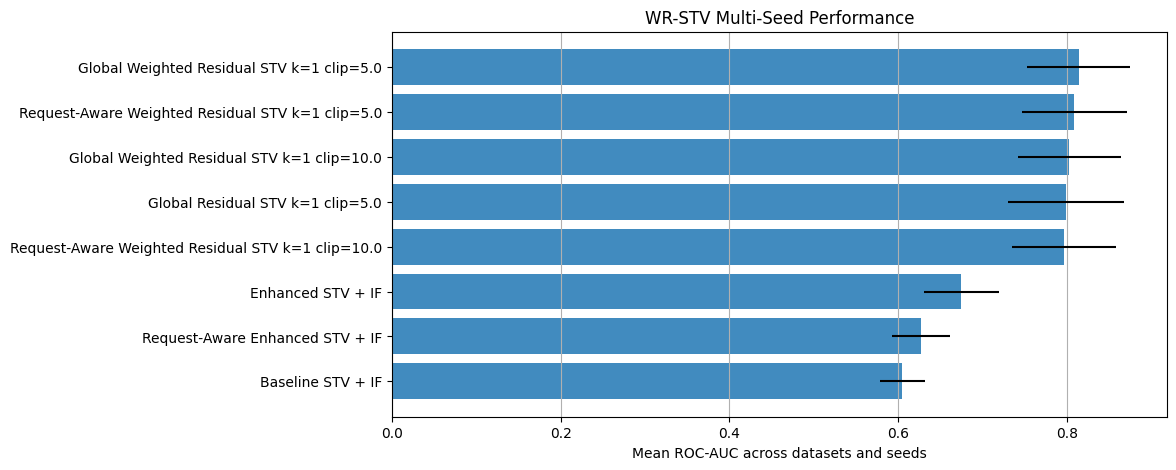

In [32]:
plot_df = paper_key_summary.sort_values("roc_auc_mean", ascending=True)

plt.figure(figsize=(10, 5))

plt.barh(
    plot_df["method"],
    plot_df["roc_auc_mean"],
    xerr=plot_df["roc_auc_std"],
    alpha=0.85
)

plt.xlabel("Mean ROC-AUC across datasets and seeds")
plt.title("WR-STV Multi-Seed Performance")
plt.grid(axis="x")
plt.show()



STV COVERAGE ANALYSIS

In [33]:
def compute_stv_coverage(
    events_df: pd.DataFrame,
    key_to_idx: dict
) -> dict[str, Any]:
    """
    Computes how much of a test dataset's STV events are covered by the
    training vocabulary.

    This is crucial for cross-dataset evaluation.
    If many service-paths are unseen, WR-STV cannot score them directly.
    """
    total_events = len(events_df)

    if total_events == 0:
        return {
            "total_events": 0,
            "visible_events": 0,
            "unseen_events": 0,
            "visible_event_ratio": np.nan,
            "unseen_event_ratio": np.nan,
            "unique_keys": 0,
            "visible_unique_keys": 0,
            "unseen_unique_keys": 0,
            "visible_unique_key_ratio": np.nan,
            "unseen_unique_key_ratio": np.nan,
        }

    keys = list(zip(events_df["serviceName"], events_df["service_path"]))
    visible_mask = [key in key_to_idx for key in keys]

    visible_events = int(np.sum(visible_mask))
    unseen_events = total_events - visible_events

    unique_keys = set(keys)
    visible_unique_keys = {key for key in unique_keys if key in key_to_idx}
    unseen_unique_keys = unique_keys - visible_unique_keys

    return {
        "total_events": total_events,
        "visible_events": visible_events,
        "unseen_events": unseen_events,
        "visible_event_ratio": visible_events / total_events,
        "unseen_event_ratio": unseen_events / total_events,
        "unique_keys": len(unique_keys),
        "visible_unique_keys": len(visible_unique_keys),
        "unseen_unique_keys": len(unseen_unique_keys),
        "visible_unique_key_ratio": len(visible_unique_keys) / len(unique_keys) if unique_keys else np.nan,
        "unseen_unique_key_ratio": len(unseen_unique_keys) / len(unique_keys) if unique_keys else np.nan,
    }

In [34]:
# CROSS DATASET SYNTHETIC EXPERIMENT

from dataclasses import dataclass


@dataclass
class ExperimentConfig:
    injection_factor: float
    max_spans_to_modify: int
    isolation_forest_estimators: int
    clip_values: tuple
    topk_values: tuple
    test_size: float = 0.35
    min_request_train_samples: int = 3

def align_eval_metadata(eval_trace_ids, base_meta_df):
    """Utility to align metadata rows with the eval STV matrix rows."""
    meta_indexed = base_meta_df.set_index("traceID")
    rows = []
    for tid in eval_trace_ids:
        tid_str = str(tid)
        original_tid = tid_str.replace("_inj_latency_v2", "")
        row = meta_indexed.loc[original_tid].to_dict()
        row["traceID"] = tid_str
        row["original_traceID"] = original_tid
        row["is_injected"] = tid_str.endswith("_inj_latency_v2")
        rows.append(row)
    return pd.DataFrame(rows)

def run_cross_dataset_synthetic_experiment(
    train_dataset: str,
    test_dataset: str,
    train_events: pd.DataFrame,
    test_events: pd.DataFrame,
    test_meta: pd.DataFrame,
    random_state: int,
    config: ExperimentConfig,
) -> dict[str, Any]:
    # Cross-dataset evaluation always uses the largest-visible injection
    # (create_latency_injected_events_v2); there is a separate random-visible
    # sensitivity study elsewhere in this notebook.
    # 1. Build train vocabulary
    _, key_to_idx = build_stv_vocab_from_events(train_events)

    # 2. Coverage before injection
    coverage = compute_stv_coverage(test_events, key_to_idx)

    # 3. Inject anomalies into test dataset
    test_trace_ids = sorted(test_events["traceID"].unique())

    injected_events, injection_details = create_latency_injected_events_v2(
        events_df=test_events,
        trace_ids_to_inject=test_trace_ids,
        key_to_idx=key_to_idx,
        factor=config.injection_factor,
        max_spans_to_modify=config.max_spans_to_modify,
    )

    test_normal_labeled = test_events.copy()
    test_normal_labeled["injected_anomaly_type"] = "normal"

    eval_events = pd.concat(
        [test_normal_labeled, injected_events],
        ignore_index=True
    )

    # 4. Build train/eval STV matrices
    train_trace_ids, x_train_base = events_to_stv_matrix_agg(train_events, key_to_idx)
    eval_trace_ids, x_eval_base = events_to_stv_matrix_agg(eval_events, key_to_idx)

    y_eval = np.array([
        1 if str(tid).endswith("_inj_latency_v2") else 0
        for tid in eval_trace_ids
    ])

    if y_eval.sum() == 0:
        return {"results_df": pd.DataFrame(), "coverage": coverage, "injection_details": injection_details, "pairwise_tables": {}}

    # 5. Align metadata
    eval_meta = align_eval_metadata(eval_trace_ids, test_meta)

    # 6. Baseline STV + IF
    base_model = IsolationForest(n_estimators=config.isolation_forest_estimators, contamination="auto", random_state=random_state)
    base_model.fit(x_train_base)
    base_scores = -base_model.score_samples(x_eval_base)

    # 7. Feature stats and residuals
    feature_means, feature_stds, feature_counts = compute_feature_stats_from_train(x_train_base)
    feature_weights = build_reliability_weights(feature_counts)

    x_train_res = transform_to_residual_stv(x_train_base, feature_means, feature_stds, clip_value=5.0)
    x_eval_res_for_if = transform_to_residual_stv(x_eval_base, feature_means, feature_stds, clip_value=5.0)

    # 8. Enhanced STV + IF
    enhanced_model = IsolationForest(n_estimators=config.isolation_forest_estimators, contamination="auto", random_state=random_state)
    enhanced_model.fit(x_train_res)
    enhanced_scores = -enhanced_model.score_samples(x_eval_res_for_if)

    # 9. Residual methods
    method_scores = {"Baseline STV + IF": base_scores, "Enhanced STV + IF": enhanced_scores}

    for clip_value in config.clip_values:
        x_eval_global_res = transform_to_residual_stv(x_eval_base, feature_means, feature_stds, clip_value=clip_value)
        for k in config.topk_values:
            method_scores[f"Global Residual STV k={k} clip={clip_value}"] = topk_abs_residual_score(x_eval_global_res, k=k)
            method_scores[f"Global Weighted Residual STV k={k} clip={clip_value}"] = weighted_topk_abs_residual_score(x_eval_global_res, feature_weights, k=k)

    # 10. Evaluate
    result_rows = []
    pairwise_tables = {}
    for method, scores in method_scores.items():
        row = evaluate_scores(method, y_eval, scores)
        win_rate, pair_df = pairwise_win_rate(eval_trace_ids, scores)
        row.update({"pairwise_win_rate": win_rate, "train_dataset": train_dataset, "test_dataset": test_dataset, "random_seed": random_state, "injection_factor": config.injection_factor, "num_train_traces": len(train_trace_ids), "num_test_normal": int((y_eval == 0).sum()), "num_test_injected": int((y_eval == 1).sum()), "stv_vocab_size": len(key_to_idx), **coverage})
        result_rows.append(row)
        pairwise_tables[method] = pair_df

    results_df = pd.DataFrame(result_rows).sort_values(by=["roc_auc", "pairwise_win_rate"], ascending=False)
    return {"results_df": results_df, "coverage": coverage, "injection_details": injection_details, "pairwise_tables": pairwise_tables, "eval_trace_ids": eval_trace_ids, "y_eval": y_eval, "eval_meta": eval_meta, "method_scores": method_scores, "feature_means":feature_means,"feature_stds": feature_stds,"feature_counts":feature_counts,"feature_weights":feature_weights,"eval_vocab":list(key_to_idx.keys()),"eval_key_to_idx":key_to_idx,"X_eval_base":x_eval_base,}

In [35]:
def run_all_cross_dataset_experiments(
    event_dfs: dict[str, pd.DataFrame],
    meta_dfs: dict[str, pd.DataFrame],
    seeds: list[int],
    config: ExperimentConfig,
) -> tuple[pd.DataFrame, pd.DataFrame, dict[str, Any]]:
    """
    Runs train_dataset -> test_dataset experiments for all distinct pairs.
    """

    all_results = []
    all_coverage = []
    outputs = {}

    dataset_keys = list(event_dfs.keys())

    for seed in seeds:
        print(f"\n[CROSS-SEED] {seed}")

        for train_ds in dataset_keys:
            for test_ds in dataset_keys:
                if train_ds == test_ds:
                    continue

                print(f"[CROSS-RUN] train={train_ds}, test={test_ds}, seed={seed}")

                # Now using the updated version of run_cross_dataset_synthetic_experiment
                # which returns X_eval_base, feature_means, weights, etc.
                out = run_cross_dataset_synthetic_experiment(
                    train_dataset=train_ds,
                    test_dataset=test_ds,
                    train_events=event_dfs[train_ds],
                    test_events=event_dfs[test_ds],
                    test_meta=meta_dfs[test_ds],
                    random_state=seed,
                    config=config,
                )

                key = f"train_{train_ds}_test_{test_ds}_seed_{seed}"
                outputs[key] = out

                if not out["results_df"].empty:
                    all_results.append(out["results_df"])

                cov_row = {
                    "train_dataset": train_ds,
                    "test_dataset": test_ds,
                    "random_seed": seed,
                    "injection_factor": config.injection_factor,
                    **out["coverage"],
                }
                all_coverage.append(cov_row)

    results_df = pd.concat(all_results, ignore_index=True) if all_results else pd.DataFrame()
    coverage_df = pd.DataFrame(all_coverage)

    return results_df, coverage_df, outputs

cross_config = ExperimentConfig(
    injection_factor=30.0,
    max_spans_to_modify=3,
    clip_values=(5.0, 10.0),
    topk_values=(1, 3, 5),
    isolation_forest_estimators=200,
)

CROSS_SEEDS = [0, 1, 2, 3, 4]

# Mapping internal variable names correctly to trigger the fresh run
cross_results_df, cross_coverage_df, cross_outputs = run_all_cross_dataset_experiments(
    event_dfs=stv_event_dfs,
    meta_dfs=trace_meta,
    seeds=CROSS_SEEDS,
    config=cross_config,
)

display(cross_results_df.head())
display(cross_coverage_df.head())


[CROSS-SEED] 0
[CROSS-RUN] train=dataset_1, test=dataset_2, seed=0
[CROSS-RUN] train=dataset_1, test=dataset_3, seed=0
[CROSS-RUN] train=dataset_2, test=dataset_1, seed=0
[CROSS-RUN] train=dataset_2, test=dataset_3, seed=0
[CROSS-RUN] train=dataset_3, test=dataset_1, seed=0
[CROSS-RUN] train=dataset_3, test=dataset_2, seed=0

[CROSS-SEED] 1
[CROSS-RUN] train=dataset_1, test=dataset_2, seed=1
[CROSS-RUN] train=dataset_1, test=dataset_3, seed=1
[CROSS-RUN] train=dataset_2, test=dataset_1, seed=1
[CROSS-RUN] train=dataset_2, test=dataset_3, seed=1
[CROSS-RUN] train=dataset_3, test=dataset_1, seed=1
[CROSS-RUN] train=dataset_3, test=dataset_2, seed=1

[CROSS-SEED] 2
[CROSS-RUN] train=dataset_1, test=dataset_2, seed=2
[CROSS-RUN] train=dataset_1, test=dataset_3, seed=2
[CROSS-RUN] train=dataset_2, test=dataset_1, seed=2
[CROSS-RUN] train=dataset_2, test=dataset_3, seed=2
[CROSS-RUN] train=dataset_3, test=dataset_1, seed=2
[CROSS-RUN] train=dataset_3, test=dataset_2, seed=2

[CROSS-SEED] 3


,method,roc_auc,average_precision,precision_at_k,precision,recall,f1,pairwise_win_rate,train_dataset,test_dataset,...,total_events,visible_events,unseen_events,visible_event_ratio,unseen_event_ratio,unique_keys,visible_unique_keys,unseen_unique_keys,visible_unique_key_ratio,unseen_unique_key_ratio
0,Global Weighted Residual STV k=1 clip=5.0,0.890629,0.888199,0.800000,0.800000,0.800000,0.800000,0.964706,dataset_1,dataset_2,...,1306,1157,149,0.885911,0.114089,190,141,49,0.742105,0.257895
1,Global Weighted Residual STV k=1 clip=10.0,0.887620,0.885592,0.800000,0.800000,0.800000,0.800000,0.964706,dataset_1,dataset_2,...,1306,1157,149,0.885911,0.114089,190,141,49,0.742105,0.257895
2,Global Residual STV k=1 clip=5.0,0.884200,0.848506,0.835294,0.835294,0.835294,0.835294,0.929412,dataset_1,dataset_2,...,1306,1157,149,0.885911,0.114089,190,141,49,0.742105,0.257895
3,Global Residual STV k=1 clip=10.0,0.877291,0.810853,0.835294,0.835294,0.835294,0.835294,0.952941,dataset_1,dataset_2,...,1306,1157,149,0.885911,0.114089,190,141,49,0.742105,0.257895
4,Global Weighted Residual STV k=3 clip=10.0,0.836252,0.856722,0.729412,0.729412,0.729412,0.729412,0.988235,dataset_1,dataset_2,...,1306,1157,149,0.885911,0.114089,190,141,49,0.742105,0.257895


,train_dataset,test_dataset,random_seed,injection_factor,total_events,visible_events,unseen_events,visible_event_ratio,unseen_event_ratio,unique_keys,visible_unique_keys,unseen_unique_keys,visible_unique_key_ratio,unseen_unique_key_ratio
0,dataset_1,dataset_2,0,30.0,1306,1157,149,0.885911,0.114089,190,141,49,0.742105,0.257895
1,dataset_1,dataset_3,0,30.0,1993,1831,162,0.918716,0.081284,181,128,53,0.707182,0.292818
2,dataset_2,dataset_1,0,30.0,3788,3704,84,0.977825,0.022175,150,141,9,0.940000,0.060000
3,dataset_2,dataset_3,0,30.0,1993,1977,16,0.991972,0.008028,181,175,6,0.966851,0.033149
4,dataset_3,dataset_1,0,30.0,3788,3534,254,0.932946,0.067054,150,128,22,0.853333,0.146667


In [36]:

cross_method_summary_df = (
    cross_results_df
    .groupby("method")
    .agg(
        roc_auc_mean=("roc_auc", "mean"),
        roc_auc_std=("roc_auc", "std"),
        average_precision_mean=("average_precision", "mean"),
        average_precision_std=("average_precision", "std"),
        f1_mean=("f1", "mean"),
        f1_std=("f1", "std"),
        precision_at_k_mean=("precision_at_k", "mean"),
        precision_at_k_std=("precision_at_k", "std"),
        pairwise_win_rate_mean=("pairwise_win_rate", "mean"),
        pairwise_win_rate_std=("pairwise_win_rate", "std"),
        visible_event_ratio_mean=("visible_event_ratio", "mean"),
        unseen_event_ratio_mean=("unseen_event_ratio", "mean"),
        runs=("roc_auc", "count"),
    )
    .reset_index()
    .sort_values(
        by=["roc_auc_mean", "pairwise_win_rate_mean"],
        ascending=False
    )
)

display(cross_method_summary_df)

,method,roc_auc_mean,roc_auc_std,average_precision_mean,average_precision_std,f1_mean,f1_std,precision_at_k_mean,precision_at_k_std,pairwise_win_rate_mean,pairwise_win_rate_std,visible_event_ratio_mean,unseen_event_ratio_mean,runs
9,Global Weighted Residual STV k=1 clip=5.0,0.803339,0.100875,0.804336,0.089800,0.722065,0.079696,0.722065,0.079696,0.775141,0.153858,0.943699,0.056301,30
3,Global Residual STV k=1 clip=5.0,0.794311,0.108797,0.732391,0.117669,0.740407,0.095787,0.740407,0.095787,0.757282,0.156535,0.943699,0.056301,30
8,Global Weighted Residual STV k=1 clip=10.0,0.791234,0.104646,0.764140,0.110989,0.725271,0.082569,0.725271,0.082569,0.769265,0.160936,0.943699,0.056301,30
2,Global Residual STV k=1 clip=10.0,0.790987,0.107112,0.714031,0.107529,0.740407,0.095787,0.740407,0.095787,0.767154,0.160353,0.943699,0.056301,30
5,Global Residual STV k=3 clip=5.0,0.768741,0.091863,0.723404,0.095263,0.703385,0.070314,0.703385,0.070314,0.802436,0.141873,0.943699,0.056301,30
11,Global Weighted Residual STV k=3 clip=5.0,0.765604,0.086435,0.777053,0.074911,0.694243,0.065630,0.694243,0.065630,0.809762,0.134767,0.943699,0.056301,30
4,Global Residual STV k=3 clip=10.0,0.765042,0.093784,0.713137,0.098941,0.705346,0.070865,0.705346,0.070865,0.808105,0.143567,0.943699,0.056301,30
10,Global Weighted Residual STV k=3 clip=10.0,0.760889,0.089828,0.743130,0.093061,0.693792,0.067518,0.693792,0.067518,0.812632,0.137759,0.943699,0.056301,30
7,Global Residual STV k=5 clip=5.0,0.754497,0.088056,0.691027,0.074411,0.696639,0.064179,0.696639,0.064179,0.820262,0.136440,0.943699,0.056301,30
6,Global Residual STV k=5 clip=10.0,0.754073,0.090827,0.693665,0.086408,0.702522,0.066411,0.702522,0.066411,0.825931,0.138361,0.943699,0.056301,30


In [37]:
cross_pair_summary_df = (
    cross_results_df
    .groupby(["train_dataset", "test_dataset", "method"])
    .agg(
        roc_auc_mean=("roc_auc", "mean"),
        roc_auc_std=("roc_auc", "std"),
        average_precision_mean=("average_precision", "mean"),
        f1_mean=("f1", "mean"),
        pairwise_win_rate_mean=("pairwise_win_rate", "mean"),
        visible_event_ratio_mean=("visible_event_ratio", "mean"),
        unseen_event_ratio_mean=("unseen_event_ratio", "mean"),
        runs=("roc_auc", "count"),
    )
    .reset_index()
    .sort_values(
        by=["train_dataset", "test_dataset", "roc_auc_mean"],
        ascending=[True, True, False],
    )
)

display(cross_pair_summary_df.head(50))

,train_dataset,test_dataset,method,roc_auc_mean,roc_auc_std,average_precision_mean,f1_mean,pairwise_win_rate_mean,visible_event_ratio_mean,unseen_event_ratio_mean,runs
9,dataset_1,dataset_2,Global Weighted Residual STV k=1 clip=5.0,0.890629,0.000000,0.888199,0.800000,0.964706,0.885911,0.114089,5
8,dataset_1,dataset_2,Global Weighted Residual STV k=1 clip=10.0,0.887620,0.000000,0.885592,0.800000,0.964706,0.885911,0.114089,5
3,dataset_1,dataset_2,Global Residual STV k=1 clip=5.0,0.884200,0.000000,0.848506,0.835294,0.929412,0.885911,0.114089,5
2,dataset_1,dataset_2,Global Residual STV k=1 clip=10.0,0.877291,0.000000,0.810853,0.835294,0.952941,0.885911,0.114089,5
10,dataset_1,dataset_2,Global Weighted Residual STV k=3 clip=10.0,0.836252,0.000000,0.856722,0.729412,0.988235,0.885911,0.114089,5
5,dataset_1,dataset_2,Global Residual STV k=3 clip=5.0,0.833379,0.000000,0.849791,0.717647,0.988235,0.885911,0.114089,5
11,dataset_1,dataset_2,Global Weighted Residual STV k=3 clip=5.0,0.830643,0.000000,0.847456,0.741176,0.988235,0.885911,0.114089,5
4,dataset_1,dataset_2,Global Residual STV k=3 clip=10.0,0.828865,0.000000,0.836548,0.729412,0.988235,0.885911,0.114089,5
12,dataset_1,dataset_2,Global Weighted Residual STV k=5 clip=10.0,0.819152,0.000000,0.828155,0.729412,0.988235,0.885911,0.114089,5
13,dataset_1,dataset_2,Global Weighted Residual STV k=5 clip=5.0,0.815321,0.000000,0.823547,0.717647,0.988235,0.885911,0.114089,5


In [38]:
CROSS_KEY_METHODS = [
    "Baseline STV + IF",
    "Enhanced STV + IF",
    "Global Residual STV k=1 clip=5.0",
    "Global Weighted Residual STV k=1 clip=5.0",
    "Global Weighted Residual STV k=1 clip=10.0",
]

cross_key_summary_df = cross_method_summary_df[
    cross_method_summary_df["method"].isin(CROSS_KEY_METHODS)
].copy()

cross_key_summary_df = cross_key_summary_df.sort_values(
    by="roc_auc_mean",
    ascending=False
)

display(cross_key_summary_df)

,method,roc_auc_mean,roc_auc_std,average_precision_mean,average_precision_std,f1_mean,f1_std,precision_at_k_mean,precision_at_k_std,pairwise_win_rate_mean,pairwise_win_rate_std,visible_event_ratio_mean,unseen_event_ratio_mean,runs
9,Global Weighted Residual STV k=1 clip=5.0,0.803339,0.100875,0.804336,0.089800,0.722065,0.079696,0.722065,0.079696,0.775141,0.153858,0.943699,0.056301,30
3,Global Residual STV k=1 clip=5.0,0.794311,0.108797,0.732391,0.117669,0.740407,0.095787,0.740407,0.095787,0.757282,0.156535,0.943699,0.056301,30
8,Global Weighted Residual STV k=1 clip=10.0,0.791234,0.104646,0.764140,0.110989,0.725271,0.082569,0.725271,0.082569,0.769265,0.160936,0.943699,0.056301,30
1,Enhanced STV + IF,0.689561,0.063135,0.618377,0.046762,0.646720,0.047440,0.646720,0.047440,0.742041,0.090336,0.943699,0.056301,30
0,Baseline STV + IF,0.621832,0.025097,0.573319,0.015949,0.602190,0.035605,0.602190,0.035605,0.888593,0.046907,0.943699,0.056301,30


In [39]:
cross_results_df.to_csv(RESULTS_DIR / "cross_dataset_all_results.csv", index=False)
cross_coverage_df.to_csv(RESULTS_DIR / "cross_dataset_stv_coverage.csv", index=False)
cross_method_summary_df.to_csv(RESULTS_DIR / "cross_dataset_summary_by_method.csv", index=False)
cross_pair_summary_df.to_csv(RESULTS_DIR / "cross_dataset_summary_by_pair_method.csv", index=False)
cross_key_summary_df.to_csv(RESULTS_DIR / "cross_dataset_key_methods_summary.csv", index=False)

print("Saved cross-dataset results to:", RESULTS_DIR)

Saved cross-dataset results to: /content/drive/MyDrive/anomalies_microservice_trainticket_version_configurations/_processed_phase1/paper_experiment_results


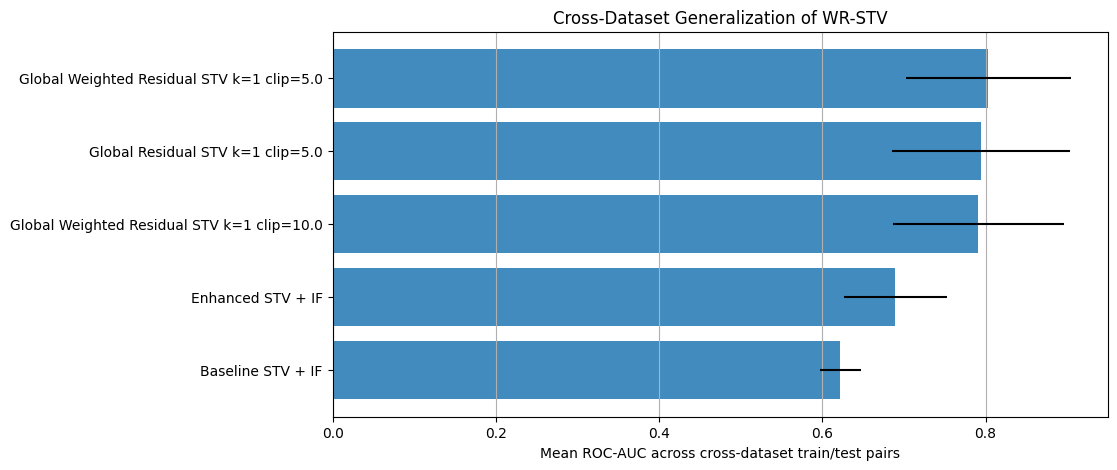

In [40]:
plot_df = cross_key_summary_df.sort_values("roc_auc_mean", ascending=True)

plt.figure(figsize=(10, 5))
plt.barh(
    plot_df["method"],
    plot_df["roc_auc_mean"],
    xerr=plot_df["roc_auc_std"],
    alpha=0.85
)

plt.xlabel("Mean ROC-AUC across cross-dataset train/test pairs")
plt.title("Cross-Dataset Generalization of WR-STV")
plt.grid(axis="x")
plt.show()



Research Question:
Can WR-STV explain which service-path caused an anomaly?

Hypothesis:
The highest weighted residual contributors should correspond to abnormal injected service-path durations.

Reviewer Benefit:
This shows WR-STV is interpretable, not just a score generator.

Expected Output:
A ranked table of service-path residual contributions for a trace.

In [41]:
def explain_wrstv_trace(
    trace_id,
    eval_trace_ids,
    X_eval_base,
    eval_vocab,
    feature_means,
    feature_stds,
    feature_weights,
    eval_meta=None,
    top_k=10,
    missing_value=-1.0,
    clip_value=5.0,
):
    """
    Explain a WR-STV anomaly score for one trace.

    For each active STV feature:
        observed_log_duration = STV value
        residual = (observed - train_mean) / train_std
        weighted_contribution = abs(residual) * feature_weight

    Returns:
        DataFrame ranked by weighted contribution.
    """

    if trace_id not in eval_trace_ids:
        raise ValueError(f"trace_id not found in eval_trace_ids: {trace_id}")

    row_idx = eval_trace_ids.index(trace_id)
    x = X_eval_base[row_idx]

    active_idx = np.where(x != missing_value)[0]

    rows = []

    for j in active_idx:
        service, path = eval_vocab[j]

        observed_log_duration = float(x[j])
        train_mean = float(feature_means[j])
        train_std = float(feature_stds[j])
        weight = float(feature_weights[j])

        if train_std < 1e-8:
            residual = 0.0
        else:
            residual = (observed_log_duration - train_mean) / train_std

        residual_clipped = float(np.clip(residual, -clip_value, clip_value))
        abs_residual = abs(residual_clipped)
        weighted_contribution = abs_residual * weight

        rows.append({
            "feature_index": int(j),
            "service": str(service),
            "service_path": " -> ".join(path),
            "path_length": len(path),
            "observed_log_duration": observed_log_duration,
            "observed_duration_approx": float(np.expm1(observed_log_duration)),
            "train_mean_log_duration": train_mean,
            "train_std_log_duration": train_std,
            "residual": residual,
            "residual_clipped": residual_clipped,
            "abs_residual": abs_residual,
            "feature_weight": weight,
            "weighted_contribution": weighted_contribution,
        })

    explanation_df = pd.DataFrame(rows)

    if explanation_df.empty:
        return explanation_df

    explanation_df = explanation_df.sort_values(
        "weighted_contribution",
        ascending=False
    ).reset_index(drop=True)

    explanation_df["rank"] = np.arange(1, len(explanation_df) + 1)

    # Optional metadata
    if eval_meta is not None:
        meta_row = eval_meta[eval_meta["traceID"].astype(str) == str(trace_id)]
        if not meta_row.empty:
            meta_row = meta_row.iloc[0]
            explanation_df["traceID"] = trace_id
            explanation_df["root_operation"] = meta_row.get("root_operation", None)
            explanation_df["num_spans"] = meta_row.get("num_spans", None)
            explanation_df["num_services"] = meta_row.get("num_services", None)
            explanation_df["is_injected"] = meta_row.get("is_injected", None)

    cols_front = [
        "rank",
        "traceID",
        "is_injected",
        "root_operation",
        "service",
        "service_path",
        "observed_duration_approx",
        "residual_clipped",
        "feature_weight",
        "weighted_contribution",
    ]

    existing_front = [c for c in cols_front if c in explanation_df.columns]
    remaining = [c for c in explanation_df.columns if c not in existing_front]

    return explanation_df[existing_front + remaining].head(top_k)


In [42]:
def top_scored_traces(
    eval_trace_ids,
    y_eval,
    scores,
    eval_meta=None,
    top_k=10
):
    """
    Return top scored traces with labels and metadata.
    """

    df = pd.DataFrame({
        "traceID": eval_trace_ids,
        "label": y_eval,
        "score": scores,
    })

    if eval_meta is not None:
        keep_cols = [
            "traceID",
            "original_traceID",
            "root_operation",
            "num_spans",
            "num_services",
            "is_injected"
        ]
        available = [c for c in keep_cols if c in eval_meta.columns]
        df = df.merge(eval_meta[available], on="traceID", how="left")

    return df.sort_values("score", ascending=False).head(top_k)

# Choose an output containing the required interpretability keys
valid_keys = [k for k, v in cross_outputs.items() if "X_eval_base" in v]
if not valid_keys:
    # Fallback to the latest seed run from the last experiment execution if cross_outputs is inconsistent
    example_key = list(cross_outputs.keys())[-1]
    out = cross_outputs[example_key]
else:
    example_key = valid_keys[0]
    out = cross_outputs[example_key]

method_name = "Global Weighted Residual STV k=1 clip=5.0"
if method_name in out["method_scores"]:
    scores = out["method_scores"][method_name]

    top_df = top_scored_traces(
        eval_trace_ids=out["eval_trace_ids"],
        y_eval=out["y_eval"],
        scores=scores,
        eval_meta=out["eval_meta"],
        top_k=10
    )

    print(f"Top traces for method: {method_name} (Experiment: {example_key})")
    display(top_df)

    # Pick the top-scoring injected trace for explanation
    top_injected = top_df[top_df["label"] == 1]
    if not top_injected.empty:
        top_trace_id = top_injected.iloc[0]["traceID"]
    else:
        top_trace_id = top_df.iloc[0]["traceID"]

    explanation = explain_wrstv_trace(
        trace_id=top_trace_id,
        eval_trace_ids=out["eval_trace_ids"],
        X_eval_base=out["X_eval_base"],
        eval_vocab=out["eval_vocab"],
        feature_means=out["feature_means"],
        feature_stds=out["feature_stds"],
        feature_weights=out["feature_weights"],
        eval_meta=out["eval_meta"],
        top_k=10,
        clip_value=5.0
    )

    print(f"\nWR-STV Contribution Explanation for Trace: {top_trace_id}")
    display(explanation)
else:
    print(f"Method {method_name} not found in output keys.")

Top traces for method: Global Weighted Residual STV k=1 clip=5.0 (Experiment: train_dataset_1_test_dataset_2_seed_0)


,traceID,label,score,original_traceID,root_operation,num_spans,num_services,is_injected
1,0915ee7798c08138_inj_latency_v2,1,5.0,0915ee7798c08138,deleteConfig,3,2,True
5,09bd020ecb37a825_inj_latency_v2,1,5.0,09bd020ecb37a825,addStation,3,2,True
29,2b0431b78df04d9b_inj_latency_v2,1,5.0,2b0431b78df04d9b,modifyContacts,3,2,True
33,34a34c92383ae5f0_inj_latency_v2,1,5.0,34a34c92383ae5f0,getAllPrices,3,2,True
27,2a43c7464ad87899_inj_latency_v2,1,5.0,2a43c7464ad87899,addContacts,3,2,True
151,de4ff8cd77f13dd7_inj_latency_v2,1,5.0,de4ff8cd77f13dd7,addTrain,3,2,True
161,eba5a3617d53a2c7_inj_latency_v2,1,5.0,eba5a3617d53a2c7,modifyConfig,3,2,True
147,db8863878702f6a4_inj_latency_v2,1,5.0,db8863878702f6a4,deleteContacts,3,2,True
141,d44b91c0fce82d26_inj_latency_v2,1,5.0,d44b91c0fce82d26,addPrice,3,2,True
99,92b2c88e5bbd7a28_inj_latency_v2,1,5.0,92b2c88e5bbd7a28,getAllContacts,3,2,True



WR-STV Contribution Explanation for Trace: 0915ee7798c08138_inj_latency_v2


,rank,traceID,is_injected,root_operation,service,service_path,observed_duration_approx,residual_clipped,feature_weight,weighted_contribution,feature_index,path_length,observed_log_duration,train_mean_log_duration,train_std_log_duration,residual,abs_residual,num_spans,num_services
0,1,0915ee7798c08138_inj_latency_v2,True,deleteConfig,ts-admin-basic-info-service,ts-admin-basic-info-service,1.316969e+07,5.000000,1.000000,5.000000,1,1,16.393429,12.191497,0.760525,5.525039,5.000000,3,2
1,2,0915ee7798c08138_inj_latency_v2,True,deleteConfig,ts-admin-basic-info-service,ts-admin-basic-info-service -> ts-admin-basic-...,1.224753e+07,4.612201,1.000000,4.612201,0,2,16.320835,11.430722,1.060256,4.612201,4.612201,3,2
2,3,0915ee7798c08138_inj_latency_v2,True,deleteConfig,ts-config-service,ts-admin-basic-info-service -> ts-admin-basic-...,1.205498e+07,4.399772,0.604883,2.661347,22,3,16.304989,10.907726,1.226714,4.399772,4.399772,3,2


In [43]:
def get_injection_detail_for_trace(injection_details, injected_trace_id):
    """
    Return injection detail row for a given injected trace.
    """

    if injection_details is None or injection_details.empty:
        return None

    row = injection_details[
        injection_details["injected_traceID"].astype(str) == str(injected_trace_id)
    ]

    if row.empty:
        return None

    return row.iloc[0].to_dict()

inj_detail = get_injection_detail_for_trace(
    out["injection_details"],
    top_trace_id
)

print("Injected trace:", top_trace_id)

if inj_detail is not None:
    print("Modified services:")
    print(inj_detail["modified_services"])

    print("\nModified operations:")
    print(inj_detail["modified_operations"])

    print("\nModified paths:")
    print(inj_detail["modified_paths"])

    print("\nBefore durations:")
    print(inj_detail["before_durations"])

    print("\nAfter durations:")
    print(inj_detail["after_durations"])
else:
    print("No injection detail found. This may be a normal trace.")

Injected trace: 0915ee7798c08138_inj_latency_v2
Modified services:
['ts-admin-basic-info-service', 'ts-admin-basic-info-service', 'ts-config-service']

Modified operations:
['deleteConfig', 'DELETE', 'deleteConfig']

Modified paths:
[('ts-admin-basic-info-service',), ('ts-admin-basic-info-service', 'ts-admin-basic-info-service'), ('ts-admin-basic-info-service', 'ts-admin-basic-info-service', 'ts-config-service')]

Before durations:
[438990, 408251, 401833]

After durations:
[13169700.0, 12247530.0, 12054990.0]


In [44]:
def explanation_injection_overlap(
    explanation_df,
    injection_detail,
    top_k=5
):
    """
    Measures whether top explanation services overlap with injected services.
    """
    if injection_detail is None or explanation_df is None or explanation_df.empty:
        return {
            "top_k": top_k,
            "overlap_count": 0,
            "overlap_ratio": 0.0,
            "explained_services": [],
            "injected_services": []
        }

    explained_services = set(
        explanation_df.head(top_k)["service"].astype(str).tolist()
    )

    injected_services = set(
        [str(x) for x in injection_detail.get("modified_services", [])]
    )

    overlap = explained_services.intersection(injected_services)

    return {
        "top_k": top_k,
        "overlap_count": len(overlap),
        "overlap_ratio": len(overlap) / len(injected_services) if injected_services else 0.0,
        "explained_services": sorted(explained_services),
        "injected_services": sorted(injected_services),
        "overlap_services": sorted(overlap),
    }

# Check that the single-trace explanation was computed above
if 'explanation' in globals():
    overlap_result = explanation_injection_overlap(
        explanation,
        inj_detail,
        top_k=5
    )
    print("Interpretability Validation Results:")
    display(pd.Series(overlap_result))
else:
    print("Error: 'explanation' variable not found. Run the single-trace explanation cell above first.")

Interpretability Validation Results:


,0
top_k,5
overlap_count,2
overlap_ratio,1.0
explained_services,"[ts-admin-basic-info-service, ts-config-service]"
injected_services,"[ts-admin-basic-info-service, ts-config-service]"
overlap_services,"[ts-admin-basic-info-service, ts-config-service]"


In [45]:
def batch_explain_top_injected(
    out,
    method_name="Global Weighted Residual STV k=1 clip=5.0",
    num_traces=5,
    explanation_top_k=5,
    clip_value=5.0
):
    """
    Explain top-scoring injected traces for one experiment output.
    """

    scores = out["method_scores"][method_name]

    top_df = top_scored_traces(
        eval_trace_ids=out["eval_trace_ids"],
        y_eval=out["y_eval"],
        scores=scores,
        eval_meta=out["eval_meta"],
        top_k=len(out["eval_trace_ids"])
    )

    top_injected = top_df[top_df["label"] == 1].head(num_traces)

    all_explanations = []
    all_overlap_rows = []

    for _, row in top_injected.iterrows():
        trace_id = row["traceID"]

        exp_df = explain_wrstv_trace(
            trace_id=trace_id,
            eval_trace_ids=out["eval_trace_ids"],
            X_eval_base=out["X_eval_base"],
            eval_vocab=out["eval_vocab"],
            feature_means=out["feature_means"],
            feature_stds=out["feature_stds"],
            feature_weights=out["feature_weights"],
            eval_meta=out["eval_meta"],
            top_k=explanation_top_k,
            clip_value=clip_value
        )

        exp_df["anomaly_score"] = row["score"]
        all_explanations.append(exp_df)

        inj_detail = get_injection_detail_for_trace(
            out["injection_details"],
            trace_id
        )

        overlap = explanation_injection_overlap(
            exp_df,
            inj_detail,
            top_k=explanation_top_k
        )

        overlap["traceID"] = trace_id
        overlap["anomaly_score"] = row["score"]
        overlap["root_operation"] = row.get("root_operation", None)
        all_overlap_rows.append(overlap)

    explanations_df = pd.concat(all_explanations, ignore_index=True) if all_explanations else pd.DataFrame()
    overlap_df = pd.DataFrame(all_overlap_rows)

    return explanations_df, overlap_df

example_key = list(cross_outputs.keys())[0]
out = cross_outputs[example_key]

explanations_df, overlap_df = batch_explain_top_injected(
    out,
    method_name="Global Weighted Residual STV k=1 clip=5.0",
    num_traces=5,
    explanation_top_k=5,
    clip_value=5.0
)

display(explanations_df)
display(overlap_df)

,rank,traceID,is_injected,root_operation,service,service_path,observed_duration_approx,residual_clipped,feature_weight,weighted_contribution,feature_index,path_length,observed_log_duration,train_mean_log_duration,train_std_log_duration,residual,abs_residual,num_spans,num_services,anomaly_score
0,1,0915ee7798c08138_inj_latency_v2,True,deleteConfig,ts-admin-basic-info-service,ts-admin-basic-info-service,1.316969e+07,5.000000,1.000000,5.000000,1,1,16.393429,12.191497,0.760525,5.525039,5.000000,3,2,5.0
1,2,0915ee7798c08138_inj_latency_v2,True,deleteConfig,ts-admin-basic-info-service,ts-admin-basic-info-service -> ts-admin-basic-...,1.224753e+07,4.612201,1.000000,4.612201,0,2,16.320835,11.430722,1.060256,4.612201,4.612201,3,2,5.0
2,3,0915ee7798c08138_inj_latency_v2,True,deleteConfig,ts-config-service,ts-admin-basic-info-service -> ts-admin-basic-...,1.205498e+07,4.399772,0.604883,2.661347,22,3,16.304989,10.907726,1.226714,4.399772,4.399772,3,2,5.0
3,1,09bd020ecb37a825_inj_latency_v2,True,addStation,ts-admin-basic-info-service,ts-admin-basic-info-service,1.092600e+07,5.000000,1.000000,5.000000,1,1,16.206656,12.191497,0.760525,5.279454,5.000000,3,2,5.0
4,2,09bd020ecb37a825_inj_latency_v2,True,addStation,ts-admin-basic-info-service,ts-admin-basic-info-service -> ts-admin-basic-...,7.529132e+06,4.153307,1.000000,4.153307,0,2,15.834291,11.430722,1.060256,4.153307,4.153307,3,2,5.0
5,3,09bd020ecb37a825_inj_latency_v2,True,addStation,ts-station-service,ts-admin-basic-info-service -> ts-admin-basic-...,7.375652e+06,4.761907,0.604883,2.880396,94,3,15.813695,10.693354,1.075271,4.761907,4.761907,3,2,5.0
6,1,2b0431b78df04d9b_inj_latency_v2,True,modifyContacts,ts-admin-basic-info-service,ts-admin-basic-info-service,1.583870e+07,5.000000,1.000000,5.000000,1,1,16.577967,12.191497,0.760525,5.767684,5.000000,3,2,5.0
7,2,2b0431b78df04d9b_inj_latency_v2,True,modifyContacts,ts-admin-basic-info-service,ts-admin-basic-info-service -> ts-admin-basic-...,7.804079e+06,4.187135,1.000000,4.187135,0,2,15.870157,11.430722,1.060256,4.187135,4.187135,3,2,5.0
8,3,2b0431b78df04d9b_inj_latency_v2,True,modifyContacts,ts-contacts-service,ts-admin-basic-info-service -> ts-admin-basic-...,1.051719e+07,5.000000,0.577205,2.886025,30,3,16.168522,11.813669,0.539107,8.077902,5.000000,3,2,5.0
9,1,34a34c92383ae5f0_inj_latency_v2,True,getAllPrices,ts-admin-basic-info-service,ts-admin-basic-info-service,1.204719e+07,5.000000,1.000000,5.000000,1,1,16.304342,12.191497,0.760525,5.407901,5.000000,3,2,5.0


,top_k,overlap_count,overlap_ratio,explained_services,injected_services,overlap_services,traceID,anomaly_score,root_operation
0,5,2,1.0,"[ts-admin-basic-info-service, ts-config-service]","[ts-admin-basic-info-service, ts-config-service]","[ts-admin-basic-info-service, ts-config-service]",0915ee7798c08138_inj_latency_v2,5.0,deleteConfig
1,5,2,1.0,"[ts-admin-basic-info-service, ts-station-service]","[ts-admin-basic-info-service, ts-station-service]","[ts-admin-basic-info-service, ts-station-service]",09bd020ecb37a825_inj_latency_v2,5.0,addStation
2,5,2,1.0,"[ts-admin-basic-info-service, ts-contacts-serv...","[ts-admin-basic-info-service, ts-contacts-serv...","[ts-admin-basic-info-service, ts-contacts-serv...",2b0431b78df04d9b_inj_latency_v2,5.0,modifyContacts
3,5,2,1.0,"[ts-admin-basic-info-service, ts-price-service]","[ts-admin-basic-info-service, ts-price-service]","[ts-admin-basic-info-service, ts-price-service]",34a34c92383ae5f0_inj_latency_v2,5.0,getAllPrices
4,5,2,1.0,"[ts-admin-basic-info-service, ts-contacts-serv...","[ts-admin-basic-info-service, ts-contacts-serv...","[ts-admin-basic-info-service, ts-contacts-serv...",2a43c7464ad87899_inj_latency_v2,5.0,addContacts


In [46]:
def get_pairwise_failures(
    out,
    method_name="Global Weighted Residual STV k=1 clip=5.0"
):
    """
    Return pairwise failures for a method.
    """

    if "pairwise_tables" not in out:
        raise ValueError("Output does not contain pairwise_tables.")

    pair_df = out["pairwise_tables"][method_name].copy()

    failures = pair_df[pair_df["win"] == False].sort_values("delta")

    return failures
failures = get_pairwise_failures(
    out,
    method_name="Global Weighted Residual STV k=1 clip=5.0"
)

display(failures.head(10))

failures = get_pairwise_failures(
    out,
    method_name="Global Weighted Residual STV k=1 clip=5.0"
)

display(failures.head(10))
if not failures.empty:
    failed_injected_trace = failures.iloc[0]["injected_traceID"]

    failure_explanation = explain_wrstv_trace(
        trace_id=failed_injected_trace,
        eval_trace_ids=out["eval_trace_ids"],
        X_eval_base=out["X_eval_base"],
        eval_vocab=out["eval_vocab"],
        feature_means=out["feature_means"],
        feature_stds=out["feature_stds"],
        feature_weights=out["feature_weights"],
        eval_meta=out["eval_meta"],
        top_k=10,
        clip_value=5.0
    )

    display(failure_explanation)

    failure_inj_detail = get_injection_detail_for_trace(
        out["injection_details"],
        failed_injected_trace
    )

    print(failure_inj_detail)
else:
    print("No pairwise failures for this output.")


,traceID,injected_traceID,normal_score,injected_score,delta,win
7,175aedae66c1f4c8,175aedae66c1f4c8_inj_latency_v2,1.121942,0.563347,-0.558594,False
34,729a65997299a40a,729a65997299a40a_inj_latency_v2,1.443012,1.443012,0.000000,False
67,cae66fa51aff79d3,cae66fa51aff79d3_inj_latency_v2,2.353452,2.353452,0.000000,False


,traceID,injected_traceID,normal_score,injected_score,delta,win
7,175aedae66c1f4c8,175aedae66c1f4c8_inj_latency_v2,1.121942,0.563347,-0.558594,False
34,729a65997299a40a,729a65997299a40a_inj_latency_v2,1.443012,1.443012,0.000000,False
67,cae66fa51aff79d3,cae66fa51aff79d3_inj_latency_v2,2.353452,2.353452,0.000000,False


,rank,traceID,is_injected,root_operation,service,service_path,observed_duration_approx,residual_clipped,feature_weight,weighted_contribution,feature_index,path_length,observed_log_duration,train_mean_log_duration,train_std_log_duration,residual,abs_residual,num_spans,num_services
0,1,175aedae66c1f4c8_inj_latency_v2,True,getOrderById,ts-order-service,ts-order-service,326339.888553,0.658198,0.855893,0.563347,53,1,12.695698,11.558798,1.727291,0.658198,0.658198,1,1


{'original_traceID': '175aedae66c1f4c8', 'injected_traceID': '175aedae66c1f4c8_inj_latency_v2', 'num_modified_spans': 1, 'factor': 30.0, 'modified_services': ['ts-order-service'], 'modified_operations': ['getOrderById'], 'modified_paths': [('ts-order-service',)], 'before_durations': [10878], 'after_durations': [326340.0]}


In [47]:
EXPLAIN_DIR = RESULTS_DIR / "explanations"
EXPLAIN_DIR.mkdir(exist_ok=True)

# Save example explanation tables
explanations_df.to_csv(
    EXPLAIN_DIR / "top_injected_wrstv_explanations.csv",
    index=False
)

overlap_df.to_csv(
    EXPLAIN_DIR / "top_injected_explanation_overlap.csv",
    index=False
)

print("Saved explanation tables to:", EXPLAIN_DIR)

Saved explanation tables to: /content/drive/MyDrive/anomalies_microservice_trainticket_version_configurations/_processed_phase1/paper_experiment_results/explanations


In [48]:
def explain_all_cross_outputs(
    cross_outputs,
    method_name="Global Weighted Residual STV k=1 clip=5.0",
    num_traces_per_run=3,
    explanation_top_k=5,
    clip_value=5.0
):
    all_exp = []
    all_overlap = []

    for key, out in cross_outputs.items():
        exp_df, overlap_df = batch_explain_top_injected(
            out,
            method_name=method_name,
            num_traces=num_traces_per_run,
            explanation_top_k=explanation_top_k,
            clip_value=clip_value
        )

        if not exp_df.empty:
            exp_df["experiment_key"] = key
            all_exp.append(exp_df)

        if not overlap_df.empty:
            overlap_df["experiment_key"] = key
            all_overlap.append(overlap_df)

    all_exp_df = pd.concat(all_exp, ignore_index=True) if all_exp else pd.DataFrame()
    all_overlap_df = pd.concat(all_overlap, ignore_index=True) if all_overlap else pd.DataFrame()

    return all_exp_df, all_overlap_df

all_exp_df, all_overlap_df = explain_all_cross_outputs(
    cross_outputs,
    method_name="Global Weighted Residual STV k=1 clip=5.0",
    num_traces_per_run=3,
    explanation_top_k=5,
    clip_value=5.0
)

display(all_exp_df.head(20))
display(all_overlap_df.head(20))

all_exp_df.to_csv(
    EXPLAIN_DIR / "all_cross_top_injected_explanations.csv",
    index=False
)

all_overlap_df.to_csv(
    EXPLAIN_DIR / "all_cross_explanation_overlap.csv",
    index=False
)

,rank,traceID,is_injected,root_operation,service,service_path,observed_duration_approx,residual_clipped,feature_weight,weighted_contribution,...,path_length,observed_log_duration,train_mean_log_duration,train_std_log_duration,residual,abs_residual,num_spans,num_services,anomaly_score,experiment_key
0,1,0915ee7798c08138_inj_latency_v2,True,deleteConfig,ts-admin-basic-info-service,ts-admin-basic-info-service,1.316969e+07,5.000000,1.000000,5.000000,...,1,16.393429,12.191497,0.760525,5.525039,5.000000,3,2,5.0,train_dataset_1_test_dataset_2_seed_0
1,2,0915ee7798c08138_inj_latency_v2,True,deleteConfig,ts-admin-basic-info-service,ts-admin-basic-info-service -> ts-admin-basic-...,1.224753e+07,4.612201,1.000000,4.612201,...,2,16.320835,11.430722,1.060256,4.612201,4.612201,3,2,5.0,train_dataset_1_test_dataset_2_seed_0
2,3,0915ee7798c08138_inj_latency_v2,True,deleteConfig,ts-config-service,ts-admin-basic-info-service -> ts-admin-basic-...,1.205498e+07,4.399772,0.604883,2.661347,...,3,16.304989,10.907726,1.226714,4.399772,4.399772,3,2,5.0,train_dataset_1_test_dataset_2_seed_0
3,1,09bd020ecb37a825_inj_latency_v2,True,addStation,ts-admin-basic-info-service,ts-admin-basic-info-service,1.092600e+07,5.000000,1.000000,5.000000,...,1,16.206656,12.191497,0.760525,5.279454,5.000000,3,2,5.0,train_dataset_1_test_dataset_2_seed_0
4,2,09bd020ecb37a825_inj_latency_v2,True,addStation,ts-admin-basic-info-service,ts-admin-basic-info-service -> ts-admin-basic-...,7.529132e+06,4.153307,1.000000,4.153307,...,2,15.834291,11.430722,1.060256,4.153307,4.153307,3,2,5.0,train_dataset_1_test_dataset_2_seed_0
5,3,09bd020ecb37a825_inj_latency_v2,True,addStation,ts-station-service,ts-admin-basic-info-service -> ts-admin-basic-...,7.375652e+06,4.761907,0.604883,2.880396,...,3,15.813695,10.693354,1.075271,4.761907,4.761907,3,2,5.0,train_dataset_1_test_dataset_2_seed_0
6,1,2b0431b78df04d9b_inj_latency_v2,True,modifyContacts,ts-admin-basic-info-service,ts-admin-basic-info-service,1.583870e+07,5.000000,1.000000,5.000000,...,1,16.577967,12.191497,0.760525,5.767684,5.000000,3,2,5.0,train_dataset_1_test_dataset_2_seed_0
7,2,2b0431b78df04d9b_inj_latency_v2,True,modifyContacts,ts-admin-basic-info-service,ts-admin-basic-info-service -> ts-admin-basic-...,7.804079e+06,4.187135,1.000000,4.187135,...,2,15.870157,11.430722,1.060256,4.187135,4.187135,3,2,5.0,train_dataset_1_test_dataset_2_seed_0
8,3,2b0431b78df04d9b_inj_latency_v2,True,modifyContacts,ts-contacts-service,ts-admin-basic-info-service -> ts-admin-basic-...,1.051719e+07,5.000000,0.577205,2.886025,...,3,16.168522,11.813669,0.539107,8.077902,5.000000,3,2,5.0,train_dataset_1_test_dataset_2_seed_0
9,1,20dc9250d40800fb_inj_latency_v2,True,deletePrice,ts-admin-basic-info-service,ts-admin-basic-info-service,1.191154e+07,5.000000,1.000000,5.000000,...,1,16.293018,12.191497,0.760525,5.393011,5.000000,3,2,5.0,train_dataset_1_test_dataset_3_seed_0


,top_k,overlap_count,overlap_ratio,explained_services,injected_services,overlap_services,traceID,anomaly_score,root_operation,experiment_key
0,5,2,1.0,"[ts-admin-basic-info-service, ts-config-service]","[ts-admin-basic-info-service, ts-config-service]","[ts-admin-basic-info-service, ts-config-service]",0915ee7798c08138_inj_latency_v2,5.000000,deleteConfig,train_dataset_1_test_dataset_2_seed_0
1,5,2,1.0,"[ts-admin-basic-info-service, ts-station-service]","[ts-admin-basic-info-service, ts-station-service]","[ts-admin-basic-info-service, ts-station-service]",09bd020ecb37a825_inj_latency_v2,5.000000,addStation,train_dataset_1_test_dataset_2_seed_0
2,5,2,1.0,"[ts-admin-basic-info-service, ts-contacts-serv...","[ts-admin-basic-info-service, ts-contacts-serv...","[ts-admin-basic-info-service, ts-contacts-serv...",2b0431b78df04d9b_inj_latency_v2,5.000000,modifyContacts,train_dataset_1_test_dataset_2_seed_0
3,5,2,1.0,"[ts-admin-basic-info-service, ts-price-service]","[ts-admin-basic-info-service, ts-price-service]","[ts-admin-basic-info-service, ts-price-service]",20dc9250d40800fb_inj_latency_v2,5.000000,deletePrice,train_dataset_1_test_dataset_3_seed_0
4,5,2,1.0,"[ts-admin-basic-info-service, ts-station-service]","[ts-admin-basic-info-service, ts-station-service]","[ts-admin-basic-info-service, ts-station-service]",d699c7e6a30262d8_inj_latency_v2,5.000000,modifyStation,train_dataset_1_test_dataset_3_seed_0
5,5,2,1.0,"[ts-admin-basic-info-service, ts-station-service]","[ts-admin-basic-info-service, ts-station-service]","[ts-admin-basic-info-service, ts-station-service]",dcb1d36e1e3013bc_inj_latency_v2,5.000000,getAllStations,train_dataset_1_test_dataset_3_seed_0
6,5,2,1.0,"[ts-admin-basic-info-service, ts-station-service]","[ts-admin-basic-info-service, ts-station-service]","[ts-admin-basic-info-service, ts-station-service]",c53252161cdd3c91_inj_latency_v2,5.000000,getAllStations,train_dataset_2_test_dataset_1_seed_0
7,5,2,1.0,"[ts-admin-basic-info-service, ts-contacts-serv...","[ts-admin-basic-info-service, ts-contacts-serv...","[ts-admin-basic-info-service, ts-contacts-serv...",b542746d7df99038_inj_latency_v2,3.807074,addContacts,train_dataset_2_test_dataset_1_seed_0
8,5,2,1.0,"[ts-admin-basic-info-service, ts-train-service]","[ts-admin-basic-info-service, ts-train-service]","[ts-admin-basic-info-service, ts-train-service]",cacd15af117359e4_inj_latency_v2,3.685449,addTrain,train_dataset_2_test_dataset_1_seed_0
9,5,2,1.0,"[ts-admin-basic-info-service, ts-contacts-serv...","[ts-admin-basic-info-service, ts-contacts-serv...","[ts-admin-basic-info-service, ts-contacts-serv...",25c68af77d253c97_inj_latency_v2,5.000000,getAllContacts,train_dataset_2_test_dataset_3_seed_0


In [49]:
def normalize_path_for_match(path_value):
    """
    Convert path representation to a canonical string.

    Handles:
    - tuple/list paths
    - already joined string paths
    """
    if isinstance(path_value, (tuple, list)):
        return " -> ".join([str(x) for x in path_value])

    return str(path_value)


def explanation_injection_path_overlap(
    explanation_df,
    injection_detail,
    top_k=5
):
    """
    Measures whether top explanation service-paths overlap with injected service-paths.

    This is stronger than service-level overlap.
    """

    if injection_detail is None or explanation_df.empty:
        return {
            "top_k": top_k,
            "path_overlap_count": np.nan,
            "path_overlap_ratio": np.nan,
            "explained_paths": [],
            "injected_paths": [],
            "overlap_paths": []
        }

    explained_paths = set(
        explanation_df.head(top_k)["service_path"]
        .apply(normalize_path_for_match)
        .tolist()
    )

    injected_paths = set(
        normalize_path_for_match(p)
        for p in injection_detail.get("modified_paths", [])
    )

    overlap = explained_paths.intersection(injected_paths)

    return {
        "top_k": top_k,
        "path_overlap_count": len(overlap),
        "path_overlap_ratio": len(overlap) / len(injected_paths) if injected_paths else np.nan,
        "explained_paths": sorted(explained_paths),
        "injected_paths": sorted(injected_paths),
        "overlap_paths": sorted(overlap),
    }

path_overlap_result = explanation_injection_path_overlap(
    explanation_df=explanation,
    injection_detail=inj_detail,
    top_k=5
)

path_overlap_result

{'top_k': 5,
 'path_overlap_count': 3,
 'path_overlap_ratio': 1.0,
 'explained_paths': ['ts-admin-basic-info-service',
  'ts-admin-basic-info-service -> ts-admin-basic-info-service',
  'ts-admin-basic-info-service -> ts-admin-basic-info-service -> ts-config-service'],
 'injected_paths': ['ts-admin-basic-info-service',
  'ts-admin-basic-info-service -> ts-admin-basic-info-service',
  'ts-admin-basic-info-service -> ts-admin-basic-info-service -> ts-config-service'],
 'overlap_paths': ['ts-admin-basic-info-service',
  'ts-admin-basic-info-service -> ts-admin-basic-info-service',
  'ts-admin-basic-info-service -> ts-admin-basic-info-service -> ts-config-service']}

In [50]:
def build_key_duration_map(events_df):
    """
    Build mapping:
        (serviceName, service_path) -> list of log durations
    """

    key_to_values = {}

    for _, row in events_df.iterrows():
        key = (row["serviceName"], row["service_path"])

        duration = float(row["duration"])
        log_duration = np.log1p(max(duration, 0.0))

        if key not in key_to_values:
            key_to_values[key] = []

        key_to_values[key].append(log_duration)

    return key_to_values


def compute_pair_distribution_shift(
    train_events,
    test_events,
    min_train_obs=2,
    min_test_obs=2
):
    """
    Compute service-path latency distribution shift between train and test datasets.

    Uses Wasserstein distance over log-duration distributions.

    Returns:
        feature_shift_df: per service-path shift
        summary: aggregate shift statistics
    """

    train_map = build_key_duration_map(train_events)
    test_map = build_key_duration_map(test_events)

    common_keys = sorted(
        set(train_map.keys()).intersection(set(test_map.keys())),
        key=lambda x: (str(x[0]), str(x[1]))
    )

    rows = []

    total_test_events = sum(len(v) for v in test_map.values())
    visible_test_events = 0

    for key in common_keys:
        train_vals = np.array(train_map[key], dtype=np.float32)
        test_vals = np.array(test_map[key], dtype=np.float32)

        if len(train_vals) < min_train_obs or len(test_vals) < min_test_obs:
            continue

        visible_test_events += len(test_vals)

        w_dist = wasserstein_distance(train_vals, test_vals)
        mean_shift = abs(float(test_vals.mean() - train_vals.mean()))

        train_std = float(train_vals.std()) if train_vals.std() > 1e-8 else 1.0
        standardized_mean_shift = mean_shift / train_std

        rows.append({
            "service": str(key[0]),
            "service_path": " -> ".join(key[1]),
            "train_count": len(train_vals),
            "test_count": len(test_vals),
            "train_mean_log_duration": float(train_vals.mean()),
            "test_mean_log_duration": float(test_vals.mean()),
            "train_std_log_duration": float(train_vals.std()),
            "test_std_log_duration": float(test_vals.std()),
            "wasserstein_log_duration": float(w_dist),
            "absolute_mean_shift": mean_shift,
            "standardized_mean_shift": standardized_mean_shift,
        })

    feature_shift_df = pd.DataFrame(rows)

    if feature_shift_df.empty:
        summary = {
            "num_common_shift_features": 0,
            "mean_wasserstein": np.nan,
            "median_wasserstein": np.nan,
            "p90_wasserstein": np.nan,
            "weighted_mean_wasserstein": np.nan,
            "mean_standardized_shift": np.nan,
            "p90_standardized_shift": np.nan,
            "shift_visible_test_event_ratio": visible_test_events / total_test_events if total_test_events else np.nan,
        }
        return feature_shift_df, summary

    weights = feature_shift_df["test_count"].values.astype(float)

    summary = {
        "num_common_shift_features": len(feature_shift_df),
        "mean_wasserstein": feature_shift_df["wasserstein_log_duration"].mean(),
        "median_wasserstein": feature_shift_df["wasserstein_log_duration"].median(),
        "p90_wasserstein": feature_shift_df["wasserstein_log_duration"].quantile(0.90),
        "weighted_mean_wasserstein": np.average(
            feature_shift_df["wasserstein_log_duration"],
            weights=weights
        ),
        "mean_standardized_shift": feature_shift_df["standardized_mean_shift"].mean(),
        "p90_standardized_shift": feature_shift_df["standardized_mean_shift"].quantile(0.90),
        "shift_visible_test_event_ratio": visible_test_events / total_test_events if total_test_events else np.nan,
    }

    return feature_shift_df, summary

In [51]:
def run_all_distribution_shift_analysis(event_dfs):
    """
    Compute distribution shift for every directed train-test dataset pair.
    """

    all_summary_rows = []
    all_feature_shift_rows = []

    dataset_keys = list(event_dfs.keys())

    for train_ds in dataset_keys:
        for test_ds in dataset_keys:
            if train_ds == test_ds:
                continue

            print(f"Distribution shift: train={train_ds}, test={test_ds}")

            feature_shift_df, summary = compute_pair_distribution_shift(
                train_events=event_dfs[train_ds],
                test_events=event_dfs[test_ds],
                min_train_obs=2,
                min_test_obs=2
            )

            summary["train_dataset"] = train_ds
            summary["test_dataset"] = test_ds

            all_summary_rows.append(summary)

            if not feature_shift_df.empty:
                feature_shift_df["train_dataset"] = train_ds
                feature_shift_df["test_dataset"] = test_ds
                all_feature_shift_rows.append(feature_shift_df)

    shift_summary_df = pd.DataFrame(all_summary_rows)

    if all_feature_shift_rows:
        feature_shift_all_df = pd.concat(all_feature_shift_rows, ignore_index=True)
    else:
        feature_shift_all_df = pd.DataFrame()

    return shift_summary_df, feature_shift_all_df

# Corrected variable name from event_dfs to stv_event_dfs
shift_summary_df, feature_shift_all_df = run_all_distribution_shift_analysis(stv_event_dfs)

display(shift_summary_df)
display(feature_shift_all_df.head(20))

Distribution shift: train=dataset_1, test=dataset_2
Distribution shift: train=dataset_1, test=dataset_3
Distribution shift: train=dataset_2, test=dataset_1
Distribution shift: train=dataset_2, test=dataset_3
Distribution shift: train=dataset_3, test=dataset_1
Distribution shift: train=dataset_3, test=dataset_2


,num_common_shift_features,mean_wasserstein,median_wasserstein,p90_wasserstein,weighted_mean_wasserstein,mean_standardized_shift,p90_standardized_shift,shift_visible_test_event_ratio,train_dataset,test_dataset
0,127,0.947029,0.846932,1.746181,0.772383,1.090619,1.707001,0.875191,dataset_1,dataset_2
1,123,0.874925,0.741115,1.636689,0.871751,1.416919,1.514786,0.908680,dataset_1,dataset_3
2,127,0.947029,0.846932,1.746181,0.972603,2.444330,2.736601,0.960929,dataset_2,dataset_1
3,136,0.770929,0.670637,1.329713,0.656475,6.386469,2.595435,0.953838,dataset_2,dataset_3
4,123,0.874925,0.741115,1.636689,0.870171,0.844980,2.066554,0.931626,dataset_3,dataset_1
5,136,0.770929,0.670637,1.329713,0.607243,335.401057,2.313773,0.924962,dataset_3,dataset_2


,service,service_path,train_count,test_count,train_mean_log_duration,test_mean_log_duration,train_std_log_duration,test_std_log_duration,wasserstein_log_duration,absolute_mean_shift,standardized_mean_shift,train_dataset,test_dataset
0,ts-admin-basic-info-service,ts-admin-basic-info-service -> ts-admin-basic-...,44,20,11.430722,12.139059,1.060256,1.126529,0.717616,0.708337,0.668081,dataset_1,dataset_2
1,ts-admin-basic-info-service,ts-admin-basic-info-service,44,20,12.191497,12.930995,0.760525,0.976839,0.743715,0.739498,0.972352,dataset_1,dataset_2
2,ts-admin-order-service,ts-admin-order-service -> ts-admin-order-service,17,5,11.106496,12.570204,1.802945,0.734612,1.513275,1.463708,0.811843,dataset_1,dataset_2
3,ts-admin-order-service,ts-admin-order-service,13,4,12.580058,13.767803,1.108920,1.165808,1.197442,1.187745,1.071083,dataset_1,dataset_2
4,ts-admin-route-service,ts-admin-route-service -> ts-admin-route-service,8,3,12.248291,13.045777,0.697652,0.732244,0.797487,0.797486,1.143100,dataset_1,dataset_2
5,ts-admin-route-service,ts-admin-route-service,8,3,12.907196,14.287515,1.080165,1.225798,1.380319,1.380319,1.277877,dataset_1,dataset_2
6,ts-admin-user-service,ts-admin-user-service -> ts-admin-user-service,10,3,11.574439,13.274039,1.956328,1.264327,1.763545,1.699600,0.868771,dataset_1,dataset_2
7,ts-admin-user-service,ts-admin-user-service,10,3,12.992185,14.651626,1.297043,1.066322,1.734605,1.659441,1.279403,dataset_1,dataset_2
8,ts-assurance-service,ts-assurance-service,17,3,11.066365,13.439092,1.400982,1.315863,2.432266,2.372726,1.693616,dataset_1,dataset_2
9,ts-auth-service,ts-auth-service -> ts-auth-service,2,2,13.307030,15.444771,1.790769,0.019453,2.137741,2.137741,1.193756,dataset_1,dataset_2


In [52]:
BEST_CROSS_METHOD = "Global Weighted Residual STV k=1 clip=5.0"

best_cross_perf_df = cross_pair_summary_df[
    cross_pair_summary_df["method"] == BEST_CROSS_METHOD
].copy()

shift_perf_df = best_cross_perf_df.merge(
    shift_summary_df,
    on=["train_dataset", "test_dataset"],
    how="left"
)

display(
    shift_perf_df[
        [
            "train_dataset",
            "test_dataset",
            "roc_auc_mean",
            "average_precision_mean",
            "f1_mean",
            "pairwise_win_rate_mean",
            "visible_event_ratio_mean",
            "unseen_event_ratio_mean",
            "weighted_mean_wasserstein",
            "p90_wasserstein",
            "mean_standardized_shift",
            "p90_standardized_shift",
        ]
    ].sort_values("roc_auc_mean", ascending=False)
)


,train_dataset,test_dataset,roc_auc_mean,average_precision_mean,f1_mean,pairwise_win_rate_mean,visible_event_ratio_mean,unseen_event_ratio_mean,weighted_mean_wasserstein,p90_wasserstein,mean_standardized_shift,p90_standardized_shift
1,dataset_1,dataset_3,0.891365,0.892226,0.796053,0.921053,0.918716,0.081284,0.871751,1.636689,1.416919,1.514786
0,dataset_1,dataset_2,0.890629,0.888199,0.800000,0.964706,0.885911,0.114089,0.772383,1.746181,1.090619,1.707001
5,dataset_3,dataset_2,0.871946,0.860980,0.784810,0.835443,0.954824,0.045176,0.607243,1.329713,335.401057,2.313773
3,dataset_2,dataset_3,0.794138,0.789265,0.679739,0.764706,0.991972,0.008028,0.656475,1.329713,6.386469,2.595435
4,dataset_3,dataset_1,0.761183,0.751639,0.684426,0.614754,0.932946,0.067054,0.870171,1.636689,0.844980,2.066554
2,dataset_2,dataset_1,0.610771,0.643708,0.587361,0.550186,0.977825,0.022175,0.972603,1.746181,2.444330,2.736601


In [53]:
def correlation_with_performance(df, metric_col, performance_col="roc_auc_mean"):
    clean = df[[metric_col, performance_col]].dropna()

    if len(clean) < 3:
        return {
            "metric": metric_col,
            "n": len(clean),
            "pearson_r": np.nan,
            "pearson_p": np.nan,
            "spearman_r": np.nan,
            "spearman_p": np.nan,
        }

    pearson_r, pearson_p = pearsonr(clean[metric_col], clean[performance_col])
    spearman_r, spearman_p = spearmanr(clean[metric_col], clean[performance_col])

    return {
        "metric": metric_col,
        "n": len(clean),
        "pearson_r": pearson_r,
        "pearson_p": pearson_p,
        "spearman_r": spearman_r,
        "spearman_p": spearman_p,
    }


shift_metrics = [
    "visible_event_ratio_mean",
    "unseen_event_ratio_mean",
    "weighted_mean_wasserstein",
    "p90_wasserstein",
    "mean_standardized_shift",
    "p90_standardized_shift",
]

corr_rows = []

for metric in shift_metrics:
    corr_rows.append(
        correlation_with_performance(
            shift_perf_df,
            metric_col=metric,
            performance_col="roc_auc_mean"
        )
    )

shift_corr_df = pd.DataFrame(corr_rows)
display(shift_corr_df)

,metric,n,pearson_r,pearson_p,spearman_r,spearman_p
0,visible_event_ratio_mean,6,-0.611906,0.196699,-0.657143,0.156175
1,unseen_event_ratio_mean,6,0.611906,0.196699,0.657143,0.156175
2,weighted_mean_wasserstein,6,-0.581184,0.226378,-0.257143,0.622787
3,p90_wasserstein,6,-0.283732,0.585822,-0.119523,0.821569
4,mean_standardized_shift,6,0.306914,0.554084,-0.028571,0.957155
5,p90_standardized_shift,6,-0.747397,0.087653,-0.828571,0.041563


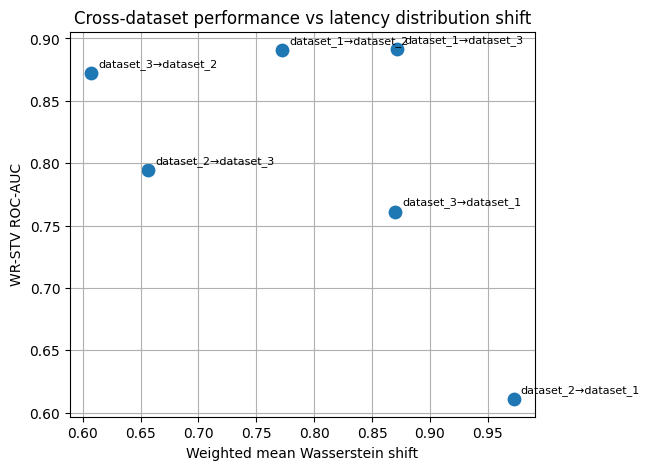

In [54]:
plt.figure(figsize=(6, 5))

plt.scatter(
    shift_perf_df["weighted_mean_wasserstein"],
    shift_perf_df["roc_auc_mean"],
    s=80
)

for _, row in shift_perf_df.iterrows():
    label = f'{row["train_dataset"]}→{row["test_dataset"]}'
    plt.annotate(
        label,
        (row["weighted_mean_wasserstein"], row["roc_auc_mean"]),
        fontsize=8,
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.xlabel("Weighted mean Wasserstein shift")
plt.ylabel("WR-STV ROC-AUC")
plt.title("Cross-dataset performance vs latency distribution shift")
plt.grid(True)
plt.show()

In [55]:
SHIFT_DIR = RESULTS_DIR / "distribution_shift"
SHIFT_DIR.mkdir(exist_ok=True)

shift_summary_df.to_csv(
    SHIFT_DIR / "cross_dataset_distribution_shift_summary.csv",
    index=False
)

feature_shift_all_df.to_csv(
    SHIFT_DIR / "cross_dataset_feature_shift_details.csv",
    index=False
)

shift_perf_df.to_csv(
    SHIFT_DIR / "cross_dataset_shift_vs_performance.csv",
    index=False
)

shift_corr_df.to_csv(
    SHIFT_DIR / "shift_performance_correlations.csv",
    index=False
)

print("Saved distribution shift analysis to:", SHIFT_DIR)

Saved distribution shift analysis to: /content/drive/MyDrive/anomalies_microservice_trainticket_version_configurations/_processed_phase1/paper_experiment_results/distribution_shift


> **Note:** `get_injection_detail_for_trace` and `normalize_path_for_match` below re-define the single-trace demo versions used earlier in this notebook. They are kept separate (rather than reused) because this module batches them across all traces/datasets; the earlier versions remain above as the single-trace walkthrough used for the qualitative example figure.

AGGREGATE EXPLAINABILITY MODULE
Research Question:
Does WR-STV identify the actual service paths affected by injected latency anomalies?

Hypothesis:
For injected anomalies, the highest WR-STV contribution features should overlap with the injected service paths.

Reviewer Benefit:
Shows WR-STV provides interpretable service-path evidence, not only anomaly scores.

Expected Output:
explainability_overlap_summary.csv
explainability_overlap_details.csv

If This Fails:
WR-STV may still detect anomalies, but explanation/localization claims must be weakened.


In [56]:
def normalize_path_for_match(path_value):
    """
    Convert a path representation into a canonical string.

    Handles:
    - tuple/list service paths
    - already-joined string paths
    """
    if isinstance(path_value, (tuple, list)):
        return " -> ".join([str(x) for x in path_value])

    return str(path_value)

def compute_explanation_overlap_for_trace(
    explanation_df,
    injection_detail,
    top_k=5
):
    """
    Compute both service-level and path-level overlap between:
      - WR-STV explanation top-k contributors
      - injected services / injected service paths
    """

    if injection_detail is None or explanation_df is None or explanation_df.empty:
        return {
            "top_k": top_k,

            "service_overlap_count": np.nan,
            "service_overlap_ratio": np.nan,
            "path_overlap_count": np.nan,
            "path_overlap_ratio": np.nan,

            "explained_services": [],
            "injected_services": [],
            "service_overlap": [],

            "explained_paths": [],
            "injected_paths": [],
            "path_overlap": [],
        }

    top_exp = explanation_df.head(top_k).copy()

    explained_services = set(top_exp["service"].astype(str).tolist())
    injected_services = set(
        [str(x) for x in injection_detail.get("modified_services", [])]
    )

    service_overlap = explained_services.intersection(injected_services)

    explained_paths = set(
        top_exp["service_path"]
        .apply(normalize_path_for_match)
        .tolist()
    )

    injected_paths = set(
        normalize_path_for_match(p)
        for p in injection_detail.get("modified_paths", [])
    )

    path_overlap = explained_paths.intersection(injected_paths)

    return {
        "top_k": top_k,

        "service_overlap_count": len(service_overlap),
        "service_overlap_ratio": (
            len(service_overlap) / len(injected_services)
            if injected_services else np.nan
        ),

        "path_overlap_count": len(path_overlap),
        "path_overlap_ratio": (
            len(path_overlap) / len(injected_paths)
            if injected_paths else np.nan
        ),

        "explained_services": sorted(explained_services),
        "injected_services": sorted(injected_services),
        "service_overlap": sorted(service_overlap),

        "explained_paths": sorted(explained_paths),
        "injected_paths": sorted(injected_paths),
        "path_overlap": sorted(path_overlap),
    }

def get_injection_detail_for_trace(injection_details, injected_trace_id):
    """
    Return the injection detail row for an injected trace.
    """

    if injection_details is None or injection_details.empty:
        return None

    row = injection_details[
        injection_details["injected_traceID"].astype(str) == str(injected_trace_id)
    ]

    if row.empty:
        return None

    return row.iloc[0].to_dict()


In [57]:
def aggregate_explainability_for_output(
    out,
    experiment_key,
    method_name="Global Weighted Residual STV k=1 clip=5.0",
    top_trace_limit=None,
    explanation_top_ks=(1, 3, 5, 10),
    clip_value=5.0
):
    """
    Aggregate explanation overlap for injected traces in one experiment output.

    For each injected trace:
      1. Build WR-STV explanation.
      2. Compare top-k explanation paths/services to injected paths/services.
      3. Store overlap metrics.
    """

    scores = out["method_scores"][method_name]
    eval_trace_ids = out["eval_trace_ids"]
    y_eval = out["y_eval"]

    trace_score_df = pd.DataFrame({
        "traceID": eval_trace_ids,
        "label": y_eval,
        "score": scores
    })

    if "eval_meta" in out and out["eval_meta"] is not None:
        meta_cols = [
            "traceID",
            "original_traceID",
            "root_operation",
            "num_spans",
            "num_services",
            "is_injected"
        ]
        available_meta_cols = [
            c for c in meta_cols if c in out["eval_meta"].columns
        ]

        trace_score_df = trace_score_df.merge(
            out["eval_meta"][available_meta_cols],
            on="traceID",
            how="left"
        )

    injected_df = trace_score_df[trace_score_df["label"] == 1].copy()
    injected_df = injected_df.sort_values("score", ascending=False)

    if top_trace_limit is not None:
        injected_df = injected_df.head(top_trace_limit)

    detail_rows = []
    explanation_rows = []

    for _, trace_row in injected_df.iterrows():
        trace_id = trace_row["traceID"]

        explanation_df = explain_wrstv_trace(
            trace_id=trace_id,
            eval_trace_ids=out["eval_trace_ids"],
            X_eval_base=out["X_eval_base"],
            eval_vocab=out["eval_vocab"],
            feature_means=out["feature_means"],
            feature_stds=out["feature_stds"],
            feature_weights=out["feature_weights"],
            eval_meta=out["eval_meta"],
            top_k=max(explanation_top_ks),
            clip_value=clip_value
        )

        injection_detail = get_injection_detail_for_trace(
            out["injection_details"],
            trace_id
        )

        # Store full explanation rows
        if not explanation_df.empty:
            explanation_df = explanation_df.copy()
            explanation_df["experiment_key"] = experiment_key
            explanation_df["method"] = method_name
            explanation_df["anomaly_score"] = trace_row["score"]
            explanation_rows.append(explanation_df)

        # Store overlap metrics for multiple top-k values
        for k in explanation_top_ks:
            overlap = compute_explanation_overlap_for_trace(
                explanation_df=explanation_df,
                injection_detail=injection_detail,
                top_k=k
            )

            overlap.update({
                "experiment_key": experiment_key,
                "method": method_name,
                "traceID": trace_id,
                "anomaly_score": trace_row["score"],
                "root_operation": trace_row.get("root_operation", None),
                "num_spans": trace_row.get("num_spans", None),
                "num_services": trace_row.get("num_services", None),
            })

            detail_rows.append(overlap)

    overlap_detail_df = pd.DataFrame(detail_rows)

    if explanation_rows:
        explanation_detail_df = pd.concat(explanation_rows, ignore_index=True)
    else:
        explanation_detail_df = pd.DataFrame()

    return overlap_detail_df, explanation_detail_df

In [58]:
def run_aggregate_explainability(
    outputs,
    method_name="Global Weighted Residual STV k=1 clip=5.0",
    explanation_top_ks=(1, 3, 5, 10),
    top_trace_limit=None,
    clip_value=5.0
):
    """
    Apply aggregate explainability to all experiment outputs.
    """

    all_overlap = []
    all_explanations = []

    for experiment_key, out in outputs.items():
        print(f"Explaining: {experiment_key}")

        overlap_df, explanation_df = aggregate_explainability_for_output(
            out=out,
            experiment_key=experiment_key,
            method_name=method_name,
            top_trace_limit=top_trace_limit,
            explanation_top_ks=explanation_top_ks,
            clip_value=clip_value
        )

        if not overlap_df.empty:
            all_overlap.append(overlap_df)

        if not explanation_df.empty:
            all_explanations.append(explanation_df)

    all_overlap_df = (
        pd.concat(all_overlap, ignore_index=True)
        if all_overlap else pd.DataFrame()
    )

    all_explanation_df = (
        pd.concat(all_explanations, ignore_index=True)
        if all_explanations else pd.DataFrame()
    )

    return all_overlap_df, all_explanation_df
EXPLAIN_METHOD = "Global Weighted Residual STV k=1 clip=5.0"

all_overlap_df, all_explanation_df = run_aggregate_explainability(
    outputs=cross_outputs,
    method_name=EXPLAIN_METHOD,
    explanation_top_ks=(1, 3, 5, 10),
    top_trace_limit=None,
    clip_value=5.0
)

display(all_overlap_df.head())
display(all_explanation_df.head())

Explaining: train_dataset_1_test_dataset_2_seed_0
Explaining: train_dataset_1_test_dataset_3_seed_0
Explaining: train_dataset_2_test_dataset_1_seed_0
Explaining: train_dataset_2_test_dataset_3_seed_0
Explaining: train_dataset_3_test_dataset_1_seed_0
Explaining: train_dataset_3_test_dataset_2_seed_0
Explaining: train_dataset_1_test_dataset_2_seed_1
Explaining: train_dataset_1_test_dataset_3_seed_1
Explaining: train_dataset_2_test_dataset_1_seed_1
Explaining: train_dataset_2_test_dataset_3_seed_1
Explaining: train_dataset_3_test_dataset_1_seed_1
Explaining: train_dataset_3_test_dataset_2_seed_1
Explaining: train_dataset_1_test_dataset_2_seed_2
Explaining: train_dataset_1_test_dataset_3_seed_2
Explaining: train_dataset_2_test_dataset_1_seed_2
Explaining: train_dataset_2_test_dataset_3_seed_2
Explaining: train_dataset_3_test_dataset_1_seed_2
Explaining: train_dataset_3_test_dataset_2_seed_2
Explaining: train_dataset_1_test_dataset_2_seed_3
Explaining: train_dataset_1_test_dataset_3_seed_3


,top_k,service_overlap_count,service_overlap_ratio,path_overlap_count,path_overlap_ratio,explained_services,injected_services,service_overlap,explained_paths,injected_paths,path_overlap,experiment_key,method,traceID,anomaly_score,root_operation,num_spans,num_services
0,1,1,0.5,1,0.333333,[ts-admin-basic-info-service],"[ts-admin-basic-info-service, ts-config-service]",[ts-admin-basic-info-service],[ts-admin-basic-info-service],"[ts-admin-basic-info-service, ts-admin-basic-i...",[ts-admin-basic-info-service],train_dataset_1_test_dataset_2_seed_0,Global Weighted Residual STV k=1 clip=5.0,0915ee7798c08138_inj_latency_v2,5.0,deleteConfig,3,2
1,3,2,1.0,3,1.000000,"[ts-admin-basic-info-service, ts-config-service]","[ts-admin-basic-info-service, ts-config-service]","[ts-admin-basic-info-service, ts-config-service]","[ts-admin-basic-info-service, ts-admin-basic-i...","[ts-admin-basic-info-service, ts-admin-basic-i...","[ts-admin-basic-info-service, ts-admin-basic-i...",train_dataset_1_test_dataset_2_seed_0,Global Weighted Residual STV k=1 clip=5.0,0915ee7798c08138_inj_latency_v2,5.0,deleteConfig,3,2
2,5,2,1.0,3,1.000000,"[ts-admin-basic-info-service, ts-config-service]","[ts-admin-basic-info-service, ts-config-service]","[ts-admin-basic-info-service, ts-config-service]","[ts-admin-basic-info-service, ts-admin-basic-i...","[ts-admin-basic-info-service, ts-admin-basic-i...","[ts-admin-basic-info-service, ts-admin-basic-i...",train_dataset_1_test_dataset_2_seed_0,Global Weighted Residual STV k=1 clip=5.0,0915ee7798c08138_inj_latency_v2,5.0,deleteConfig,3,2
3,10,2,1.0,3,1.000000,"[ts-admin-basic-info-service, ts-config-service]","[ts-admin-basic-info-service, ts-config-service]","[ts-admin-basic-info-service, ts-config-service]","[ts-admin-basic-info-service, ts-admin-basic-i...","[ts-admin-basic-info-service, ts-admin-basic-i...","[ts-admin-basic-info-service, ts-admin-basic-i...",train_dataset_1_test_dataset_2_seed_0,Global Weighted Residual STV k=1 clip=5.0,0915ee7798c08138_inj_latency_v2,5.0,deleteConfig,3,2
4,1,1,0.5,1,0.333333,[ts-admin-basic-info-service],"[ts-admin-basic-info-service, ts-station-service]",[ts-admin-basic-info-service],[ts-admin-basic-info-service],"[ts-admin-basic-info-service, ts-admin-basic-i...",[ts-admin-basic-info-service],train_dataset_1_test_dataset_2_seed_0,Global Weighted Residual STV k=1 clip=5.0,09bd020ecb37a825_inj_latency_v2,5.0,addStation,3,2


,rank,traceID,is_injected,root_operation,service,service_path,observed_duration_approx,residual_clipped,feature_weight,weighted_contribution,...,observed_log_duration,train_mean_log_duration,train_std_log_duration,residual,abs_residual,num_spans,num_services,experiment_key,method,anomaly_score
0,1,0915ee7798c08138_inj_latency_v2,True,deleteConfig,ts-admin-basic-info-service,ts-admin-basic-info-service,1.316969e+07,5.000000,1.000000,5.000000,...,16.393429,12.191497,0.760525,5.525039,5.000000,3,2,train_dataset_1_test_dataset_2_seed_0,Global Weighted Residual STV k=1 clip=5.0,5.0
1,2,0915ee7798c08138_inj_latency_v2,True,deleteConfig,ts-admin-basic-info-service,ts-admin-basic-info-service -> ts-admin-basic-...,1.224753e+07,4.612201,1.000000,4.612201,...,16.320835,11.430722,1.060256,4.612201,4.612201,3,2,train_dataset_1_test_dataset_2_seed_0,Global Weighted Residual STV k=1 clip=5.0,5.0
2,3,0915ee7798c08138_inj_latency_v2,True,deleteConfig,ts-config-service,ts-admin-basic-info-service -> ts-admin-basic-...,1.205498e+07,4.399772,0.604883,2.661347,...,16.304989,10.907726,1.226714,4.399772,4.399772,3,2,train_dataset_1_test_dataset_2_seed_0,Global Weighted Residual STV k=1 clip=5.0,5.0
3,1,09bd020ecb37a825_inj_latency_v2,True,addStation,ts-admin-basic-info-service,ts-admin-basic-info-service,1.092600e+07,5.000000,1.000000,5.000000,...,16.206656,12.191497,0.760525,5.279454,5.000000,3,2,train_dataset_1_test_dataset_2_seed_0,Global Weighted Residual STV k=1 clip=5.0,5.0
4,2,09bd020ecb37a825_inj_latency_v2,True,addStation,ts-admin-basic-info-service,ts-admin-basic-info-service -> ts-admin-basic-...,7.529132e+06,4.153307,1.000000,4.153307,...,15.834291,11.430722,1.060256,4.153307,4.153307,3,2,train_dataset_1_test_dataset_2_seed_0,Global Weighted Residual STV k=1 clip=5.0,5.0


In [59]:
explainability_summary_df = (
    all_overlap_df
    .groupby(["method", "top_k"])
    .agg(
        service_overlap_ratio_mean=("service_overlap_ratio", "mean"),
        service_overlap_ratio_median=("service_overlap_ratio", "median"),
        service_overlap_ratio_std=("service_overlap_ratio", "std"),

        path_overlap_ratio_mean=("path_overlap_ratio", "mean"),
        path_overlap_ratio_median=("path_overlap_ratio", "median"),
        path_overlap_ratio_std=("path_overlap_ratio", "std"),

        traces=("traceID", "count")
    )
    .reset_index()
)

display(explainability_summary_df)

,method,top_k,service_overlap_ratio_mean,service_overlap_ratio_median,service_overlap_ratio_std,path_overlap_ratio_mean,path_overlap_ratio_median,path_overlap_ratio_std,traces
0,Global Weighted Residual STV k=1 clip=5.0,1,0.637475,0.5,0.305182,0.499661,0.333333,0.326853,4910
1,Global Weighted Residual STV k=1 clip=5.0,3,0.936864,1.0,0.200797,0.914460,1.000000,0.244870,4910
2,Global Weighted Residual STV k=1 clip=5.0,5,0.967413,1.0,0.144348,0.946368,1.000000,0.192982,4910
3,Global Weighted Residual STV k=1 clip=5.0,10,0.997454,1.0,0.035591,0.991853,1.000000,0.073252,4910


In [60]:
def parse_cross_experiment_key(key):
    """
    Parses keys like:
    train_dataset_1_test_dataset_2_seed_0

    Returns train_dataset, test_dataset, seed when possible.
    """
    parts = key.split("_")

    try:
        train_idx = parts.index("train")
        test_idx = parts.index("test")
        seed_idx = parts.index("seed")

        train_dataset = "_".join(parts[train_idx + 1:test_idx])
        test_dataset = "_".join(parts[test_idx + 1:seed_idx])
        seed = int(parts[seed_idx + 1])

        return train_dataset, test_dataset, seed
    except Exception:
        return None, None, None
all_overlap_df[["train_dataset", "test_dataset", "seed"]] = all_overlap_df[
    "experiment_key"
].apply(
    lambda x: pd.Series(parse_cross_experiment_key(x))
)

explainability_pair_summary_df = (
    all_overlap_df
    .groupby(["train_dataset", "test_dataset", "top_k"])
    .agg(
        service_overlap_ratio_mean=("service_overlap_ratio", "mean"),
        path_overlap_ratio_mean=("path_overlap_ratio", "mean"),
        service_overlap_ratio_median=("service_overlap_ratio", "median"),
        path_overlap_ratio_median=("path_overlap_ratio", "median"),
        traces=("traceID", "count")
    )
    .reset_index()
)

display(explainability_pair_summary_df)

,train_dataset,test_dataset,top_k,service_overlap_ratio_mean,path_overlap_ratio_mean,service_overlap_ratio_median,path_overlap_ratio_median,traces
0,dataset_1,dataset_2,1,0.652941,0.523529,0.5,0.333333,425
1,dataset_1,dataset_2,3,0.982353,0.968627,1.0,1.000000,425
2,dataset_1,dataset_2,5,0.988235,0.976471,1.0,1.000000,425
3,dataset_1,dataset_2,10,1.000000,1.000000,1.0,1.000000,425
4,dataset_1,dataset_3,1,0.680921,0.518640,0.5,0.333333,760
5,dataset_1,dataset_3,3,0.986842,0.980263,1.0,1.000000,760
6,dataset_1,dataset_3,5,0.986842,0.986842,1.0,1.000000,760
7,dataset_1,dataset_3,10,1.000000,0.995614,1.0,1.000000,760
8,dataset_2,dataset_1,1,0.604089,0.485750,0.5,0.333333,1345
9,dataset_2,dataset_1,3,0.899628,0.867410,1.0,1.000000,1345


In [61]:
EXPLAIN_DIR = RESULTS_DIR / "explainability"
EXPLAIN_DIR.mkdir(exist_ok=True)

all_overlap_df.to_csv(
    EXPLAIN_DIR / "aggregate_explainability_overlap_details.csv",
    index=False
)

all_explanation_df.to_csv(
    EXPLAIN_DIR / "aggregate_explanation_feature_details.csv",
    index=False
)

explainability_summary_df.to_csv(
    EXPLAIN_DIR / "aggregate_explainability_summary.csv",
    index=False
)

explainability_pair_summary_df.to_csv(
    EXPLAIN_DIR / "aggregate_explainability_by_pair.csv",
    index=False
)

print("Saved explainability outputs to:", EXPLAIN_DIR)

Saved explainability outputs to: /content/drive/MyDrive/anomalies_microservice_trainticket_version_configurations/_processed_phase1/paper_experiment_results/explainability


> **Note:** `correlation_with_performance` below is a second definition of the function used earlier in the per-pair Wasserstein scatter analysis. It is kept here since this section applies it to the robustness-checked shift metrics instead of the original ones.

Research Question:
Why does WR-STV transfer well for some train-test dataset pairs and poorly for others?

Hypothesis:
Poor transfer is caused less by unseen paths and more by latency distribution shift across shared service paths.

Reviewer Benefit:
Explains when and why WR-STV works or fails.

Expected Output:
1. robust_shift_vs_performance.csv
2. shift_performance_correlation.csv
3. failure_summary.csv
4. failure_case_details.csv

If This Fails:
We weaken the distribution-shift explanation and investigate other failure causes

In [62]:
def robust_shift_summary(feature_shift_df):
    """
    Produce robust aggregate shift metrics for one train-test pair.

    Avoids over-reliance on mean standardized shift because that can explode
    when train standard deviation is very small.
    """

    if feature_shift_df is None or feature_shift_df.empty:
        return {
            "num_shift_features": 0,
            "median_wasserstein": np.nan,
            "p75_wasserstein": np.nan,
            "p90_wasserstein": np.nan,
            "weighted_mean_wasserstein": np.nan,
            "median_abs_mean_shift": np.nan,
            "p90_abs_mean_shift": np.nan,
            "median_standardized_shift": np.nan,
            "p75_standardized_shift": np.nan,
            "p90_standardized_shift": np.nan,
        }

    df = feature_shift_df.copy()
    weights = df["test_count"].astype(float).values

    return {
        "num_shift_features": len(df),

        "median_wasserstein": df["wasserstein_log_duration"].median(),
        "p75_wasserstein": df["wasserstein_log_duration"].quantile(0.75),
        "p90_wasserstein": df["wasserstein_log_duration"].quantile(0.90),
        "weighted_mean_wasserstein": np.average(
            df["wasserstein_log_duration"],
            weights=weights
        ),

        "median_abs_mean_shift": df["absolute_mean_shift"].median(),
        "p90_abs_mean_shift": df["absolute_mean_shift"].quantile(0.90),

        "median_standardized_shift": df["standardized_mean_shift"].median(),
        "p75_standardized_shift": df["standardized_mean_shift"].quantile(0.75),
        "p90_standardized_shift": df["standardized_mean_shift"].quantile(0.90),
    }

In [63]:
robust_shift_rows = []
for train_ds in stv_event_dfs.keys():
    for test_ds in stv_event_dfs.keys():
        if train_ds == test_ds:
            continue

        pair_shift_df = feature_shift_all_df[
            (feature_shift_all_df["train_dataset"] == train_ds) &
            (feature_shift_all_df["test_dataset"] == test_ds)
        ]

        summary = robust_shift_summary(pair_shift_df)
        summary["train_dataset"] = train_ds
        summary["test_dataset"] = test_ds

        robust_shift_rows.append(summary)

robust_shift_df = pd.DataFrame(robust_shift_rows)
display(robust_shift_df)

,num_shift_features,median_wasserstein,p75_wasserstein,p90_wasserstein,weighted_mean_wasserstein,median_abs_mean_shift,p90_abs_mean_shift,median_standardized_shift,p75_standardized_shift,p90_standardized_shift,train_dataset,test_dataset
0,127,0.846932,1.264180,1.746181,0.772383,0.708337,1.702555,0.668081,1.138762,1.707001,dataset_1,dataset_2
1,123,0.741115,1.073581,1.636689,0.871751,0.641122,1.536801,0.572701,1.006344,1.514786,dataset_1,dataset_3
2,127,0.846932,1.264180,1.746181,0.972603,0.708337,1.702555,0.806125,1.393741,2.736601,dataset_2,dataset_1
3,136,0.670637,1.028240,1.329713,0.656475,0.511151,1.206391,0.626531,1.172272,2.595435,dataset_2,dataset_3
4,123,0.741115,1.073581,1.636689,0.870171,0.641122,1.536801,0.641804,0.937708,2.066554,dataset_3,dataset_1
5,136,0.670637,1.028240,1.329713,0.607243,0.511151,1.206391,0.527502,1.084429,2.313773,dataset_3,dataset_2


In [64]:
BEST_CROSS_METHOD = "Global Weighted Residual STV k=1 clip=5.0"

best_cross_perf_df = cross_pair_summary_df[
    cross_pair_summary_df["method"] == BEST_CROSS_METHOD
].copy()

robust_shift_perf_df = best_cross_perf_df.merge(
    robust_shift_df,
    on=["train_dataset", "test_dataset"],
    how="left"
)

display(
    robust_shift_perf_df[
        [
            "train_dataset",
            "test_dataset",
            "roc_auc_mean",
            "average_precision_mean",
            "f1_mean",
            "pairwise_win_rate_mean",
            "visible_event_ratio_mean",
            "unseen_event_ratio_mean",
            "weighted_mean_wasserstein",
            "median_wasserstein",
            "p90_wasserstein",
            "p90_standardized_shift",
        ]
    ].sort_values("roc_auc_mean", ascending=False)
)

,train_dataset,test_dataset,roc_auc_mean,average_precision_mean,f1_mean,pairwise_win_rate_mean,visible_event_ratio_mean,unseen_event_ratio_mean,weighted_mean_wasserstein,median_wasserstein,p90_wasserstein,p90_standardized_shift
1,dataset_1,dataset_3,0.891365,0.892226,0.796053,0.921053,0.918716,0.081284,0.871751,0.741115,1.636689,1.514786
0,dataset_1,dataset_2,0.890629,0.888199,0.800000,0.964706,0.885911,0.114089,0.772383,0.846932,1.746181,1.707001
5,dataset_3,dataset_2,0.871946,0.860980,0.784810,0.835443,0.954824,0.045176,0.607243,0.670637,1.329713,2.313773
3,dataset_2,dataset_3,0.794138,0.789265,0.679739,0.764706,0.991972,0.008028,0.656475,0.670637,1.329713,2.595435
4,dataset_3,dataset_1,0.761183,0.751639,0.684426,0.614754,0.932946,0.067054,0.870171,0.741115,1.636689,2.066554
2,dataset_2,dataset_1,0.610771,0.643708,0.587361,0.550186,0.977825,0.022175,0.972603,0.846932,1.746181,2.736601


In [65]:
def correlation_with_performance(df, metric_col, performance_col="roc_auc_mean"):
    clean = df[[metric_col, performance_col]].dropna()

    if len(clean) < 3:
        return {
            "metric": metric_col,
            "n": len(clean),
            "pearson_r": np.nan,
            "pearson_p": np.nan,
            "spearman_r": np.nan,
            "spearman_p": np.nan,
        }

    pearson_r, pearson_p = pearsonr(clean[metric_col], clean[performance_col])
    spearman_r, spearman_p = spearmanr(clean[metric_col], clean[performance_col])

    return {
        "metric": metric_col,
        "n": len(clean),
        "pearson_r": pearson_r,
        "pearson_p": pearson_p,
        "spearman_r": spearman_r,
        "spearman_p": spearman_p,
    }
robust_shift_metrics = [
    "visible_event_ratio_mean",
    "unseen_event_ratio_mean",
    "weighted_mean_wasserstein",
    "median_wasserstein",
    "p90_wasserstein",
    "p90_standardized_shift",
]

robust_corr_rows = []

for metric in robust_shift_metrics:
    robust_corr_rows.append(
        correlation_with_performance(
            robust_shift_perf_df,
            metric_col=metric,
            performance_col="roc_auc_mean"
        )
    )

robust_shift_corr_df = pd.DataFrame(robust_corr_rows)

display(robust_shift_corr_df)

,metric,n,pearson_r,pearson_p,spearman_r,spearman_p
0,visible_event_ratio_mean,6,-0.611906,0.196699,-0.657143,0.156175
1,unseen_event_ratio_mean,6,0.611906,0.196699,0.657143,0.156175
2,weighted_mean_wasserstein,6,-0.581184,0.226378,-0.257143,0.622787
3,median_wasserstein,6,-0.355492,0.489224,-0.119523,0.821569
4,p90_wasserstein,6,-0.283732,0.585822,-0.119523,0.821569
5,p90_standardized_shift,6,-0.747397,0.087653,-0.828571,0.041563


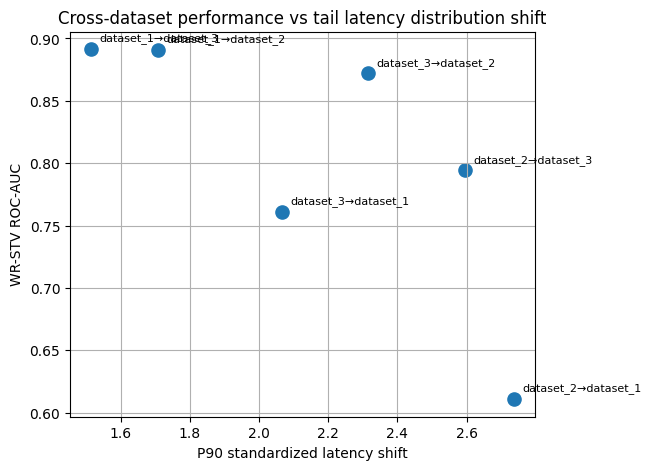

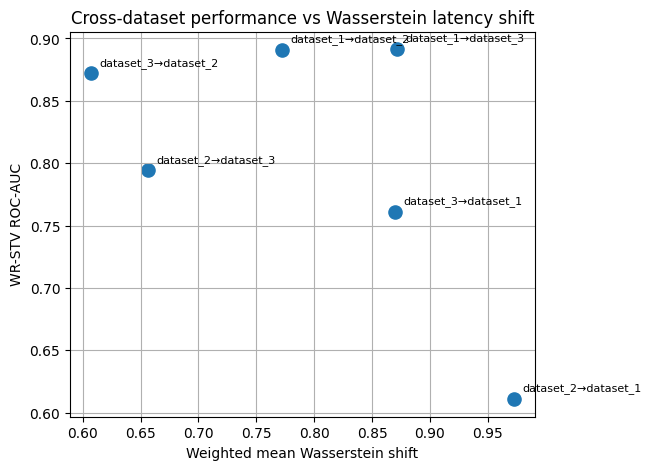

In [66]:
plt.figure(figsize=(6, 5))

plt.scatter(
    robust_shift_perf_df["p90_standardized_shift"],
    robust_shift_perf_df["roc_auc_mean"],
    s=90
)

for _, row in robust_shift_perf_df.iterrows():
    label = f'{row["train_dataset"]}→{row["test_dataset"]}'
    plt.annotate(
        label,
        (row["p90_standardized_shift"], row["roc_auc_mean"]),
        fontsize=8,
        xytext=(6, 6),
        textcoords="offset points"
    )

plt.xlabel("P90 standardized latency shift")
plt.ylabel("WR-STV ROC-AUC")
plt.title("Cross-dataset performance vs tail latency distribution shift")
plt.grid(True)
plt.show()
plt.figure(figsize=(6, 5))

plt.scatter(
    robust_shift_perf_df["weighted_mean_wasserstein"],
    robust_shift_perf_df["roc_auc_mean"],
    s=90
)

for _, row in robust_shift_perf_df.iterrows():
    label = f'{row["train_dataset"]}→{row["test_dataset"]}'
    plt.annotate(
        label,
        (row["weighted_mean_wasserstein"], row["roc_auc_mean"]),
        fontsize=8,
        xytext=(6, 6),
        textcoords="offset points"
    )

plt.xlabel("Weighted mean Wasserstein shift")
plt.ylabel("WR-STV ROC-AUC")
plt.title("Cross-dataset performance vs Wasserstein latency shift")
plt.grid(True)
plt.show()

In [67]:
def summarize_pairwise_failures_for_output(
    out,
    method_name="Global Weighted Residual STV k=1 clip=5.0"
):
    """
    Summarize pairwise failures for one experiment output.

    Failure means:
        score(injected trace) <= score(original trace)
    """

    pair_df = out["pairwise_tables"][method_name].copy()

    failures = pair_df[pair_df["win"] == False].copy()

    eval_meta = out["eval_meta"].copy()

    if failures.empty:
        summary = {
            "num_pairs": len(pair_df),
            "num_failures": 0,
            "failure_rate": 0.0,
            "failure_num_spans_mean": np.nan,
            "failure_num_services_mean": np.nan,
            "failure_delta_mean": np.nan,
            "failure_delta_min": np.nan,
        }
        return failures, summary

    failures = failures.merge(
        eval_meta[
            [
                "traceID",
                "original_traceID",
                "root_operation",
                "num_spans",
                "num_services",
                "is_injected"
            ]
        ],
        left_on="injected_traceID",
        right_on="traceID",
        how="left",
        suffixes=("", "_meta")
    )

    summary = {
        "num_pairs": len(pair_df),
        "num_failures": len(failures),
        "failure_rate": len(failures) / len(pair_df),
        "failure_num_spans_mean": failures["num_spans"].mean(),
        "failure_num_services_mean": failures["num_services"].mean(),
        "failure_delta_mean": failures["delta"].mean(),
        "failure_delta_min": failures["delta"].min(),
    }

    return failures, summary

In [68]:
METHOD_FOR_FAILURE = "Global Weighted Residual STV k=1 clip=5.0"

failure_summary_rows = []
failure_detail_frames = []

for experiment_key, out in cross_outputs.items():
    failures, summary = summarize_pairwise_failures_for_output(
        out,
        method_name=METHOD_FOR_FAILURE
    )

    train_ds, test_ds, seed = parse_cross_experiment_key(experiment_key)

    summary["experiment_key"] = experiment_key
    summary["train_dataset"] = train_ds
    summary["test_dataset"] = test_ds
    summary["seed"] = seed
    summary["method"] = METHOD_FOR_FAILURE

    failure_summary_rows.append(summary)

    if not failures.empty:
        failures["experiment_key"] = experiment_key
        failures["train_dataset"] = train_ds
        failures["test_dataset"] = test_ds
        failures["seed"] = seed
        failure_detail_frames.append(failures)

failure_summary_df = pd.DataFrame(failure_summary_rows)

failure_details_df = (
    pd.concat(failure_detail_frames, ignore_index=True)
    if failure_detail_frames else pd.DataFrame()
)

display(
    failure_summary_df
    .sort_values("failure_rate", ascending=False)
    .head(20)
)

display(failure_details_df.head(20))

,num_pairs,num_failures,failure_rate,failure_num_spans_mean,failure_num_services_mean,failure_delta_mean,failure_delta_min,experiment_key,train_dataset,test_dataset,seed,method
2,269,121,0.449814,21.504132,3.231405,-0.439859,-2.009946,train_dataset_2_test_dataset_1_seed_0,dataset_2,dataset_1,0,Global Weighted Residual STV k=1 clip=5.0
8,269,121,0.449814,21.504132,3.231405,-0.439859,-2.009946,train_dataset_2_test_dataset_1_seed_1,dataset_2,dataset_1,1,Global Weighted Residual STV k=1 clip=5.0
20,269,121,0.449814,21.504132,3.231405,-0.439859,-2.009946,train_dataset_2_test_dataset_1_seed_3,dataset_2,dataset_1,3,Global Weighted Residual STV k=1 clip=5.0
26,269,121,0.449814,21.504132,3.231405,-0.439859,-2.009946,train_dataset_2_test_dataset_1_seed_4,dataset_2,dataset_1,4,Global Weighted Residual STV k=1 clip=5.0
14,269,121,0.449814,21.504132,3.231405,-0.439859,-2.009946,train_dataset_2_test_dataset_1_seed_2,dataset_2,dataset_1,2,Global Weighted Residual STV k=1 clip=5.0
10,244,94,0.385246,24.617021,4.042553,-0.216500,-1.411029,train_dataset_3_test_dataset_1_seed_1,dataset_3,dataset_1,1,Global Weighted Residual STV k=1 clip=5.0
16,244,94,0.385246,24.617021,4.042553,-0.216500,-1.411029,train_dataset_3_test_dataset_1_seed_2,dataset_3,dataset_1,2,Global Weighted Residual STV k=1 clip=5.0
4,244,94,0.385246,24.617021,4.042553,-0.216500,-1.411029,train_dataset_3_test_dataset_1_seed_0,dataset_3,dataset_1,0,Global Weighted Residual STV k=1 clip=5.0
28,244,94,0.385246,24.617021,4.042553,-0.216500,-1.411029,train_dataset_3_test_dataset_1_seed_4,dataset_3,dataset_1,4,Global Weighted Residual STV k=1 clip=5.0
22,244,94,0.385246,24.617021,4.042553,-0.216500,-1.411029,train_dataset_3_test_dataset_1_seed_3,dataset_3,dataset_1,3,Global Weighted Residual STV k=1 clip=5.0


,traceID,injected_traceID,normal_score,injected_score,delta,win,traceID_meta,original_traceID,root_operation,num_spans,num_services,is_injected,experiment_key,train_dataset,test_dataset,seed
0,175aedae66c1f4c8,175aedae66c1f4c8_inj_latency_v2,1.121942,0.563347,-0.558594,False,175aedae66c1f4c8_inj_latency_v2,175aedae66c1f4c8,getOrderById,1,1,True,train_dataset_1_test_dataset_2_seed_0,dataset_1,dataset_2,0
1,729a65997299a40a,729a65997299a40a_inj_latency_v2,1.443012,1.443012,0.000000,False,729a65997299a40a_inj_latency_v2,729a65997299a40a,pay,7,3,True,train_dataset_1_test_dataset_2_seed_0,dataset_1,dataset_2,0
2,cae66fa51aff79d3,cae66fa51aff79d3_inj_latency_v2,2.353452,2.353452,0.000000,False,cae66fa51aff79d3_inj_latency_v2,cae66fa51aff79d3,preserve,141,17,True,train_dataset_1_test_dataset_2_seed_0,dataset_1,dataset_2,0
3,03936fa843b81eb0,03936fa843b81eb0_inj_latency_v2,1.069971,0.345677,-0.724294,False,03936fa843b81eb0_inj_latency_v2,03936fa843b81eb0,pay,2,1,True,train_dataset_1_test_dataset_3_seed_0,dataset_1,dataset_3,0
4,282da289dca8852b,282da289dca8852b_inj_latency_v2,2.062843,1.232569,-0.830274,False,282da289dca8852b_inj_latency_v2,282da289dca8852b,addRoute,3,2,True,train_dataset_1_test_dataset_3_seed_0,dataset_1,dataset_3,0
5,3887036b99e297a7,3887036b99e297a7_inj_latency_v2,3.263891,3.263891,0.000000,False,3887036b99e297a7_inj_latency_v2,3887036b99e297a7,queryInfo,103,10,True,train_dataset_1_test_dataset_3_seed_0,dataset_1,dataset_3,0
6,3d1a3606f264d1a9,3d1a3606f264d1a9_inj_latency_v2,0.969886,0.638164,-0.331722,False,3d1a3606f264d1a9_inj_latency_v2,3d1a3606f264d1a9,getPriceByWeightAndRegion,1,1,True,train_dataset_1_test_dataset_3_seed_0,dataset_1,dataset_3,0
7,58663a90e5c893c5,58663a90e5c893c5_inj_latency_v2,2.353452,2.353452,0.000000,False,58663a90e5c893c5_inj_latency_v2,58663a90e5c893c5,preserve,135,16,True,train_dataset_1_test_dataset_3_seed_0,dataset_1,dataset_3,0
8,70d74443a791be6e,70d74443a791be6e_inj_latency_v2,0.613625,0.110674,-0.502951,False,70d74443a791be6e_inj_latency_v2,70d74443a791be6e,pay,2,1,True,train_dataset_1_test_dataset_3_seed_0,dataset_1,dataset_3,0
9,a1610e1ad51d3b84,a1610e1ad51d3b84_inj_latency_v2,1.645805,1.253813,-0.391992,False,a1610e1ad51d3b84_inj_latency_v2,a1610e1ad51d3b84,updateConsign,3,2,True,train_dataset_1_test_dataset_3_seed_0,dataset_1,dataset_3,0


In [69]:
failure_pair_summary_df = (
    failure_summary_df
    .groupby(["train_dataset", "test_dataset"])
    .agg(
        failure_rate_mean=("failure_rate", "mean"),
        failure_rate_std=("failure_rate", "std"),
        num_failures_total=("num_failures", "sum"),
        num_pairs_total=("num_pairs", "sum"),
        failure_num_spans_mean=("failure_num_spans_mean", "mean"),
        failure_num_services_mean=("failure_num_services_mean", "mean"),
    )
    .reset_index()
)

display(
    failure_pair_summary_df
    .sort_values("failure_rate_mean", ascending=False)
)

,train_dataset,test_dataset,failure_rate_mean,failure_rate_std,num_failures_total,num_pairs_total,failure_num_spans_mean,failure_num_services_mean
2,dataset_2,dataset_1,0.449814,0.0,605,1345,21.504132,3.231405
4,dataset_3,dataset_1,0.385246,0.0,470,1220,24.617021,4.042553
3,dataset_2,dataset_3,0.235294,0.0,180,765,18.916667,3.111111
5,dataset_3,dataset_2,0.164557,0.0,65,395,62.538462,8.384615
1,dataset_1,dataset_3,0.078947,0.0,60,760,41.000000,5.166667
0,dataset_1,dataset_2,0.035294,0.0,15,425,49.666667,7.000000


In [70]:
ANALYSIS_DIR = RESULTS_DIR / "robust_shift_failure_analysis"
ANALYSIS_DIR.mkdir(exist_ok=True)

robust_shift_df.to_csv(
    ANALYSIS_DIR / "robust_distribution_shift_summary.csv",
    index=False
)

robust_shift_perf_df.to_csv(
    ANALYSIS_DIR / "robust_shift_vs_performance.csv",
    index=False
)

robust_shift_corr_df.to_csv(
    ANALYSIS_DIR / "robust_shift_performance_correlations.csv",
    index=False
)

failure_summary_df.to_csv(
    ANALYSIS_DIR / "failure_summary_by_experiment.csv",
    index=False
)

failure_details_df.to_csv(
    ANALYSIS_DIR / "failure_details.csv",
    index=False
)

failure_pair_summary_df.to_csv(
    ANALYSIS_DIR / "failure_summary_by_pair.csv",
    index=False
)

print("Saved robust shift and failure analysis to:", ANALYSIS_DIR)

Saved robust shift and failure analysis to: /content/drive/MyDrive/anomalies_microservice_trainticket_version_configurations/_processed_phase1/paper_experiment_results/robust_shift_failure_analysis


FAILURE CATEGORIZATION CODE

When WR-STV fails to rank injected anomalies above their original traces, what failure modes explain those cases?

Hypothesis:
Failures are caused by short traces, pre-existing high normal scores, score saturation/unchanged top contributors, low feature reliability, or distribution shift.

Reviewer Benefit:
Shows honest limitations and explains when WR-STV should or should not be trusted.

Expected Output:
failure_category_details.csv
failure_category_summary.csv
failure_category_by_pair.csv


In [71]:
def get_injected_path_explanation_stats(
    explanation_df,
    injection_detail
):
    """
    For one failed injected trace, measure how strongly the injected paths
    appear in the WR-STV explanation.

    Returns max contribution/residual/weight among injected paths.
    """

    if explanation_df is None or explanation_df.empty or injection_detail is None:
        return {
            "injected_path_found_in_explanation": False,
            "max_injected_path_contribution": np.nan,
            "max_injected_path_abs_residual": np.nan,
            "max_injected_path_weight": np.nan,
            "max_injected_path_train_std": np.nan,
            "num_injected_paths_found": 0,
            "num_injected_paths_total": np.nan,
        }

    injected_paths = set(
        normalize_path_for_match(p)
        for p in injection_detail.get("modified_paths", [])
    )

    explanation_df = explanation_df.copy()
    explanation_df["normalized_service_path"] = explanation_df["service_path"].apply(
        normalize_path_for_match
    )

    matched = explanation_df[
        explanation_df["normalized_service_path"].isin(injected_paths)
    ]

    if matched.empty:
        return {
            "injected_path_found_in_explanation": False,
            "max_injected_path_contribution": np.nan,
            "max_injected_path_abs_residual": np.nan,
            "max_injected_path_weight": np.nan,
            "max_injected_path_train_std": np.nan,
            "num_injected_paths_found": 0,
            "num_injected_paths_total": len(injected_paths),
        }

    return {
        "injected_path_found_in_explanation": True,
        "max_injected_path_contribution": matched["weighted_contribution"].max(),
        "max_injected_path_abs_residual": matched["abs_residual"].max(),
        "max_injected_path_weight": matched["feature_weight"].max(),
        "max_injected_path_train_std": matched["train_std_log_duration"].max(),
        "num_injected_paths_found": matched["normalized_service_path"].nunique(),
        "num_injected_paths_total": len(injected_paths),
    }

In [72]:
def categorize_failure(row):
    """
    Assign one primary failure category based on measurable properties.
    These categories are heuristic but reviewer-friendly.
    """

    num_spans = row.get("num_spans", np.nan)
    delta = row.get("delta", np.nan)
    normal_percentile = row.get("normal_score_percentile", np.nan)
    max_contribution = row.get("max_injected_path_contribution", np.nan)
    max_abs_residual = row.get("max_injected_path_abs_residual", np.nan)
    max_weight = row.get("max_injected_path_weight", np.nan)
    max_train_std = row.get("max_injected_path_train_std", np.nan)
    injected_found = row.get("injected_path_found_in_explanation", False)

    # 1. Very short traces have little structural evidence
    if pd.notna(num_spans) and num_spans <= 2:
        return "very_short_trace_limited_evidence"

    # 2. Normal trace already had high score
    if pd.notna(normal_percentile) and normal_percentile >= 0.75:
        return "pre_existing_high_normal_score"

    # 3. Injected score unchanged
    if pd.notna(delta) and abs(delta) < 1e-8:
        return "score_unchanged_after_injection"

    # 4. Injected path not visible in explanation top-k
    if injected_found is False:
        return "injected_path_not_top_contributor"

    # 5. Injected path residual remains low
    if pd.notna(max_abs_residual) and max_abs_residual < 1.0:
        return "low_residual_after_injection"

    # 6. Injected path has low reliability weight
    if pd.notna(max_weight) and max_weight < 0.4:
        return "low_reliability_weight"

    # 7. High train variance weakens residual sensitivity
    if pd.notna(max_train_std) and max_train_std > 1.5:
        return "high_train_variance_path"

    # 8. Large traces can have competing residuals
    if pd.notna(num_spans) and num_spans >= 50:
        return "large_complex_trace_competing_residuals"

    return "uncategorized_distribution_or_ranking_effect"

In [73]:
def categorize_failures_for_output(
    out,
    experiment_key,
    method_name="Global Weighted Residual STV k=1 clip=5.0",
    explanation_top_k=10,
    clip_value=5.0
):
    """
    For one experiment output:
    1. Find pairwise failures.
    2. Explain each failed injected trace.
    3. Extract injected-path explanation statistics.
    4. Assign a failure category.
    """

    pair_df = out["pairwise_tables"][method_name].copy()
    scores = out["method_scores"][method_name]

    eval_trace_ids = out["eval_trace_ids"]
    y_eval = out["y_eval"]

    score_df = pd.DataFrame({
        "traceID": eval_trace_ids,
        "label": y_eval,
        "score": scores
    })

    normal_scores = score_df[score_df["label"] == 0]["score"].values

    failures = pair_df[pair_df["win"] == False].copy()

    if failures.empty:
        return pd.DataFrame()

    # Add metadata
    eval_meta = out["eval_meta"].copy()

    failures = failures.merge(
        eval_meta[
            [
                "traceID",
                "original_traceID",
                "root_operation",
                "num_spans",
                "num_services",
                "is_injected"
            ]
        ],
        left_on="injected_traceID",
        right_on="traceID",
        how="left",
        suffixes=("", "_meta")
    )

    enriched_rows = []

    for _, row in failures.iterrows():
        injected_trace_id = row["injected_traceID"]
        normal_score = row["normal_score"]

        # Percentile of original normal score among normal traces
        normal_percentile = (
            np.mean(normal_scores <= normal_score)
            if len(normal_scores) > 0 else np.nan
        )

        explanation_df = explain_wrstv_trace(
            trace_id=injected_trace_id,
            eval_trace_ids=out["eval_trace_ids"],
            X_eval_base=out["X_eval_base"],
            eval_vocab=out["eval_vocab"],
            feature_means=out["feature_means"],
            feature_stds=out["feature_stds"],
            feature_weights=out["feature_weights"],
            eval_meta=out["eval_meta"],
            top_k=explanation_top_k,
            clip_value=clip_value
        )

        injection_detail = get_injection_detail_for_trace(
            out["injection_details"],
            injected_trace_id
        )

        injected_stats = get_injected_path_explanation_stats(
            explanation_df,
            injection_detail
        )

        enriched = row.to_dict()
        enriched["experiment_key"] = experiment_key
        enriched["method"] = method_name
        enriched["normal_score_percentile"] = normal_percentile

        if injection_detail is not None:
            enriched["num_modified_spans"] = injection_detail.get("num_modified_spans", np.nan)
            enriched["modified_services"] = injection_detail.get("modified_services", [])
            enriched["modified_paths"] = [
                normalize_path_for_match(p)
                for p in injection_detail.get("modified_paths", [])
            ]
        else:
            enriched["num_modified_spans"] = np.nan
            enriched["modified_services"] = []
            enriched["modified_paths"] = []

        enriched.update(injected_stats)

        enriched["failure_category"] = categorize_failure(enriched)

        enriched_rows.append(enriched)

    return pd.DataFrame(enriched_rows)

In [74]:
METHOD_FOR_FAILURE = "Global Weighted Residual STV k=1 clip=5.0"

all_failure_category_rows = []

for experiment_key, out in cross_outputs.items():
    print(f"Categorizing failures: {experiment_key}")

    failure_cat_df = categorize_failures_for_output(
        out=out,
        experiment_key=experiment_key,
        method_name=METHOD_FOR_FAILURE,
        explanation_top_k=10,
        clip_value=5.0
    )

    if not failure_cat_df.empty:
        train_ds, test_ds, seed = parse_cross_experiment_key(experiment_key)
        failure_cat_df["train_dataset"] = train_ds
        failure_cat_df["test_dataset"] = test_ds
        failure_cat_df["seed"] = seed

        all_failure_category_rows.append(failure_cat_df)

failure_category_details_df = (
    pd.concat(all_failure_category_rows, ignore_index=True)
    if all_failure_category_rows else pd.DataFrame()
)

display(failure_category_details_df.head(20))

Categorizing failures: train_dataset_1_test_dataset_2_seed_0
Categorizing failures: train_dataset_1_test_dataset_3_seed_0
Categorizing failures: train_dataset_2_test_dataset_1_seed_0
Categorizing failures: train_dataset_2_test_dataset_3_seed_0
Categorizing failures: train_dataset_3_test_dataset_1_seed_0
Categorizing failures: train_dataset_3_test_dataset_2_seed_0
Categorizing failures: train_dataset_1_test_dataset_2_seed_1
Categorizing failures: train_dataset_1_test_dataset_3_seed_1
Categorizing failures: train_dataset_2_test_dataset_1_seed_1
Categorizing failures: train_dataset_2_test_dataset_3_seed_1
Categorizing failures: train_dataset_3_test_dataset_1_seed_1
Categorizing failures: train_dataset_3_test_dataset_2_seed_1
Categorizing failures: train_dataset_1_test_dataset_2_seed_2
Categorizing failures: train_dataset_1_test_dataset_3_seed_2
Categorizing failures: train_dataset_2_test_dataset_1_seed_2
Categorizing failures: train_dataset_2_test_dataset_3_seed_2
Categorizing failures: t

,traceID,injected_traceID,normal_score,injected_score,delta,win,traceID_meta,original_traceID,root_operation,num_spans,...,max_injected_path_contribution,max_injected_path_abs_residual,max_injected_path_weight,max_injected_path_train_std,num_injected_paths_found,num_injected_paths_total,failure_category,train_dataset,test_dataset,seed
0,175aedae66c1f4c8,175aedae66c1f4c8_inj_latency_v2,1.121942,0.563347,-0.558594,False,175aedae66c1f4c8_inj_latency_v2,175aedae66c1f4c8,getOrderById,1,...,0.563347,0.658198,0.855893,1.727291,1,1,very_short_trace_limited_evidence,dataset_1,dataset_2,0
1,729a65997299a40a,729a65997299a40a_inj_latency_v2,1.443012,1.443012,0.000000,False,729a65997299a40a_inj_latency_v2,729a65997299a40a,pay,7,...,1.070157,3.708066,0.288603,1.647724,3,3,score_unchanged_after_injection,dataset_1,dataset_2,0
2,cae66fa51aff79d3,cae66fa51aff79d3_inj_latency_v2,2.353452,2.353452,0.000000,False,cae66fa51aff79d3_inj_latency_v2,cae66fa51aff79d3,preserve,141,...,2.353452,5.000000,0.577205,2.702921,3,3,pre_existing_high_normal_score,dataset_1,dataset_2,0
3,03936fa843b81eb0,03936fa843b81eb0_inj_latency_v2,1.069971,0.345677,-0.724294,False,03936fa843b81eb0_inj_latency_v2,03936fa843b81eb0,pay,2,...,0.345677,1.197763,0.288603,1.647724,2,2,very_short_trace_limited_evidence,dataset_1,dataset_3,0
4,282da289dca8852b,282da289dca8852b_inj_latency_v2,2.062843,1.232569,-0.830274,False,282da289dca8852b_inj_latency_v2,282da289dca8852b,addRoute,3,...,1.232569,2.135409,0.577205,1.426978,3,3,pre_existing_high_normal_score,dataset_1,dataset_3,0
5,3887036b99e297a7,3887036b99e297a7_inj_latency_v2,3.263891,3.263891,0.000000,False,3887036b99e297a7_inj_latency_v2,3887036b99e297a7,queryInfo,103,...,3.263891,5.000000,0.652778,1.000000,3,3,pre_existing_high_normal_score,dataset_1,dataset_3,0
6,3d1a3606f264d1a9,3d1a3606f264d1a9_inj_latency_v2,0.969886,0.638164,-0.331722,False,3d1a3606f264d1a9_inj_latency_v2,3d1a3606f264d1a9,getPriceByWeightAndRegion,1,...,0.638164,2.211221,0.288603,0.610416,1,1,very_short_trace_limited_evidence,dataset_1,dataset_3,0
7,58663a90e5c893c5,58663a90e5c893c5_inj_latency_v2,2.353452,2.353452,0.000000,False,58663a90e5c893c5_inj_latency_v2,58663a90e5c893c5,preserve,135,...,2.353452,5.000000,0.577205,1.541714,2,3,pre_existing_high_normal_score,dataset_1,dataset_3,0
8,70d74443a791be6e,70d74443a791be6e_inj_latency_v2,0.613625,0.110674,-0.502951,False,70d74443a791be6e_inj_latency_v2,70d74443a791be6e,pay,2,...,0.110674,0.383484,0.288603,1.647724,2,2,very_short_trace_limited_evidence,dataset_1,dataset_3,0
9,a1610e1ad51d3b84,a1610e1ad51d3b84_inj_latency_v2,1.645805,1.253813,-0.391992,False,a1610e1ad51d3b84_inj_latency_v2,a1610e1ad51d3b84,updateConsign,3,...,1.253813,1.920733,0.652778,1.350279,3,3,pre_existing_high_normal_score,dataset_1,dataset_3,0


In [75]:
failure_category_summary_df = (
    failure_category_details_df
    .groupby("failure_category")
    .agg(
        count=("injected_traceID", "count"),
        mean_delta=("delta", "mean"),
        mean_num_spans=("num_spans", "mean"),
        mean_num_services=("num_services", "mean"),
        mean_normal_score_percentile=("normal_score_percentile", "mean"),
        mean_max_injected_path_contribution=("max_injected_path_contribution", "mean"),
        mean_max_injected_path_abs_residual=("max_injected_path_abs_residual", "mean"),
        mean_max_injected_path_weight=("max_injected_path_weight", "mean"),
    )
    .reset_index()
    .sort_values("count", ascending=False)
)

failure_category_summary_df["percentage"] = (
    failure_category_summary_df["count"] /
    failure_category_summary_df["count"].sum()
)

display(failure_category_summary_df)

,failure_category,count,mean_delta,mean_num_spans,mean_num_services,mean_normal_score_percentile,mean_max_injected_path_contribution,mean_max_injected_path_abs_residual,mean_max_injected_path_weight,percentage
3,pre_existing_high_normal_score,620,-0.184055,49.580645,6.314516,0.894352,1.325644,2.655377,0.565400,0.444444
6,very_short_trace_limited_evidence,525,-0.578558,1.285714,1.000000,0.591071,0.425120,1.030718,0.458276,0.376344
4,score_unchanged_after_injection,95,0.000000,30.894737,5.842105,0.589027,0.579899,1.620331,0.397352,0.068100
2,low_residual_after_injection,60,-0.405175,5.333333,2.416667,0.561319,0.423306,0.867647,0.466258,0.043011
5,uncategorized_distribution_or_ranking_effect,50,-0.420891,3.000000,2.000000,0.711715,0.825892,1.643609,0.503303,0.035842
1,low_reliability_weight,25,-0.300121,11.000000,3.200000,0.467040,0.378982,1.664608,0.227670,0.017921
0,high_train_variance_path,20,-0.208777,8.000000,2.750000,0.640369,0.781468,1.269651,0.635092,0.014337


In [76]:
failure_category_pair_df = (
    failure_category_details_df
    .groupby(["train_dataset", "test_dataset", "failure_category"])
    .agg(
        count=("injected_traceID", "count"),
        mean_delta=("delta", "mean"),
        mean_num_spans=("num_spans", "mean"),
        mean_normal_score_percentile=("normal_score_percentile", "mean"),
    )
    .reset_index()
)

pair_totals = (
    failure_category_pair_df
    .groupby(["train_dataset", "test_dataset"])["count"]
    .sum()
    .reset_index(name="pair_failure_total")
)

failure_category_pair_df = failure_category_pair_df.merge(
    pair_totals,
    on=["train_dataset", "test_dataset"],
    how="left"
)

failure_category_pair_df["pair_percentage"] = (
    failure_category_pair_df["count"] /
    failure_category_pair_df["pair_failure_total"]
)

display(
    failure_category_pair_df
    .sort_values(["train_dataset", "test_dataset", "count"], ascending=[True, True, False])
)

,train_dataset,test_dataset,failure_category,count,mean_delta,mean_num_spans,mean_normal_score_percentile,pair_failure_total,pair_percentage
0,dataset_1,dataset_2,pre_existing_high_normal_score,5,0.000000,141.000000,0.906977,15,0.333333
1,dataset_1,dataset_2,score_unchanged_after_injection,5,0.000000,7.000000,0.686047,15,0.333333
2,dataset_1,dataset_2,very_short_trace_limited_evidence,5,-0.558594,1.000000,0.593023,15,0.333333
3,dataset_1,dataset_3,pre_existing_high_normal_score,30,-0.203711,80.333333,0.927083,60,0.500000
4,dataset_1,dataset_3,very_short_trace_limited_evidence,30,-0.574160,1.666667,0.594792,60,0.500000
11,dataset_2,dataset_1,very_short_trace_limited_evidence,240,-0.710877,1.270833,0.592782,605,0.396694
8,dataset_2,dataset_1,pre_existing_high_normal_score,220,-0.255757,48.409091,0.880281,605,0.363636
7,dataset_2,dataset_1,low_residual_after_injection,55,-0.439125,5.181818,0.549848,605,0.090909
9,dataset_2,dataset_1,score_unchanged_after_injection,50,0.000000,29.000000,0.536431,605,0.082645
6,dataset_2,dataset_1,low_reliability_weight,20,-0.357886,13.000000,0.422862,605,0.033058


In [77]:
FAILURE_CAT_DIR = RESULTS_DIR / "failure_categorization"
FAILURE_CAT_DIR.mkdir(exist_ok=True)

failure_category_details_df.to_csv(
    FAILURE_CAT_DIR / "failure_category_details.csv",
    index=False
)

failure_category_summary_df.to_csv(
    FAILURE_CAT_DIR / "failure_category_summary.csv",
    index=False
)

failure_category_pair_df.to_csv(
    FAILURE_CAT_DIR / "failure_category_by_pair.csv",
    index=False
)

print("Saved failure categorization outputs to:", FAILURE_CAT_DIR)

Saved failure categorization outputs to: /content/drive/MyDrive/anomalies_microservice_trainticket_version_configurations/_processed_phase1/paper_experiment_results/failure_categorization


deduplicated failure analysis
Research Question:
What are the unique WR-STV failure modes across cross-dataset transfer?

Hypothesis:
Most unique failures are caused by short traces or pre-existing high normal scores.

Reviewer Benefit:
Prevents inflated counts due to repeated deterministic cross-dataset runs.

Expected Output:
Deduplicated failure category table for the paper.

# Deduplicate cross-dataset failures.
# Since WR-STV residual scoring can be deterministic for the same train-test pair,
# the same injected trace may appear for multiple seeds.

In [78]:
failure_category_unique_df = failure_category_details_df.drop_duplicates(
    subset=[
        "train_dataset",
        "test_dataset",
        "injected_traceID",
        "failure_category"
    ]
).copy()

print("Original failure rows:", len(failure_category_details_df))
print("Unique failure rows:", len(failure_category_unique_df))

display(failure_category_unique_df.head())

Original failure rows: 1395
Unique failure rows: 279


,traceID,injected_traceID,normal_score,injected_score,delta,win,traceID_meta,original_traceID,root_operation,num_spans,...,max_injected_path_contribution,max_injected_path_abs_residual,max_injected_path_weight,max_injected_path_train_std,num_injected_paths_found,num_injected_paths_total,failure_category,train_dataset,test_dataset,seed
0,175aedae66c1f4c8,175aedae66c1f4c8_inj_latency_v2,1.121942,0.563347,-0.558594,False,175aedae66c1f4c8_inj_latency_v2,175aedae66c1f4c8,getOrderById,1,...,0.563347,0.658198,0.855893,1.727291,1,1,very_short_trace_limited_evidence,dataset_1,dataset_2,0
1,729a65997299a40a,729a65997299a40a_inj_latency_v2,1.443012,1.443012,0.000000,False,729a65997299a40a_inj_latency_v2,729a65997299a40a,pay,7,...,1.070157,3.708066,0.288603,1.647724,3,3,score_unchanged_after_injection,dataset_1,dataset_2,0
2,cae66fa51aff79d3,cae66fa51aff79d3_inj_latency_v2,2.353452,2.353452,0.000000,False,cae66fa51aff79d3_inj_latency_v2,cae66fa51aff79d3,preserve,141,...,2.353452,5.000000,0.577205,2.702921,3,3,pre_existing_high_normal_score,dataset_1,dataset_2,0
3,03936fa843b81eb0,03936fa843b81eb0_inj_latency_v2,1.069971,0.345677,-0.724294,False,03936fa843b81eb0_inj_latency_v2,03936fa843b81eb0,pay,2,...,0.345677,1.197763,0.288603,1.647724,2,2,very_short_trace_limited_evidence,dataset_1,dataset_3,0
4,282da289dca8852b,282da289dca8852b_inj_latency_v2,2.062843,1.232569,-0.830274,False,282da289dca8852b_inj_latency_v2,282da289dca8852b,addRoute,3,...,1.232569,2.135409,0.577205,1.426978,3,3,pre_existing_high_normal_score,dataset_1,dataset_3,0


In [79]:
failure_category_unique_summary_df = (
    failure_category_unique_df
    .groupby("failure_category")
    .agg(
        count=("injected_traceID", "count"),
        mean_delta=("delta", "mean"),
        mean_num_spans=("num_spans", "mean"),
        mean_num_services=("num_services", "mean"),
        mean_normal_score_percentile=("normal_score_percentile", "mean"),
        mean_max_injected_path_contribution=("max_injected_path_contribution", "mean"),
        mean_max_injected_path_abs_residual=("max_injected_path_abs_residual", "mean"),
        mean_max_injected_path_weight=("max_injected_path_weight", "mean"),
    )
    .reset_index()
    .sort_values("count", ascending=False)
)

failure_category_unique_summary_df["percentage"] = (
    failure_category_unique_summary_df["count"] /
    failure_category_unique_summary_df["count"].sum()
)

display(failure_category_unique_summary_df)


,failure_category,count,mean_delta,mean_num_spans,mean_num_services,mean_normal_score_percentile,mean_max_injected_path_contribution,mean_max_injected_path_abs_residual,mean_max_injected_path_weight,percentage
3,pre_existing_high_normal_score,124,-0.184055,49.580645,6.314516,0.894352,1.325644,2.655377,0.565400,0.444444
6,very_short_trace_limited_evidence,105,-0.578558,1.285714,1.000000,0.591071,0.425120,1.030718,0.458276,0.376344
4,score_unchanged_after_injection,19,0.000000,30.894737,5.842105,0.589027,0.579899,1.620331,0.397352,0.068100
2,low_residual_after_injection,12,-0.405175,5.333333,2.416667,0.561319,0.423306,0.867647,0.466258,0.043011
5,uncategorized_distribution_or_ranking_effect,10,-0.420891,3.000000,2.000000,0.711715,0.825892,1.643609,0.503303,0.035842
1,low_reliability_weight,5,-0.300121,11.000000,3.200000,0.467040,0.378982,1.664608,0.227670,0.017921
0,high_train_variance_path,4,-0.208777,8.000000,2.750000,0.640369,0.781468,1.269651,0.635092,0.014337


In [80]:
failure_category_unique_pair_df = (
    failure_category_unique_df
    .groupby(["train_dataset", "test_dataset", "failure_category"])
    .agg(
        count=("injected_traceID", "count"),
        mean_delta=("delta", "mean"),
        mean_num_spans=("num_spans", "mean"),
        mean_normal_score_percentile=("normal_score_percentile", "mean"),
    )
    .reset_index()
)

pair_totals_unique = (
    failure_category_unique_pair_df
    .groupby(["train_dataset", "test_dataset"])["count"]
    .sum()
    .reset_index(name="pair_failure_total")
)

failure_category_unique_pair_df = failure_category_unique_pair_df.merge(
    pair_totals_unique,
    on=["train_dataset", "test_dataset"],
    how="left"
)

failure_category_unique_pair_df["pair_percentage"] = (
    failure_category_unique_pair_df["count"] /
    failure_category_unique_pair_df["pair_failure_total"]
)

display(
    failure_category_unique_pair_df
    .sort_values(
        ["train_dataset", "test_dataset", "count"],
        ascending=[True, True, False]
    )
)

,train_dataset,test_dataset,failure_category,count,mean_delta,mean_num_spans,mean_normal_score_percentile,pair_failure_total,pair_percentage
0,dataset_1,dataset_2,pre_existing_high_normal_score,1,0.000000,141.000000,0.906977,3,0.333333
1,dataset_1,dataset_2,score_unchanged_after_injection,1,0.000000,7.000000,0.686047,3,0.333333
2,dataset_1,dataset_2,very_short_trace_limited_evidence,1,-0.558594,1.000000,0.593023,3,0.333333
3,dataset_1,dataset_3,pre_existing_high_normal_score,6,-0.203711,80.333333,0.927083,12,0.500000
4,dataset_1,dataset_3,very_short_trace_limited_evidence,6,-0.574160,1.666667,0.594792,12,0.500000
11,dataset_2,dataset_1,very_short_trace_limited_evidence,48,-0.710877,1.270833,0.592782,121,0.396694
8,dataset_2,dataset_1,pre_existing_high_normal_score,44,-0.255757,48.409091,0.880281,121,0.363636
7,dataset_2,dataset_1,low_residual_after_injection,11,-0.439125,5.181818,0.549848,121,0.090909
9,dataset_2,dataset_1,score_unchanged_after_injection,10,0.000000,29.000000,0.536431,121,0.082645
6,dataset_2,dataset_1,low_reliability_weight,4,-0.357886,13.000000,0.422862,121,0.033058


In [81]:
failure_pair_rate_unique_df = (
    failure_category_unique_df
    .groupby(["train_dataset", "test_dataset"])
    .agg(
        unique_failures=("injected_traceID", "count"),
        mean_failure_delta=("delta", "mean"),
        mean_failure_num_spans=("num_spans", "mean"),
        mean_failure_normal_percentile=("normal_score_percentile", "mean"),
    )
    .reset_index()
)

# Need total injected traces per train-test pair from failure_pair_summary_df
pair_total_df = failure_pair_summary_df[
    ["train_dataset", "test_dataset", "num_pairs_total"]
].drop_duplicates()

failure_pair_rate_unique_df = failure_pair_rate_unique_df.merge(
    pair_total_df,
    on=["train_dataset", "test_dataset"],
    how="left"
)

failure_pair_rate_unique_df["unique_failure_rate"] = (
    failure_pair_rate_unique_df["unique_failures"] /
    failure_pair_rate_unique_df["num_pairs_total"]
)

failure_shift_perf_df = robust_shift_perf_df.merge(
    failure_pair_rate_unique_df,
    on=["train_dataset", "test_dataset"],
    how="left"
)

display(
    failure_shift_perf_df[
        [
            "train_dataset",
            "test_dataset",
            "roc_auc_mean",
            "pairwise_win_rate_mean",
            "visible_event_ratio_mean",
            "weighted_mean_wasserstein",
            "p90_standardized_shift",
            "unique_failure_rate",
            "mean_failure_num_spans",
            "mean_failure_normal_percentile",
        ]
    ].sort_values("roc_auc_mean")
)

,train_dataset,test_dataset,roc_auc_mean,pairwise_win_rate_mean,visible_event_ratio_mean,weighted_mean_wasserstein,p90_standardized_shift,unique_failure_rate,mean_failure_num_spans,mean_failure_normal_percentile
2,dataset_2,dataset_1,0.610771,0.550186,0.977825,0.972603,2.736601,0.089963,21.504132,0.686749
4,dataset_3,dataset_1,0.761183,0.614754,0.932946,0.870171,2.066554,0.077049,24.617021,0.733212
3,dataset_2,dataset_3,0.794138,0.764706,0.991972,0.656475,2.595435,0.047059,18.916667,0.813889
5,dataset_3,dataset_2,0.871946,0.835443,0.954824,0.607243,2.313773,0.032911,62.538462,0.789803
0,dataset_1,dataset_2,0.890629,0.964706,0.885911,0.772383,1.707001,0.007059,49.666667,0.728682
1,dataset_1,dataset_3,0.891365,0.921053,0.918716,0.871751,1.514786,0.015789,41.000000,0.760937


In [82]:
FAILURE_CAT_DIR = RESULTS_DIR / "failure_categorization"
FAILURE_CAT_DIR.mkdir(exist_ok=True)

failure_category_unique_df.to_csv(
    FAILURE_CAT_DIR / "failure_category_details_unique.csv",
    index=False
)

failure_category_unique_summary_df.to_csv(
    FAILURE_CAT_DIR / "failure_category_summary_unique.csv",
    index=False
)

failure_category_unique_pair_df.to_csv(
    FAILURE_CAT_DIR / "failure_category_by_pair_unique.csv",
    index=False
)

failure_shift_perf_df.to_csv(
    FAILURE_CAT_DIR / "failure_shift_performance_summary.csv",
    index=False
)

print("Saved deduplicated failure analysis outputs to:", FAILURE_CAT_DIR)

Saved deduplicated failure analysis outputs to: /content/drive/MyDrive/anomalies_microservice_trainticket_version_configurations/_processed_phase1/paper_experiment_results/failure_categorization


Statistical Significance
Research Question:
Is WR-STV significantly better than STV + IF baselines?

Hypothesis:
WR-STV improves ROC-AUC, AUPRC, and F1 compared with Baseline STV + IF.

Reviewer Benefit:
Shows improvement is consistent, not anecdotal.

Expected Output:
statistical_tests_within_dataset.csv
statistical_tests_cross_dataset.csv

In [83]:
def cohen_dz(diffs):
    """
    Paired effect size: mean(diff) / std(diff).
    """
    diffs = np.array(diffs, dtype=float)

    if len(diffs) < 2 or np.std(diffs, ddof=1) < 1e-12:
        return np.nan

    return np.mean(diffs) / np.std(diffs, ddof=1)


def paired_test_table(
    results_df,
    baseline_method,
    comparison_methods,
    pair_cols,
    metrics=("roc_auc", "average_precision", "f1")
):
    """
    Run paired tests between baseline and comparison methods.

    pair_cols define matching units:
      within-dataset: ["dataset", "random_seed"]
      cross-dataset: ["train_dataset", "test_dataset"]
    """

    rows = []

    for comparison_method in comparison_methods:
        for metric in metrics:
            base = results_df[results_df["method"] == baseline_method][
                pair_cols + [metric]
            ].rename(columns={metric: "baseline"})

            comp = results_df[results_df["method"] == comparison_method][
                pair_cols + [metric]
            ].rename(columns={metric: "comparison"})

            merged = base.merge(comp, on=pair_cols, how="inner")

            if merged.empty:
                continue

            diffs = merged["comparison"] - merged["baseline"]

            try:
                t_stat, t_p = ttest_rel(merged["comparison"], merged["baseline"])
            except Exception:
                t_stat, t_p = np.nan, np.nan

            try:
                w_stat, w_p = wilcoxon(merged["comparison"], merged["baseline"])
            except Exception:
                w_stat, w_p = np.nan, np.nan

            rows.append({
                "baseline_method": baseline_method,
                "comparison_method": comparison_method,
                "metric": metric,
                "n_pairs": len(merged),
                "mean_baseline": merged["baseline"].mean(),
                "mean_comparison": merged["comparison"].mean(),
                "mean_diff": diffs.mean(),
                "median_diff": diffs.median(),
                "std_diff": diffs.std(),
                "cohen_dz": cohen_dz(diffs),
                "paired_t_p_value": t_p,
                "wilcoxon_p_value": w_p,
            })

    return pd.DataFrame(rows)

In [84]:
WITHIN_BASELINE = "Baseline STV + IF"

WITHIN_COMPARISONS = [
    "Enhanced STV + IF",
    "Request-Aware Enhanced STV + IF",
    "Global Residual STV k=1 clip=5.0",
    "Global Weighted Residual STV k=1 clip=5.0",
    "Request-Aware Weighted Residual STV k=1 clip=5.0",
]

within_stat_tests_df = paired_test_table(
    results_df=multi_seed_results_df,
    baseline_method=WITHIN_BASELINE,
    comparison_methods=WITHIN_COMPARISONS,
    pair_cols=["dataset", "random_seed"],
    metrics=("roc_auc", "average_precision", "f1")
)

display(
    within_stat_tests_df.sort_values(
        ["metric", "mean_diff"],
        ascending=[True, False]
    )
)

,baseline_method,comparison_method,metric,n_pairs,mean_baseline,mean_comparison,mean_diff,median_diff,std_diff,cohen_dz,paired_t_p_value,wilcoxon_p_value
10,Baseline STV + IF,Global Weighted Residual STV k=1 clip=5.0,average_precision,15,0.574273,0.811676,0.237402,0.266680,0.062702,3.786180,6.866826e-10,0.000061
13,Baseline STV + IF,Request-Aware Weighted Residual STV k=1 clip=5.0,average_precision,15,0.574273,0.800266,0.225992,0.232431,0.064022,3.529901,1.725004e-09,0.000061
7,Baseline STV + IF,Global Residual STV k=1 clip=5.0,average_precision,15,0.574273,0.743580,0.169307,0.173702,0.084834,1.995741,2.039168e-06,0.000061
4,Baseline STV + IF,Request-Aware Enhanced STV + IF,average_precision,15,0.574273,0.649470,0.075197,0.085993,0.059286,1.268381,2.289292e-04,0.000305
1,Baseline STV + IF,Enhanced STV + IF,average_precision,15,0.574273,0.630269,0.055995,0.057997,0.045197,1.238913,2.834740e-04,0.000854
11,Baseline STV + IF,Global Weighted Residual STV k=1 clip=5.0,f1,15,0.582767,0.738103,0.155335,0.157895,0.057517,2.700682,5.338529e-08,0.000982
14,Baseline STV + IF,Request-Aware Weighted Residual STV k=1 clip=5.0,f1,15,0.582767,0.733017,0.150250,0.153846,0.059817,2.511824,1.312639e-07,0.000979
8,Baseline STV + IF,Global Residual STV k=1 clip=5.0,f1,15,0.582767,0.726438,0.143671,0.147368,0.071810,2.000713,1.981597e-06,0.000803
2,Baseline STV + IF,Enhanced STV + IF,f1,15,0.582767,0.650093,0.067326,0.076923,0.042394,1.588077,2.516263e-05,0.001222
5,Baseline STV + IF,Request-Aware Enhanced STV + IF,f1,15,0.582767,0.552997,-0.029771,-0.037736,0.051415,-0.579025,4.163419e-02,0.074558


In [85]:
# Define missing directory reference
STATS_DIR = RESULTS_DIR / "statistical_tests"
STATS_DIR.mkdir(exist_ok=True)

# Build one row per train-test pair per method.
# This prevents many-to-many seed expansion.

cross_pair_method_mean_df = (
    cross_results_df
    .groupby(["train_dataset", "test_dataset", "method"], as_index=False)
    .agg(
        roc_auc=("roc_auc", "mean"),
        average_precision=("average_precision", "mean"),
        f1=("f1", "mean"),
        pairwise_win_rate=("pairwise_win_rate", "mean")
    )
)

# Sanity check: should be 6 rows per method
method_counts = cross_pair_method_mean_df["method"].value_counts()
display(method_counts.head(20))

print("Expected rows per method = 6 directed train-test pairs")


CROSS_BASELINE = "Baseline STV + IF"

CROSS_COMPARISONS = [
    "Enhanced STV + IF",
    "Global Residual STV k=1 clip=5.0",
    "Global Weighted Residual STV k=1 clip=5.0",
    "Global Weighted Residual STV k=1 clip=10.0",
]

cross_stat_tests_corrected_df = paired_test_table(
    results_df=cross_pair_method_mean_df,
    baseline_method=CROSS_BASELINE,
    comparison_methods=CROSS_COMPARISONS,
    pair_cols=["train_dataset", "test_dataset"],
    metrics=("roc_auc", "average_precision", "f1")
)

display(
    cross_stat_tests_corrected_df.sort_values(
        ["metric", "mean_diff"],
        ascending=[True, False]
    )
)
assert cross_stat_tests_corrected_df["n_pairs"].max() == 6, \
    "Cross-dataset statistical test still has duplicated pairs!"

print("Cross-dataset paired tests correctly use n_pairs = 6.")

cross_stat_tests_corrected_df.to_csv(
    STATS_DIR / "cross_dataset_statistical_tests_corrected_pair_level.csv",
    index=False
)


,count
method,
Baseline STV + IF,6
Enhanced STV + IF,6
Global Residual STV k=1 clip=10.0,6
Global Residual STV k=1 clip=5.0,6
Global Residual STV k=3 clip=10.0,6
Global Residual STV k=3 clip=5.0,6
Global Residual STV k=5 clip=10.0,6
Global Residual STV k=5 clip=5.0,6
Global Weighted Residual STV k=1 clip=10.0,6


Expected rows per method = 6 directed train-test pairs


,baseline_method,comparison_method,metric,n_pairs,mean_baseline,mean_comparison,mean_diff,median_diff,std_diff,cohen_dz,paired_t_p_value,wilcoxon_p_value
7,Baseline STV + IF,Global Weighted Residual STV k=1 clip=5.0,average_precision,6,0.573319,0.804336,0.231017,0.255827,0.086684,2.665042,0.001262,0.03125
10,Baseline STV + IF,Global Weighted Residual STV k=1 clip=10.0,average_precision,6,0.573319,0.764140,0.190821,0.199022,0.109401,1.744242,0.007920,0.03125
4,Baseline STV + IF,Global Residual STV k=1 clip=5.0,average_precision,6,0.573319,0.732391,0.159072,0.157326,0.115326,1.379321,0.019703,0.03125
1,Baseline STV + IF,Enhanced STV + IF,average_precision,6,0.573319,0.618377,0.045058,0.048511,0.034992,1.287665,0.025262,0.03125
5,Baseline STV + IF,Global Residual STV k=1 clip=5.0,f1,6,0.602190,0.740407,0.138217,0.156837,0.087457,1.580404,0.011746,0.06250
11,Baseline STV + IF,Global Weighted Residual STV k=1 clip=10.0,f1,6,0.602190,0.725271,0.123081,0.129206,0.073979,1.663738,0.009584,0.03125
8,Baseline STV + IF,Global Weighted Residual STV k=1 clip=5.0,f1,6,0.602190,0.722065,0.119875,0.125917,0.070797,1.693226,0.008931,0.03125
2,Baseline STV + IF,Enhanced STV + IF,f1,6,0.602190,0.646720,0.044530,0.054604,0.026748,1.664805,0.009559,0.03125
6,Baseline STV + IF,Global Weighted Residual STV k=1 clip=5.0,roc_auc,6,0.621832,0.803339,0.181506,0.206013,0.094469,1.921330,0.005307,0.03125
3,Baseline STV + IF,Global Residual STV k=1 clip=5.0,roc_auc,6,0.621832,0.794311,0.172479,0.192197,0.102905,1.676105,0.009304,0.03125


Cross-dataset paired tests correctly use n_pairs = 6.


Injection strength sensitivity

Research Question:

Does WR-STV only work for extreme 30× latency injections, or does detection improve gradually as anomaly strength increases?

Hypothesis:
WR-STV performance should increase monotonically or near-monotonically as injection factor increases.

Reviewer Benefit:
Defends against the criticism that the synthetic anomaly is unrealistically easy.

Expected Output:
injection_strength_sensitivity.csv
A plot of ROC-AUC / AUPRC / F1 vs injection factor.

If This Fails:
We must weaken the detection claim and say WR-STV is more reliable for larger latency deviations.


In [86]:
INJECTION_FACTORS = [5.0, 10.0, 20.0, 30.0]
SENSITIVITY_SEEDS = [0, 1, 2, 3, 4]

sensitivity_results = []

for factor in INJECTION_FACTORS:
    print(f"\n==============================")
    print(f"Injection factor = {factor}")
    print(f"==============================")

    for seed in SENSITIVITY_SEEDS:
        print(f"\nSeed = {seed}")

        for dataset in DATASETS.keys():
            print(f"Dataset = {dataset}")

            # Using run_synthetic_v2_experiment which is the defined function for within-dataset seeds
            out = run_synthetic_v2_experiment(
                ds_key=dataset,
                test_size=0.35,
                random_state=seed,
                injection_factor=factor,
                max_spans_to_modify=3,
                clip_values=(5.0, 10.0),
                min_request_train_samples=3
            )

            df = out["results_df"].copy()
            df["injection_factor"] = factor
            df["random_seed"] = seed
            df["dataset"] = dataset

            sensitivity_results.append(df)

sensitivity_results_df = pd.concat(sensitivity_results, ignore_index=True)

# Save results for publication-quality analysis
sensitivity_results_df.to_csv(RESULTS_DIR / "injection_strength_sensitivity_all.csv", index=False)

print("\nSensitivity analysis complete. Results saved to drive.")
display(sensitivity_results_df.head())


Injection factor = 5.0

Seed = 0
Dataset = dataset_1
Dataset = dataset_2
Dataset = dataset_3

Seed = 1
Dataset = dataset_1
Dataset = dataset_2
Dataset = dataset_3

Seed = 2
Dataset = dataset_1
Dataset = dataset_2
Dataset = dataset_3

Seed = 3
Dataset = dataset_1
Dataset = dataset_2
Dataset = dataset_3

Seed = 4
Dataset = dataset_1
Dataset = dataset_2
Dataset = dataset_3

Injection factor = 10.0

Seed = 0
Dataset = dataset_1
Dataset = dataset_2
Dataset = dataset_3

Seed = 1
Dataset = dataset_1
Dataset = dataset_2
Dataset = dataset_3

Seed = 2
Dataset = dataset_1
Dataset = dataset_2
Dataset = dataset_3

Seed = 3
Dataset = dataset_1
Dataset = dataset_2
Dataset = dataset_3

Seed = 4
Dataset = dataset_1
Dataset = dataset_2
Dataset = dataset_3

Injection factor = 20.0

Seed = 0
Dataset = dataset_1
Dataset = dataset_2
Dataset = dataset_3

Seed = 1
Dataset = dataset_1
Dataset = dataset_2
Dataset = dataset_3

Seed = 2
Dataset = dataset_1
Dataset = dataset_2
Dataset = dataset_3

Seed = 3
Datase

,method,roc_auc,average_precision,precision_at_k,precision,recall,f1,pairwise_win_rate,dataset,random_seed,num_train_traces,num_test_normal,num_test_injected,stv_vocab_size,injection_factor
0,Baseline STV + IF,0.556953,0.552659,0.536842,0.536842,0.536842,0.536842,0.884211,dataset_1,0,174,95,95,150,5.0
1,Enhanced STV + IF,0.618283,0.600392,0.568421,0.568421,0.568421,0.568421,0.663158,dataset_1,0,174,95,95,150,5.0
2,Request-Aware Enhanced STV + IF,0.607812,0.638568,0.547368,0.547368,0.547368,0.547368,0.726316,dataset_1,0,174,95,95,150,5.0
3,Global Residual STV k=1 clip=5.0,0.727313,0.672337,0.684211,0.684211,0.684211,0.684211,0.789474,dataset_1,0,174,95,95,150,5.0
4,Request-Aware Residual STV k=1 clip=5.0,0.725762,0.659487,0.684211,0.684211,0.684211,0.684211,0.768421,dataset_1,0,174,95,95,150,5.0


In [87]:
sensitivity_summary_df = (
    sensitivity_results_df
    .groupby(["method", "injection_factor"])
    .agg(
        roc_auc_mean=("roc_auc", "mean"),
        roc_auc_std=("roc_auc", "std"),
        average_precision_mean=("average_precision", "mean"),
        average_precision_std=("average_precision", "std"),
        f1_mean=("f1", "mean"),
        f1_std=("f1", "std"),
        precision_at_k_mean=("precision_at_k", "mean"),
        pairwise_win_rate_mean=("pairwise_win_rate", "mean"),
        runs=("roc_auc", "count")
    )
    .reset_index()
)

display(
    sensitivity_summary_df
    .sort_values(["method", "injection_factor"])
)

,method,injection_factor,roc_auc_mean,roc_auc_std,average_precision_mean,average_precision_std,f1_mean,f1_std,precision_at_k_mean,pairwise_win_rate_mean,runs
0,Baseline STV + IF,5.0,0.580521,0.024059,0.554179,0.014327,0.556873,0.029763,0.556873,0.787969,15
1,Baseline STV + IF,10.0,0.594060,0.024583,0.564809,0.016602,0.574127,0.036133,0.574127,0.806124,15
2,Baseline STV + IF,20.0,0.601456,0.026350,0.571419,0.018811,0.579550,0.038163,0.579550,0.815134,15
3,Baseline STV + IF,30.0,0.604763,0.026707,0.574273,0.019809,0.582767,0.036927,0.582767,0.818400,15
4,Enhanced STV + IF,5.0,0.588287,0.033173,0.563034,0.034231,0.566310,0.034552,0.566310,0.523442,15
...,...,...,...,...,...,...,...,...,...,...,...
103,Request-Aware Weighted Residual STV k=5 clip=10.0,30.0,0.758329,0.052231,0.734961,0.063209,0.675661,0.055371,0.675661,0.856706,15
104,Request-Aware Weighted Residual STV k=5 clip=5.0,5.0,0.625065,0.043146,0.618199,0.047076,0.575840,0.037535,0.575840,0.666415,15
105,Request-Aware Weighted Residual STV k=5 clip=5.0,10.0,0.681956,0.052317,0.675091,0.061841,0.621301,0.042605,0.621301,0.755700,15
106,Request-Aware Weighted Residual STV k=5 clip=5.0,20.0,0.733748,0.052789,0.728386,0.064031,0.650051,0.055489,0.650051,0.817333,15


In [88]:
SENSITIVITY_KEY_METHODS = [
    "Baseline STV + IF",
    "Enhanced STV + IF",
    "Global Residual STV k=1 clip=5.0",
    "Global Weighted Residual STV k=1 clip=5.0",
]

sensitivity_key_df = sensitivity_summary_df[
    sensitivity_summary_df["method"].isin(SENSITIVITY_KEY_METHODS)
].copy()

display(
    sensitivity_key_df.sort_values(
        ["method", "injection_factor"]
    )
)

,method,injection_factor,roc_auc_mean,roc_auc_std,average_precision_mean,average_precision_std,f1_mean,f1_std,precision_at_k_mean,pairwise_win_rate_mean,runs
0,Baseline STV + IF,5.0,0.580521,0.024059,0.554179,0.014327,0.556873,0.029763,0.556873,0.787969,15
1,Baseline STV + IF,10.0,0.594060,0.024583,0.564809,0.016602,0.574127,0.036133,0.574127,0.806124,15
2,Baseline STV + IF,20.0,0.601456,0.026350,0.571419,0.018811,0.579550,0.038163,0.579550,0.815134,15
3,Baseline STV + IF,30.0,0.604763,0.026707,0.574273,0.019809,0.582767,0.036927,0.582767,0.818400,15
4,Enhanced STV + IF,5.0,0.588287,0.033173,0.563034,0.034231,0.566310,0.034552,0.566310,0.523442,15
5,Enhanced STV + IF,10.0,0.630186,0.042294,0.592693,0.043718,0.595510,0.048508,0.595510,0.601685,15
6,Enhanced STV + IF,20.0,0.664634,0.046081,0.621124,0.046707,0.636345,0.045288,0.636345,0.655892,15
7,Enhanced STV + IF,30.0,0.675095,0.044809,0.630269,0.045437,0.650093,0.043098,0.650093,0.676296,15
12,Global Residual STV k=1 clip=5.0,5.0,0.638288,0.049838,0.593800,0.049242,0.592827,0.053842,0.592827,0.580135,15
13,Global Residual STV k=1 clip=5.0,10.0,0.707223,0.067182,0.658977,0.067105,0.650390,0.076659,0.650390,0.673963,15


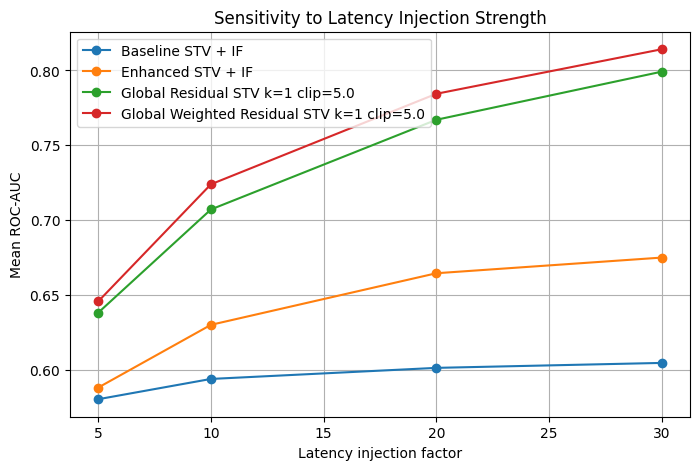

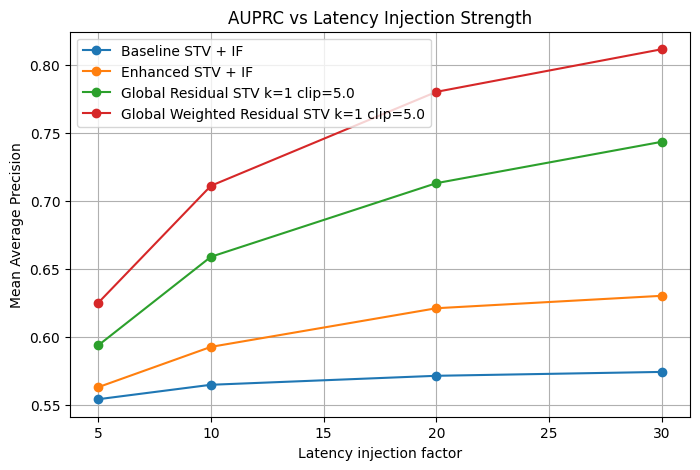

In [89]:
plt.figure(figsize=(8, 5))

for method in SENSITIVITY_KEY_METHODS:
    mdf = sensitivity_key_df[sensitivity_key_df["method"] == method].copy()
    mdf = mdf.sort_values("injection_factor")

    plt.plot(
        mdf["injection_factor"],
        mdf["roc_auc_mean"],
        marker="o",
        label=method
    )

plt.xlabel("Latency injection factor")
plt.ylabel("Mean ROC-AUC")
plt.title("Sensitivity to Latency Injection Strength")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))

for method in SENSITIVITY_KEY_METHODS:
    mdf = sensitivity_key_df[sensitivity_key_df["method"] == method].copy()
    mdf = mdf.sort_values("injection_factor")

    plt.plot(
        mdf["injection_factor"],
        mdf["average_precision_mean"],
        marker="o",
        label=method
    )

plt.xlabel("Latency injection factor")
plt.ylabel("Mean Average Precision")
plt.title("AUPRC vs Latency Injection Strength")
plt.grid(True)
plt.legend()
plt.show()

In [90]:
SENSITIVITY_DIR = RESULTS_DIR / "sensitivity_analysis"
SENSITIVITY_DIR.mkdir(exist_ok=True)

sensitivity_results_df.to_csv(
    SENSITIVITY_DIR / "injection_strength_all_results.csv",
    index=False
)

sensitivity_summary_df.to_csv(
    SENSITIVITY_DIR / "injection_strength_summary.csv",
    index=False
)

sensitivity_key_df.to_csv(
    SENSITIVITY_DIR / "injection_strength_key_methods.csv",
    index=False
)

print("Saved sensitivity analysis to:", SENSITIVITY_DIR)

Saved sensitivity analysis to: /content/drive/MyDrive/anomalies_microservice_trainticket_version_configurations/_processed_phase1/paper_experiment_results/sensitivity_analysis


In [91]:
def check_monotonic_metric(df, method, metric="roc_auc_mean"):
    mdf = df[df["method"] == method].sort_values("injection_factor")
    values = mdf[metric].values
    factors = mdf["injection_factor"].values

    is_monotonic_non_decreasing = np.all(np.diff(values) >= -1e-9)

    return {
        "method": method,
        "metric": metric,
        "factors": factors.tolist(),
        "values": values.tolist(),
        "monotonic_non_decreasing": bool(is_monotonic_non_decreasing),
        "absolute_gain_first_to_last": float(values[-1] - values[0]),
        "relative_gain_first_to_last": float((values[-1] - values[0]) / values[0]) if values[0] != 0 else np.nan,
    }


monotonic_rows = []

for method in SENSITIVITY_KEY_METHODS:
    for metric in ["roc_auc_mean", "average_precision_mean", "f1_mean"]:
        monotonic_rows.append(
            check_monotonic_metric(
                sensitivity_key_df,
                method=method,
                metric=metric
            )
        )

monotonicity_df = pd.DataFrame(monotonic_rows)
display(monotonicity_df)

,method,metric,factors,values,monotonic_non_decreasing,absolute_gain_first_to_last,relative_gain_first_to_last
0,Baseline STV + IF,roc_auc_mean,"[5.0, 10.0, 20.0, 30.0]","[0.5805213866949209, 0.594060474047109, 0.6014...",True,0.024242,0.041759
1,Baseline STV + IF,average_precision_mean,"[5.0, 10.0, 20.0, 30.0]","[0.5541794226180067, 0.5648094863811867, 0.571...",True,0.020094,0.036259
2,Baseline STV + IF,f1_mean,"[5.0, 10.0, 20.0, 30.0]","[0.5568733447948939, 0.5741272213387406, 0.579...",True,0.025894,0.046499
3,Enhanced STV + IF,roc_auc_mean,"[5.0, 10.0, 20.0, 30.0]","[0.5882869641616287, 0.6301861191545929, 0.664...",True,0.086808,0.147561
4,Enhanced STV + IF,average_precision_mean,"[5.0, 10.0, 20.0, 30.0]","[0.5630343712743006, 0.5926934593057946, 0.621...",True,0.067234,0.119414
5,Enhanced STV + IF,f1_mean,"[5.0, 10.0, 20.0, 30.0]","[0.5663101063120924, 0.5955100609420371, 0.636...",True,0.083783,0.147945
6,Global Residual STV k=1 clip=5.0,roc_auc_mean,"[5.0, 10.0, 20.0, 30.0]","[0.6382875277876967, 0.707223351358257, 0.7670...",True,0.160944,0.252149
7,Global Residual STV k=1 clip=5.0,average_precision_mean,"[5.0, 10.0, 20.0, 30.0]","[0.5938003915289388, 0.6589774043758371, 0.713...",True,0.149780,0.252240
8,Global Residual STV k=1 clip=5.0,f1_mean,"[5.0, 10.0, 20.0, 30.0]","[0.5928265855296639, 0.650390336244358, 0.7002...",True,0.133611,0.225380
9,Global Weighted Residual STV k=1 clip=5.0,roc_auc_mean,"[5.0, 10.0, 20.0, 30.0]","[0.6458148887527939, 0.7240251471675737, 0.784...",True,0.168379,0.260723


Runtime / Lightweight Analysis Module

Research Question:
Is WR-STV computationally lightweight compared with IsolationForest-based STV baselines?

Hypothesis:
WR-STV should require little or no model training beyond computing feature statistics, and scoring should be faster or comparable to IsolationForest-based scoring.

Reviewer Benefit:
Supports the claim that WR-STV is practical for lightweight online/offline trace anomaly detection.

Expected Output:
runtime_summary.csv
runtime_by_dataset_seed.csv
feature_dimension_summary.csv

If This Fails:
We weaken the “lightweight” claim and instead call WR-STV “interpretable and representation-efficient.”


In [92]:
def estimate_array_memory_mb(arr):
    """Estimate NumPy array memory in MB."""
    if arr is None:
        return 0.0
    return arr.nbytes / (1024 ** 2)

def time_function(func, *args, repeats=3, **kwargs):
    """
    Run a function multiple times and return mean/std runtime.
    """
    times = []
    result = None
    for _ in range(repeats):
        start = time.perf_counter()
        result = func(*args, **kwargs)
        end = time.perf_counter()
        times.append(end - start)
    return {
        "result": result,
        "time_mean_sec": float(np.mean(times)),
        "time_std_sec": float(np.std(times)),
        "repeats": repeats
    }

In [93]:
def run_runtime_experiment_one_split(
    dataset,
    events,
    random_state,
    config,
    test_size=0.35,
    repeats=3
):
    """
    Measures runtime for one dataset split.

    We measure:
      - STV vocabulary + matrix construction
      - Baseline STV + IF train/score
      - Enhanced STV + IF train/score
      - WR-STV feature stats + scoring
    """

    all_trace_ids = sorted(events["traceID"].unique())

    train_trace_ids, test_trace_ids = train_test_split(
        all_trace_ids,
        test_size=test_size,
        random_state=random_state
    )

    train_events = events[events["traceID"].isin(train_trace_ids)].copy()
    test_events = events[events["traceID"].isin(test_trace_ids)].copy()

    rows = []

    # -------------------------------------------------
    # 1. STV vocabulary construction
    # -------------------------------------------------
    vocab_timing = time_function(
        build_stv_vocab_from_events,
        train_events,
        repeats=repeats
    )

    eval_vocab, key_to_idx = vocab_timing["result"]

    rows.append({
        "dataset": dataset,
        "random_seed": random_state,
        "stage": "build_stv_vocab",
        "time_mean_sec": vocab_timing["time_mean_sec"],
        "time_std_sec": vocab_timing["time_std_sec"],
        "num_train_traces": len(train_trace_ids),
        "num_test_traces": len(test_trace_ids),
        "num_features": len(eval_vocab),
        "memory_mb": 0.0
    })

    # -------------------------------------------------
    # 2. STV matrix construction
    # -------------------------------------------------
    # Using the correct matrix builder function defined earlier
    train_matrix_timing = time_function(
        events_to_stv_matrix_agg,
        train_events,
        key_to_idx,
        repeats=repeats
    )

    train_matrix_trace_ids, x_train_base = train_matrix_timing["result"]

    rows.append({
        "dataset": dataset,
        "random_seed": random_state,
        "stage": "build_train_stv_matrix",
        "time_mean_sec": train_matrix_timing["time_mean_sec"],
        "time_std_sec": train_matrix_timing["time_std_sec"],
        "num_train_traces": len(train_trace_ids),
        "num_test_traces": len(test_trace_ids),
        "num_features": len(eval_vocab),
        "memory_mb": estimate_array_memory_mb(x_train_base)
    })

    eval_matrix_timing = time_function(
        events_to_stv_matrix_agg,
        test_events,
        key_to_idx,
        repeats=repeats
    )

    eval_trace_ids, x_eval_base = eval_matrix_timing["result"]

    rows.append({
        "dataset": dataset,
        "random_seed": random_state,
        "stage": "build_test_stv_matrix",
        "time_mean_sec": eval_matrix_timing["time_mean_sec"],
        "time_std_sec": eval_matrix_timing["time_std_sec"],
        "num_train_traces": len(train_trace_ids),
        "num_test_traces": len(test_trace_ids),
        "num_features": len(eval_vocab),
        "memory_mb": estimate_array_memory_mb(x_eval_base)
    })

    # -------------------------------------------------
    # 3. Baseline STV + IF
    # -------------------------------------------------
    def train_baseline_if():
        model = IsolationForest(
            n_estimators=config.isolation_forest_estimators,
            contamination="auto",
            random_state=random_state
        )
        model.fit(x_train_base)
        return model

    baseline_train_timing = time_function(
        train_baseline_if,
        repeats=repeats
    )

    baseline_model = baseline_train_timing["result"]

    rows.append({
        "dataset": dataset,
        "random_seed": random_state,
        "stage": "baseline_if_train",
        "time_mean_sec": baseline_train_timing["time_mean_sec"],
        "time_std_sec": baseline_train_timing["time_std_sec"],
        "num_train_traces": len(train_trace_ids),
        "num_test_traces": len(test_trace_ids),
        "num_features": len(eval_vocab),
        "memory_mb": estimate_array_memory_mb(x_train_base)
    })

    def score_baseline_if():
        return -baseline_model.score_samples(x_eval_base)

    baseline_score_timing = time_function(
        score_baseline_if,
        repeats=repeats
    )

    rows.append({
        "dataset": dataset,
        "random_seed": random_state,
        "stage": "baseline_if_score",
        "time_mean_sec": baseline_score_timing["time_mean_sec"],
        "time_std_sec": baseline_score_timing["time_std_sec"],
        "num_train_traces": len(train_trace_ids),
        "num_test_traces": len(test_trace_ids),
        "num_features": len(eval_vocab),
        "memory_mb": estimate_array_memory_mb(x_eval_base)
    })

    # -------------------------------------------------
    # 4. Residual stats
    # -------------------------------------------------
    stats_timing = time_function(
        compute_feature_stats_from_train,
        x_train_base,
        repeats=repeats
    )

    feature_means, feature_stds, feature_counts = stats_timing["result"]

    rows.append({
        "dataset": dataset,
        "random_seed": random_state,
        "stage": "wrstv_compute_feature_stats",
        "time_mean_sec": stats_timing["time_mean_sec"],
        "time_std_sec": stats_timing["time_std_sec"],
        "num_train_traces": len(train_trace_ids),
        "num_test_traces": len(test_trace_ids),
        "num_features": len(eval_vocab),
        "memory_mb": (
            estimate_array_memory_mb(feature_means) +
            estimate_array_memory_mb(feature_stds) +
            estimate_array_memory_mb(feature_counts)
        )
    })

    # -------------------------------------------------
    # 5. Enhanced STV + IF
    # -------------------------------------------------
    def transform_train_residual():
        return transform_to_residual_stv(
            x_train_base,
            feature_means,
            feature_stds,
            clip_value=5.0
        )

    train_res_timing = time_function(
        transform_train_residual,
        repeats=repeats
    )

    x_train_res = train_res_timing["result"]

    rows.append({
        "dataset": dataset,
        "random_seed": random_state,
        "stage": "residual_transform_train",
        "time_mean_sec": train_res_timing["time_mean_sec"],
        "time_std_sec": train_res_timing["time_std_sec"],
        "num_train_traces": len(train_trace_ids),
        "num_test_traces": len(test_trace_ids),
        "num_features": len(eval_vocab),
        "memory_mb": estimate_array_memory_mb(x_train_res)
    })

    def transform_eval_residual():
        return transform_to_residual_stv(
            x_eval_base,
            feature_means,
            feature_stds,
            clip_value=5.0
        )

    eval_res_timing = time_function(
        transform_eval_residual,
        repeats=repeats
    )

    x_eval_res = eval_res_timing["result"]

    rows.append({
        "dataset": dataset,
        "random_seed": random_state,
        "stage": "residual_transform_test",
        "time_mean_sec": eval_res_timing["time_mean_sec"],
        "time_std_sec": eval_res_timing["time_std_sec"],
        "num_train_traces": len(train_trace_ids),
        "num_test_traces": len(test_trace_ids),
        "num_features": len(eval_vocab),
        "memory_mb": estimate_array_memory_mb(x_eval_res)
    })

    def train_enhanced_if():
        model = IsolationForest(
            n_estimators=config.isolation_forest_estimators,
            contamination="auto",
            random_state=random_state
        )
        model.fit(x_train_res)
        return model

    enhanced_train_timing = time_function(
        train_enhanced_if,
        repeats=repeats
    )

    enhanced_model = enhanced_train_timing["result"]

    rows.append({
        "dataset": dataset,
        "random_seed": random_state,
        "stage": "enhanced_if_train",
        "time_mean_sec": enhanced_train_timing["time_mean_sec"],
        "time_std_sec": enhanced_train_timing["time_std_sec"],
        "num_train_traces": len(train_trace_ids),
        "num_test_traces": len(test_trace_ids),
        "num_features": len(eval_vocab),
        "memory_mb": estimate_array_memory_mb(x_train_res)
    })

    def score_enhanced_if():
        return -enhanced_model.score_samples(x_eval_res)

    enhanced_score_timing = time_function(
        score_enhanced_if,
        repeats=repeats
    )

    rows.append({
        "dataset": dataset,
        "random_seed": random_state,
        "stage": "enhanced_if_score",
        "time_mean_sec": enhanced_score_timing["time_mean_sec"],
        "time_std_sec": enhanced_score_timing["time_std_sec"],
        "num_train_traces": len(train_trace_ids),
        "num_test_traces": len(test_trace_ids),
        "num_features": len(eval_vocab),
        "memory_mb": estimate_array_memory_mb(x_eval_res)
    })

    # -------------------------------------------------
    # 6. WR-STV scoring
    # -------------------------------------------------
    weight_timing = time_function(
        build_reliability_weights,
        feature_counts,
        repeats=repeats
    )

    feature_weights = weight_timing["result"]

    rows.append({
        "dataset": dataset,
        "random_seed": random_state,
        "stage": "wrstv_build_feature_weights",
        "time_mean_sec": weight_timing["time_mean_sec"],
        "time_std_sec": weight_timing["time_std_sec"],
        "num_train_traces": len(train_trace_ids),
        "num_test_traces": len(test_trace_ids),
        "num_features": len(eval_vocab),
        "memory_mb": estimate_array_memory_mb(feature_weights)
    })

    def score_wrstv():
        return weighted_topk_abs_residual_score(
            x_eval_res,
            feature_weights,
            k=1
        )

    wrstv_score_timing = time_function(
        score_wrstv,
        repeats=repeats
    )

    rows.append({
        "dataset": dataset,
        "random_seed": random_state,
        "stage": "wrstv_score",
        "time_mean_sec": wrstv_score_timing["time_mean_sec"],
        "time_std_sec": wrstv_score_timing["time_std_sec"],
        "num_train_traces": len(train_trace_ids),
        "num_test_traces": len(test_trace_ids),
        "num_features": len(eval_vocab),
        "memory_mb": estimate_array_memory_mb(x_eval_res) + estimate_array_memory_mb(feature_weights)
    })

    return pd.DataFrame(rows)

In [94]:
RUNTIME_SEEDS = [0, 1, 2]
RUNTIME_REPEATS = 3
runtime_rows = []

runtime_config = ExperimentConfig(
    injection_factor=30.0,
    max_spans_to_modify=3,
    isolation_forest_estimators=200,
    clip_values=(5.0,),
    topk_values=(1,)
)

for seed in RUNTIME_SEEDS:
    print(f"\nRuntime seed = {seed}")
    for dataset in DATASETS.keys():
        print(f"Dataset = {dataset}")
        runtime_df = run_runtime_experiment_one_split(
            dataset=dataset,
            events=stv_event_dfs[dataset],
            random_state=seed,
            config=runtime_config,
            test_size=0.35,
            repeats=RUNTIME_REPEATS
        )
        runtime_rows.append(runtime_df)

runtime_all_df = pd.concat(runtime_rows, ignore_index=True)
display(runtime_all_df.head())


Runtime seed = 0
Dataset = dataset_1
Dataset = dataset_2
Dataset = dataset_3

Runtime seed = 1
Dataset = dataset_1
Dataset = dataset_2
Dataset = dataset_3

Runtime seed = 2
Dataset = dataset_1
Dataset = dataset_2
Dataset = dataset_3


,dataset,random_seed,stage,time_mean_sec,time_std_sec,num_train_traces,num_test_traces,num_features,memory_mb
0,dataset_1,0,build_stv_vocab,0.001611,0.000773,174,95,150,0.000000
1,dataset_1,0,build_train_stv_matrix,0.152025,0.008333,174,95,150,0.099564
2,dataset_1,0,build_test_stv_matrix,0.078229,0.001304,174,95,150,0.054359
3,dataset_1,0,baseline_if_train,0.362373,0.018586,174,95,150,0.099564
4,dataset_1,0,baseline_if_score,0.015049,0.000377,174,95,150,0.054359


In [95]:
runtime_summary_df = (
    runtime_all_df
    .groupby("stage")
    .agg(
        time_mean_sec=("time_mean_sec", "mean"),
        time_std_sec=("time_mean_sec", "std"),
        memory_mean_mb=("memory_mb", "mean"),
        memory_std_mb=("memory_mb", "std"),
        num_features_mean=("num_features", "mean"),
        num_train_traces_mean=("num_train_traces", "mean"),
        num_test_traces_mean=("num_test_traces", "mean"),
        runs=("time_mean_sec", "count")
    )
    .reset_index()
    .sort_values("time_mean_sec", ascending=False)
)

display(runtime_summary_df)

,stage,time_mean_sec,time_std_sec,memory_mean_mb,memory_std_mb,num_features_mean,num_train_traces_mean,num_test_traces_mean,runs
1,baseline_if_train,0.424608,0.097496,0.069186,0.027286,168.222222,111.0,60.666667,9
6,enhanced_if_train,0.387400,0.092001,0.069186,0.027286,168.222222,111.0,60.666667,9
4,build_train_stv_matrix,0.116346,0.057899,0.069186,0.027286,168.222222,111.0,60.666667,9
3,build_test_stv_matrix,0.047069,0.021163,0.037812,0.014600,168.222222,111.0,60.666667,9
5,enhanced_if_score,0.018626,0.004869,0.037812,0.014600,168.222222,111.0,60.666667,9
0,baseline_if_score,0.018113,0.004377,0.037812,0.014600,168.222222,111.0,60.666667,9
10,wrstv_compute_feature_stats,0.005019,0.001480,0.001925,0.000171,168.222222,111.0,60.666667,9
11,wrstv_score,0.001324,0.000673,0.038453,0.014560,168.222222,111.0,60.666667,9
2,build_stv_vocab,0.001296,0.000507,0.000000,0.000000,168.222222,111.0,60.666667,9
8,residual_transform_train,0.000222,0.000068,0.069186,0.027286,168.222222,111.0,60.666667,9


In [96]:
def summarize_method_runtime(runtime_all_df):
    """
    Convert stage-level runtime into method-level runtime.

    Baseline STV + IF:
        build vocab + train matrix + test matrix + IF train + IF score

    Enhanced STV + IF:
        build vocab + train/test matrix + feature stats + residual transforms + IF train + IF score

    WR-STV:
        build vocab + train/test matrix + feature stats + residual test transform + weights + WR-STV score
    """

    method_stage_map = {
        "Baseline STV + IF": [
            "build_stv_vocab",
            "build_train_stv_matrix",
            "build_test_stv_matrix",
            "baseline_if_train",
            "baseline_if_score",
        ],
        "Enhanced STV + IF": [
            "build_stv_vocab",
            "build_train_stv_matrix",
            "build_test_stv_matrix",
            "wrstv_compute_feature_stats",
            "residual_transform_train",
            "residual_transform_test",
            "enhanced_if_train",
            "enhanced_if_score",
        ],
        "WR-STV": [
            "build_stv_vocab",
            "build_train_stv_matrix",
            "build_test_stv_matrix",
            "wrstv_compute_feature_stats",
            "residual_transform_test",
            "wrstv_build_feature_weights",
            "wrstv_score",
        ],
    }

    rows = []

    group_cols = ["dataset", "random_seed"]

    for method, stages in method_stage_map.items():
        part = runtime_all_df[runtime_all_df["stage"].isin(stages)].copy()

        per_run = (
            part
            .groupby(group_cols)
            .agg(
                total_time_sec=("time_mean_sec", "sum"),
                max_memory_mb=("memory_mb", "max"),
                num_features=("num_features", "max"),
                num_train_traces=("num_train_traces", "max"),
                num_test_traces=("num_test_traces", "max")
            )
            .reset_index()
        )

        per_run["method"] = method
        rows.append(per_run)

    method_runtime_df = pd.concat(rows, ignore_index=True)

    method_runtime_summary_df = (
        method_runtime_df
        .groupby("method")
        .agg(
            total_time_mean_sec=("total_time_sec", "mean"),
            total_time_std_sec=("total_time_sec", "std"),
            max_memory_mean_mb=("max_memory_mb", "mean"),
            max_memory_std_mb=("max_memory_mb", "std"),
            num_features_mean=("num_features", "mean"),
            num_train_traces_mean=("num_train_traces", "mean"),
            num_test_traces_mean=("num_test_traces", "mean"),
            runs=("total_time_sec", "count")
        )
        .reset_index()
        .sort_values("total_time_mean_sec")
    )

    return method_runtime_df, method_runtime_summary_df
method_runtime_df, method_runtime_summary_df = summarize_method_runtime(runtime_all_df)

display(method_runtime_df.head())
display(method_runtime_summary_df)

,dataset,random_seed,total_time_sec,max_memory_mb,num_features,num_train_traces,num_test_traces,method
0,dataset_1,0,0.609287,0.099564,150,174,95,Baseline STV + IF
1,dataset_1,1,0.626876,0.099564,150,174,95,Baseline STV + IF
2,dataset_1,2,0.880536,0.099564,150,174,95,Baseline STV + IF
3,dataset_2,0,0.646916,0.033989,162,55,31,Baseline STV + IF
4,dataset_2,1,0.426056,0.038185,182,55,31,Baseline STV + IF


,method,total_time_mean_sec,total_time_std_sec,max_memory_mean_mb,max_memory_std_mb,num_features_mean,num_train_traces_mean,num_test_traces_mean,runs
2,WR-STV,0.171197,0.077043,0.069186,0.027286,168.222222,111.0,60.666667,9
1,Enhanced STV + IF,0.576099,0.130019,0.069186,0.027286,168.222222,111.0,60.666667,9
0,Baseline STV + IF,0.607433,0.140537,0.069186,0.027286,168.222222,111.0,60.666667,9


In [97]:
scoring_stages = [
    "baseline_if_score",
    "enhanced_if_score",
    "wrstv_score"
]

scoring_runtime_df = runtime_all_df[
    runtime_all_df["stage"].isin(scoring_stages)
].copy()

scoring_runtime_df["time_per_trace_ms"] = (
    scoring_runtime_df["time_mean_sec"] /
    scoring_runtime_df["num_test_traces"]
) * 1000.0

scoring_summary_df = (
    scoring_runtime_df
    .groupby("stage")
    .agg(
        score_time_mean_sec=("time_mean_sec", "mean"),
        score_time_std_sec=("time_mean_sec", "std"),
        time_per_trace_mean_ms=("time_per_trace_ms", "mean"),
        time_per_trace_std_ms=("time_per_trace_ms", "std"),
        runs=("time_mean_sec", "count")
    )
    .reset_index()
    .sort_values("time_per_trace_mean_ms")
)

display(scoring_summary_df)

,stage,score_time_mean_sec,score_time_std_sec,time_per_trace_mean_ms,time_per_trace_std_ms,runs
2,wrstv_score,0.001324,0.000673,0.022418,0.006629,9
0,baseline_if_score,0.018113,0.004377,0.359864,0.179001,9
1,enhanced_if_score,0.018626,0.004869,0.369457,0.209372,9


In [98]:
RUNTIME_DIR = RESULTS_DIR / "runtime_lightweight_analysis"
RUNTIME_DIR.mkdir(exist_ok=True)

runtime_all_df.to_csv(
    RUNTIME_DIR / "runtime_stage_level.csv",
    index=False
)

runtime_summary_df.to_csv(
    RUNTIME_DIR / "runtime_summary_by_stage.csv",
    index=False
)

method_runtime_df.to_csv(
    RUNTIME_DIR / "runtime_method_level.csv",
    index=False
)

method_runtime_summary_df.to_csv(
    RUNTIME_DIR / "runtime_method_summary.csv",
    index=False
)

scoring_summary_df.to_csv(
    RUNTIME_DIR / "runtime_scoring_per_trace.csv",
    index=False
)

print("Saved runtime analysis to:", RUNTIME_DIR)

Saved runtime analysis to: /content/drive/MyDrive/anomalies_microservice_trainticket_version_configurations/_processed_phase1/paper_experiment_results/runtime_lightweight_analysis


Complexity Bias Table for WR-STV and Baselines
Research Question:

Does WR-STV actually reduce trace-complexity bias compared with raw STV + IF?

Hypothesis:
Baseline STV + IF scores correlate strongly with trace complexity.
WR-STV scores should have lower correlation with num_spans and num_services.

Reviewer Benefit:
Directly supports the central claim of the paper:
"WR-STV reduces trace-complexity bias."

Expected Output:
complexity_bias_all_methods.csv
complexity_bias_summary.csv

If This Fails:
We cannot claim WR-STV reduces complexity bias. We must reframe WR-STV as detection-improving but not bias-reducing.


In [99]:
def compute_score_complexity_correlations(score_df, score_cols):
    """
    Compute Pearson correlations between method scores and trace complexity measures.

    Complexity measures:
      - num_spans
      - num_services
      - total_duration
      - max_span_duration
      - mean_span_duration
    """

    complexity_cols = [
        "num_spans",
        "num_services",
        "total_duration",
        "max_span_duration",
        "mean_span_duration",
    ]

    rows = []

    for score_col in score_cols:
        for complexity_col in complexity_cols:
            if score_col not in score_df.columns or complexity_col not in score_df.columns:
                continue

            clean = score_df[[score_col, complexity_col]].dropna()

            if len(clean) < 3:
                corr = np.nan
            else:
                corr = clean[score_col].corr(clean[complexity_col])

            rows.append({
                "method_score": score_col,
                "complexity_measure": complexity_col,
                "pearson_correlation": corr,
                "n_traces": len(clean),
            })

    return pd.DataFrame(rows)

In [100]:
def align_train_metadata(train_matrix_trace_ids, meta):
    meta_indexed = meta.set_index('traceID')
    rows = []
    for tid in train_matrix_trace_ids:
        row = meta_indexed.loc[tid].to_dict()
        row['traceID'] = tid
        rows.append(row)
    return pd.DataFrame(rows)

# Uses events_to_stv_matrix_agg (aggregated matrix builder) rather than events_to_stv_matrix
def run_complexity_bias_experiment_for_dataset(
    dataset,
    events,
    meta,
    random_state=42,
    test_size=0.35,
    clip_value=5.0,
    min_request_train_samples=3,
    isolation_forest_estimators=200,
):
    all_trace_ids = sorted(events['traceID'].unique())
    train_trace_ids, test_trace_ids = train_test_split(
        all_trace_ids, test_size=test_size, random_state=random_state
    )
    train_events = events[events['traceID'].isin(train_trace_ids)].copy()
    test_events = events[events['traceID'].isin(test_trace_ids)].copy()

    vocab, key_to_idx = build_stv_vocab_from_events(train_events)
    train_matrix_trace_ids, x_train_base = events_to_stv_matrix_agg(train_events, key_to_idx)
    test_matrix_trace_ids, x_test_base = events_to_stv_matrix_agg(test_events, key_to_idx)

    meta_indexed = meta.set_index('traceID')
    test_meta_rows = []
    for tid in test_matrix_trace_ids:
        row = meta_indexed.loc[tid].to_dict()
        row['traceID'] = tid
        test_meta_rows.append(row)
    test_meta_aligned = pd.DataFrame(test_meta_rows)

    base_model = IsolationForest(n_estimators=isolation_forest_estimators, contamination='auto', random_state=random_state)
    base_model.fit(x_train_base)
    baseline_scores = -base_model.score_samples(x_test_base)

    feature_means, feature_stds, feature_counts = compute_feature_stats_from_train(x_train_base)
    x_train_res = transform_to_residual_stv(x_train_base, feature_means, feature_stds, clip_value=clip_value)
    x_test_res = transform_to_residual_stv(x_test_base, feature_means, feature_stds, clip_value=clip_value)
    feature_weights = build_reliability_weights(feature_counts, normalize=True)

    enhanced_model = IsolationForest(n_estimators=isolation_forest_estimators, contamination='auto', random_state=random_state)
    enhanced_model.fit(x_train_res)
    enhanced_scores = -enhanced_model.score_samples(x_test_res)

    global_residual_scores = topk_abs_residual_score(x_test_res, k=1)
    global_weighted_residual_scores = weighted_topk_abs_residual_score(x_test_res, feature_weights, k=1)

    train_meta_aligned = align_train_metadata(train_matrix_trace_ids, meta)
    request_stats = build_request_feature_stats(x_train_base, train_meta_aligned, min_samples=min_request_train_samples)
    x_test_request_res = transform_to_request_aware_residual(x_test_base, test_meta_aligned, request_stats, feature_means, feature_stds, clip_value=clip_value)
    request_weighted_residual_scores = weighted_topk_abs_residual_score(x_test_request_res, feature_weights, k=1)

    score_df = test_meta_aligned.copy()
    score_df['Baseline STV + IF'] = baseline_scores
    score_df['Enhanced STV + IF'] = enhanced_scores
    score_df['Global Residual STV k=1'] = global_residual_scores
    score_df['Global Weighted Residual STV k=1'] = global_weighted_residual_scores
    score_df['Request-Aware Weighted Residual STV k=1'] = request_weighted_residual_scores

    score_cols = ['Baseline STV + IF', 'Enhanced STV + IF', 'Global Residual STV k=1', 'Global Weighted Residual STV k=1', 'Request-Aware Weighted Residual STV k=1']
    corr_df = compute_score_complexity_correlations(score_df, score_cols)
    corr_df['dataset'] = dataset
    corr_df['random_seed'] = random_state
    return {'score_df': score_df, 'correlation_df': corr_df}

COMPLEXITY_SEEDS = [0, 1, 2, 3, 4]
complexity_corr_rows = []
complexity_score_outputs = {}

for seed in COMPLEXITY_SEEDS:
    print(f'\nComplexity-bias seed = {seed}')
    for dataset in DATASETS.keys():
        print(f'Dataset = {dataset}')
        out = run_complexity_bias_experiment_for_dataset(
            dataset=dataset,
            events=stv_event_dfs[dataset],
            meta=trace_meta[dataset],
            random_state=seed
        )
        key = f'{dataset}_seed_{seed}'
        complexity_score_outputs[key] = out
        complexity_corr_rows.append(out['correlation_df'])

complexity_bias_all_df = pd.concat(complexity_corr_rows, ignore_index=True)
display(complexity_bias_all_df.head())


Complexity-bias seed = 0
Dataset = dataset_1
Dataset = dataset_2
Dataset = dataset_3

Complexity-bias seed = 1
Dataset = dataset_1
Dataset = dataset_2
Dataset = dataset_3

Complexity-bias seed = 2
Dataset = dataset_1
Dataset = dataset_2
Dataset = dataset_3

Complexity-bias seed = 3
Dataset = dataset_1
Dataset = dataset_2
Dataset = dataset_3

Complexity-bias seed = 4
Dataset = dataset_1
Dataset = dataset_2
Dataset = dataset_3


,method_score,complexity_measure,pearson_correlation,n_traces,dataset,random_seed
0,Baseline STV + IF,num_spans,0.835350,95,dataset_1,0
1,Baseline STV + IF,num_services,0.954528,95,dataset_1,0
2,Baseline STV + IF,total_duration,0.796065,95,dataset_1,0
3,Baseline STV + IF,max_span_duration,0.632625,95,dataset_1,0
4,Baseline STV + IF,mean_span_duration,-0.041087,95,dataset_1,0


In [101]:
complexity_bias_summary_df = (
    complexity_bias_all_df
    .groupby(["method_score", "complexity_measure"])
    .agg(
        correlation_mean=("pearson_correlation", "mean"),
        correlation_std=("pearson_correlation", "std"),
        correlation_median=("pearson_correlation", "median"),
        runs=("pearson_correlation", "count")
    )
    .reset_index()
)

display(
    complexity_bias_summary_df
    .sort_values(
        ["complexity_measure", "correlation_mean"],
        ascending=[True, False]
    )
)

,method_score,complexity_measure,correlation_mean,correlation_std,correlation_median,runs
0,Baseline STV + IF,max_span_duration,0.569851,0.241482,0.638761,15
5,Enhanced STV + IF,max_span_duration,0.561890,0.247261,0.592956,15
10,Global Residual STV k=1,max_span_duration,0.425189,0.101840,0.436891,15
15,Global Weighted Residual STV k=1,max_span_duration,0.337657,0.090943,0.323041,15
20,Request-Aware Weighted Residual STV k=1,max_span_duration,0.326954,0.077194,0.324381,15
11,Global Residual STV k=1,mean_span_duration,0.308702,0.139491,0.287724,15
21,Request-Aware Weighted Residual STV k=1,mean_span_duration,0.264624,0.133259,0.307836,15
16,Global Weighted Residual STV k=1,mean_span_duration,0.260034,0.134715,0.286342,15
6,Enhanced STV + IF,mean_span_duration,0.036456,0.119045,-0.037877,15
1,Baseline STV + IF,mean_span_duration,0.028034,0.109411,0.007926,15


In [102]:
main_complexity_measures = [
    "num_spans",
    "num_services"
]

main_complexity_bias_df = complexity_bias_summary_df[
    complexity_bias_summary_df["complexity_measure"].isin(main_complexity_measures)
].copy()

main_complexity_bias_pivot = main_complexity_bias_df.pivot(
    index="method_score",
    columns="complexity_measure",
    values="correlation_mean"
).reset_index()

main_complexity_bias_pivot = main_complexity_bias_pivot.sort_values(
    by=["num_spans", "num_services"],
    ascending=False
)

display(main_complexity_bias_pivot)

complexity_measure,method_score,num_services,num_spans
0,Baseline STV + IF,0.867774,0.820162
1,Enhanced STV + IF,0.835497,0.779381
2,Global Residual STV k=1,0.382658,0.323629
3,Global Weighted Residual STV k=1,0.296274,0.238199
4,Request-Aware Weighted Residual STV k=1,0.273924,0.218162


In [103]:
complexity_bias_all_df["abs_pearson_correlation"] = (
    complexity_bias_all_df["pearson_correlation"].abs()
)

complexity_bias_abs_summary_df = (
    complexity_bias_all_df
    .groupby(["method_score", "complexity_measure"])
    .agg(
        abs_correlation_mean=("abs_pearson_correlation", "mean"),
        abs_correlation_std=("abs_pearson_correlation", "std"),
        abs_correlation_median=("abs_pearson_correlation", "median"),
        runs=("abs_pearson_correlation", "count")
    )
    .reset_index()
)

main_abs_complexity_bias_df = complexity_bias_abs_summary_df[
    complexity_bias_abs_summary_df["complexity_measure"].isin(main_complexity_measures)
].copy()

main_abs_complexity_bias_pivot = main_abs_complexity_bias_df.pivot(
    index="method_score",
    columns="complexity_measure",
    values="abs_correlation_mean"
).reset_index()

main_abs_complexity_bias_pivot = main_abs_complexity_bias_pivot.sort_values(
    by=["num_spans", "num_services"],
    ascending=False
)

display(main_abs_complexity_bias_pivot)

complexity_measure,method_score,num_services,num_spans
0,Baseline STV + IF,0.867774,0.831980
1,Enhanced STV + IF,0.835497,0.779381
2,Global Residual STV k=1,0.388834,0.338800
3,Global Weighted Residual STV k=1,0.296274,0.251171
4,Request-Aware Weighted Residual STV k=1,0.273924,0.230892


In [104]:
COMPLEXITY_DIR = RESULTS_DIR / "complexity_bias_analysis"
COMPLEXITY_DIR.mkdir(exist_ok=True)

complexity_bias_all_df.to_csv(
    COMPLEXITY_DIR / "complexity_bias_all_correlations.csv",
    index=False
)

complexity_bias_summary_df.to_csv(
    COMPLEXITY_DIR / "complexity_bias_summary.csv",
    index=False
)

main_complexity_bias_pivot.to_csv(
    COMPLEXITY_DIR / "complexity_bias_main_pivot.csv",
    index=False
)

complexity_bias_abs_summary_df.to_csv(
    COMPLEXITY_DIR / "complexity_bias_abs_summary.csv",
    index=False
)

main_abs_complexity_bias_pivot.to_csv(
    COMPLEXITY_DIR / "complexity_bias_abs_main_pivot.csv",
    index=False
)

print("Saved complexity-bias analysis to:", COMPLEXITY_DIR)

Saved complexity-bias analysis to: /content/drive/MyDrive/anomalies_microservice_trainticket_version_configurations/_processed_phase1/paper_experiment_results/complexity_bias_analysis


In [105]:
display(
    complexity_bias_summary_df[
        complexity_bias_summary_df["complexity_measure"].isin(["num_spans", "num_services"])
    ].sort_values(["complexity_measure", "correlation_mean"], ascending=[True, False])
)

,method_score,complexity_measure,correlation_mean,correlation_std,correlation_median,runs
2,Baseline STV + IF,num_services,0.867774,0.243016,0.954528,15
7,Enhanced STV + IF,num_services,0.835497,0.198958,0.881459,15
12,Global Residual STV k=1,num_services,0.382658,0.147884,0.365543,15
17,Global Weighted Residual STV k=1,num_services,0.296274,0.114158,0.305266,15
22,Request-Aware Weighted Residual STV k=1,num_services,0.273924,0.108846,0.267590,15
3,Baseline STV + IF,num_spans,0.820162,0.264403,0.924044,15
8,Enhanced STV + IF,num_spans,0.779381,0.234318,0.870408,15
13,Global Residual STV k=1,num_spans,0.323629,0.158709,0.351688,15
18,Global Weighted Residual STV k=1,num_spans,0.238199,0.126771,0.233278,15
23,Request-Aware Weighted Residual STV k=1,num_spans,0.218162,0.124028,0.229412,15


Research Question:
Does WR-STV still outperform baselines when latency anomalies are injected into random STV-visible paths instead of the largest-duration visible paths?

Hypothesis:
WR-STV should still improve over raw STV + IF, but performance may decrease compared with largest-visible injection.

Reviewer Benefit:
Addresses the circularity criticism that the current injection favors top-k residual scoring.

Expected Output:
random_visible_injection_results.csv
random_visible_injection_summary.csv

If This Fails:
We must state WR-STV is strongest for high-impact latency deviations and less reliable for arbitrary low-impact path perturbations.



In [106]:
def create_latency_injected_events_random_visible(
    events_df,
    trace_ids_to_inject,
    key_to_idx,
    factor=30.0,
    max_spans_to_modify=3,
    random_state=42,
):
    """
    Create synthetic latency anomalies by modifying random STV-visible spans.

    Difference from v2:
      v2 chooses largest-duration visible spans.
      This variant chooses random visible spans.

    Purpose:
      Reduces evaluation circularity and tests whether WR-STV works beyond
      obvious top-duration perturbations.
    """

    rng = np.random.default_rng(random_state)

    injected_parts = []
    detail_rows = []

    for trace_id in trace_ids_to_inject:
        group = events_df[events_df["traceID"] == trace_id].copy()

        if group.empty:
            continue

        group["_stv_key"] = list(zip(group["serviceName"], group["service_path"]))
        group["_in_vocab"] = group["_stv_key"].apply(lambda key: key in key_to_idx)

        candidates = group[group["_in_vocab"]].copy()

        if candidates.empty:
            continue

        n_candidates = len(candidates)
        k = min(max_spans_to_modify, n_candidates)

        chosen_idx = rng.choice(
            candidates.index.to_numpy(),
            size=k,
            replace=False
        )

        injected_trace_id = f"{trace_id}_inj_random_visible"

        before = group.loc[chosen_idx, "duration"].tolist()
        services = group.loc[chosen_idx, "serviceName"].tolist()
        operations = group.loc[chosen_idx, "operationName"].tolist()
        paths = group.loc[chosen_idx, "service_path"].tolist()

        group.loc[chosen_idx, "duration"] = group.loc[chosen_idx, "duration"] * factor
        after = group.loc[chosen_idx, "duration"].tolist()

        group["traceID"] = injected_trace_id
        group["injected_anomaly_type"] = "random_visible_latency"

        injected_parts.append(
            group.drop(columns=["_stv_key", "_in_vocab"], errors="ignore")
        )

        detail_rows.append({
            "original_traceID": trace_id,
            "injected_traceID": injected_trace_id,
            "num_modified_spans": len(chosen_idx),
            "factor": factor,
            "modified_services": services,
            "modified_operations": operations,
            "modified_paths": paths,
            "before_durations": before,
            "after_durations": after,
            "injection_strategy": "random_visible",
        })

    injected_df = (
        pd.concat(injected_parts, ignore_index=True)
        if injected_parts else pd.DataFrame()
    )

    details_df = pd.DataFrame(detail_rows)

    return injected_df, details_df


In [107]:
def run_synthetic_experiment_with_strategy(
    dataset,
    events,
    meta,
    random_state,
    config,
    injection_strategy="largest_visible",
):
    """
    Run synthetic experiment with selectable injection strategy.

    injection_strategy:
      - "largest_visible": original v2 injection
      - "random_visible": harder random visible-path injection
    """

    all_trace_ids = sorted(events["traceID"].unique())

    train_trace_ids, test_trace_ids = train_test_split(
        all_trace_ids,
        test_size=config.test_size,
        random_state=random_state,
    )

    train_events = events[events["traceID"].isin(train_trace_ids)].copy()
    test_normal_events = events[events["traceID"].isin(test_trace_ids)].copy()

    _, key_to_idx = build_stv_vocab_from_events(train_events)

    if injection_strategy == "largest_visible":
        # "largest_visible" strategy uses the original v2 injector
        injected_events, injection_details = create_latency_injected_events_v2(
            events_df=test_normal_events,
            trace_ids_to_inject=test_trace_ids,
            key_to_idx=key_to_idx,
            factor=config.injection_factor,
            max_spans_to_modify=config.max_spans_to_modify,
        )
        suffix = "_inj_latency_v2"

    elif injection_strategy == "random_visible":
        injected_events, injection_details = create_latency_injected_events_random_visible(
            events_df=test_normal_events,
            trace_ids_to_inject=test_trace_ids,
            key_to_idx=key_to_idx,
            factor=config.injection_factor,
            max_spans_to_modify=config.max_spans_to_modify,
            random_state=random_state,
        )
        suffix = "_inj_random_visible"

    else:
        raise ValueError(f"Unknown injection_strategy: {injection_strategy}")

    test_normal_labeled = test_normal_events.copy()
    test_normal_labeled["injected_anomaly_type"] = "normal"

    eval_events = pd.concat(
        [test_normal_labeled, injected_events],
        ignore_index=True
    )

    # FIXED: Using correct function name events_to_stv_matrix_agg
    train_matrix_trace_ids, x_train_base = events_to_stv_matrix_agg(
        train_events,
        key_to_idx
    )

    eval_trace_ids, x_eval_base = events_to_stv_matrix_agg(
        eval_events,
        key_to_idx
    )

    y_eval = np.array([
        1 if str(tid).endswith(suffix) else 0
        for tid in eval_trace_ids
    ])

    if y_eval.sum() == 0:
        return {
            "results_df": pd.DataFrame(),
            "injection_details": injection_details,
        }

    # Metadata
    train_meta = align_train_metadata(train_matrix_trace_ids, meta)

    meta_indexed = meta.set_index("traceID")
    eval_meta_rows = []

    for trace_id in eval_trace_ids:
        trace_id_str = str(trace_id)
        original_trace_id = trace_id_str.replace(suffix, "")

        row = meta_indexed.loc[original_trace_id].to_dict()
        row["traceID"] = trace_id_str
        row["original_traceID"] = original_trace_id
        row["is_injected"] = trace_id_str.endswith(suffix)

        eval_meta_rows.append(row)

    eval_meta = pd.DataFrame(eval_meta_rows)

    # Baseline IF
    base_model = IsolationForest(
        n_estimators=config.isolation_forest_estimators,
        contamination="auto",
        random_state=random_state
    )

    base_model.fit(x_train_base)
    base_scores = -base_model.score_samples(x_eval_base)

    # Residual stats
    feature_means, feature_stds, feature_counts = compute_feature_stats_from_train(
        x_train_base
    )

    feature_weights = build_reliability_weights(feature_counts, normalize=True)

    x_train_res = transform_to_residual_stv(
        x_train_base,
        feature_means,
        feature_stds,
        clip_value=5.0
    )

    x_eval_res = transform_to_residual_stv(
        x_eval_base,
        feature_means,
        feature_stds,
        clip_value=5.0
    )

    # Enhanced IF
    enhanced_model = IsolationForest(
        n_estimators=config.isolation_forest_estimators,
        contamination="auto",
        random_state=random_state
    )

    enhanced_model.fit(x_train_res)
    enhanced_scores = -enhanced_model.score_samples(x_eval_res)

    # Direct residual scores
    global_residual_scores = topk_abs_residual_score(
        x_eval_res,
        k=1
    )

    global_weighted_scores = weighted_topk_abs_residual_score(
        x_eval_res,
        feature_weights,
        k=1
    )

    # Request-aware weighted residual
    request_stats = build_request_feature_stats(
        x_train_base,
        train_meta,
        min_samples=config.min_request_train_samples
    )

    x_eval_request_res = transform_to_request_aware_residual(
        x_eval_base,
        eval_meta,
        request_stats,
        feature_means,
        feature_stds,
        clip_value=5.0
    )

    request_weighted_scores = weighted_topk_abs_residual_score(
        x_eval_request_res,
        feature_weights,
        k=1
    )

    method_scores = {
        "Baseline STV + IF": base_scores,
        "Enhanced STV + IF": enhanced_scores,
        "Global Residual STV k=1 clip=5.0": global_residual_scores,
        "Global Weighted Residual STV k=1 clip=5.0": global_weighted_scores,
        "Request-Aware Weighted Residual STV k=1 clip=5.0": request_weighted_scores,
    }

    result_rows = []
    pairwise_tables = {}

    for method_name, scores in method_scores.items():
        row = evaluate_scores(method_name, y_eval, scores)

        win_rate, pair_df = pairwise_win_rate(
            eval_trace_ids,
            scores,
            suffix=suffix
        )

        row.update({
            "dataset": dataset,
            "random_seed": random_state,
            "injection_strategy": injection_strategy,
            "injection_factor": config.injection_factor,
            "pairwise_win_rate": win_rate,
            "num_train_traces": len(train_trace_ids),
            "num_test_normal": int((y_eval == 0).sum()),
            "num_test_injected": int((y_eval == 1).sum()),
            "stv_vocab_size": len(key_to_idx),
        })

        result_rows.append(row)
        pairwise_tables[method_name] = pair_df

    results_df = pd.DataFrame(result_rows)

    return {
        "results_df": results_df,
        "pairwise_tables": pairwise_tables,
        "injection_details": injection_details,
        "eval_trace_ids": eval_trace_ids,
        "y_eval": y_eval,
        "eval_meta": eval_meta,
        "method_scores": method_scores,
        "X_eval_base": x_eval_base,
        "feature_means": feature_means,
        "feature_stds": feature_stds,
        "feature_counts": feature_counts,
        "feature_weights": feature_weights,
        "eval_vocab": list(key_to_idx.keys()),
    }

In [108]:
RANDOM_VISIBLE_SEEDS = [0, 1, 2, 3, 4]

random_visible_config = ExperimentConfig(
    30.0, # injection_factor
    3,    # max_spans_to_modify
    200,  # isolation_forest_estimators
    (5.0,), # clip_values
    (1,)    # topk_values
)
# test_size / min_request_train_samples now use ExperimentConfig defaults (0.35 / 3)

random_visible_outputs = {}
random_visible_results = []

for seed in RANDOM_VISIBLE_SEEDS:
    print(f"\nRandom-visible seed = {seed}")

    for ds_key in DATASETS.keys():
        print(f"Dataset = {ds_key}")

        out = run_synthetic_experiment_with_strategy(
            dataset=ds_key,
            events=stv_event_dfs[ds_key],
            meta=trace_meta[ds_key],
            random_state=seed,
            config=random_visible_config,
            injection_strategy="random_visible",
        )

        key = f"{ds_key}_seed_{seed}_random_visible"
        random_visible_outputs[key] = out

        if not out["results_df"].empty:
            random_visible_results.append(out["results_df"])

if random_visible_results:
    random_visible_results_df = pd.concat(
        random_visible_results,
        ignore_index=True
    )
    display(random_visible_results_df.head())
    random_visible_results_df.to_csv(RESULTS_DIR / "random_visible_injection_all_results.csv", index=False)
else:
    print("No results generated.")


Random-visible seed = 0
Dataset = dataset_1
Dataset = dataset_2
Dataset = dataset_3

Random-visible seed = 1
Dataset = dataset_1
Dataset = dataset_2
Dataset = dataset_3

Random-visible seed = 2
Dataset = dataset_1
Dataset = dataset_2
Dataset = dataset_3

Random-visible seed = 3
Dataset = dataset_1
Dataset = dataset_2
Dataset = dataset_3

Random-visible seed = 4
Dataset = dataset_1
Dataset = dataset_2
Dataset = dataset_3


,method,roc_auc,average_precision,precision_at_k,precision,recall,f1,dataset,random_seed,injection_strategy,injection_factor,pairwise_win_rate,num_train_traces,num_test_normal,num_test_injected,stv_vocab_size
0,Baseline STV + IF,0.578947,0.564858,0.568421,0.568421,0.568421,0.568421,dataset_1,0,random_visible,30.0,0.884211,174,95,95,150
1,Enhanced STV + IF,0.688698,0.661449,0.673684,0.673684,0.673684,0.673684,dataset_1,0,random_visible,30.0,0.726316,174,95,95,150
2,Global Residual STV k=1 clip=5.0,0.890748,0.843306,0.831579,0.831579,0.831579,0.831579,dataset_1,0,random_visible,30.0,0.884211,174,95,95,150
3,Global Weighted Residual STV k=1 clip=5.0,0.864654,0.871102,0.789474,0.789474,0.789474,0.789474,dataset_1,0,random_visible,30.0,0.873684,174,95,95,150
4,Request-Aware Weighted Residual STV k=1 clip=5.0,0.861884,0.860349,0.800000,0.800000,0.800000,0.800000,dataset_1,0,random_visible,30.0,0.852632,174,95,95,150


In [109]:
random_visible_summary_df = (
    random_visible_results_df
    .groupby("method")
    .agg(
        roc_auc_mean=("roc_auc", "mean"),
        roc_auc_std=("roc_auc", "std"),
        average_precision_mean=("average_precision", "mean"),
        average_precision_std=("average_precision", "std"),
        f1_mean=("f1", "mean"),
        f1_std=("f1", "std"),
        precision_at_k_mean=("precision_at_k", "mean"),
        pairwise_win_rate_mean=("pairwise_win_rate", "mean"),
        runs=("roc_auc", "count")
    )
    .reset_index()
    .sort_values("roc_auc_mean", ascending=False)
)

display(random_visible_summary_df)

,method,roc_auc_mean,roc_auc_std,average_precision_mean,average_precision_std,f1_mean,f1_std,precision_at_k_mean,pairwise_win_rate_mean,runs
3,Global Weighted Residual STV k=1 clip=5.0,0.810503,0.055804,0.806280,0.056179,0.728980,0.053406,0.728980,0.777162,15
4,Request-Aware Weighted Residual STV k=1 clip=5.0,0.805373,0.057222,0.795311,0.056306,0.728296,0.061667,0.728296,0.768710,15
2,Global Residual STV k=1 clip=5.0,0.797838,0.067379,0.740947,0.083366,0.725545,0.073763,0.725545,0.748654,15
1,Enhanced STV + IF,0.673256,0.044189,0.626736,0.045995,0.649583,0.043552,0.649583,0.660294,15
0,Baseline STV + IF,0.604065,0.026677,0.570360,0.015612,0.582066,0.037105,0.582066,0.814029,15


In [110]:
original_key_methods = multi_seed_summary_df[
    multi_seed_summary_df["method"].isin(random_visible_summary_df["method"])
].copy()

original_key_methods = original_key_methods[
    [
        "method",
        "roc_auc_mean",
        "average_precision_mean",
        "f1_mean",
        "pairwise_win_rate_mean"
    ]
].rename(columns={
    "roc_auc_mean": "largest_visible_roc_auc",
    "average_precision_mean": "largest_visible_ap",
    "f1_mean": "largest_visible_f1",
    "pairwise_win_rate_mean": "largest_visible_pairwise"
})

random_key_methods = random_visible_summary_df[
    [
        "method",
        "roc_auc_mean",
        "average_precision_mean",
        "f1_mean",
        "pairwise_win_rate_mean"
    ]
].rename(columns={
    "roc_auc_mean": "random_visible_roc_auc",
    "average_precision_mean": "random_visible_ap",
    "f1_mean": "random_visible_f1",
    "pairwise_win_rate_mean": "random_visible_pairwise"
})

injection_strategy_comparison_df = original_key_methods.merge(
    random_key_methods,
    on="method",
    how="inner"
)

injection_strategy_comparison_df["roc_auc_drop_random_vs_largest"] = (
    injection_strategy_comparison_df["random_visible_roc_auc"] -
    injection_strategy_comparison_df["largest_visible_roc_auc"]
)

injection_strategy_comparison_df["ap_drop_random_vs_largest"] = (
    injection_strategy_comparison_df["random_visible_ap"] -
    injection_strategy_comparison_df["largest_visible_ap"]
)

display(
    injection_strategy_comparison_df.sort_values(
        "random_visible_roc_auc",
        ascending=False
    )
)


,method,largest_visible_roc_auc,largest_visible_ap,largest_visible_f1,largest_visible_pairwise,random_visible_roc_auc,random_visible_ap,random_visible_f1,random_visible_pairwise,roc_auc_drop_random_vs_largest,ap_drop_random_vs_largest
0,Global Weighted Residual STV k=1 clip=5.0,0.814194,0.811676,0.738103,0.789316,0.810503,0.806280,0.728980,0.777162,-0.003691,-0.005395
1,Request-Aware Weighted Residual STV k=1 clip=5.0,0.808993,0.800266,0.733017,0.780163,0.805373,0.795311,0.728296,0.768710,-0.003619,-0.004954
2,Global Residual STV k=1 clip=5.0,0.799231,0.743580,0.726438,0.754309,0.797838,0.740947,0.725545,0.748654,-0.001393,-0.002633
3,Enhanced STV + IF,0.675095,0.630269,0.650093,0.676296,0.673256,0.626736,0.649583,0.660294,-0.001839,-0.003533
4,Baseline STV + IF,0.604763,0.574273,0.582767,0.818400,0.604065,0.570360,0.582066,0.814029,-0.000699,-0.003914


In [111]:
RANDOM_VISIBLE_DIR = RESULTS_DIR / "random_visible_injection"
RANDOM_VISIBLE_DIR.mkdir(exist_ok=True)

random_visible_results_df.to_csv(
    RANDOM_VISIBLE_DIR / "random_visible_all_results.csv",
    index=False
)

random_visible_summary_df.to_csv(
    RANDOM_VISIBLE_DIR / "random_visible_summary.csv",
    index=False
)

injection_strategy_comparison_df.to_csv(
    RANDOM_VISIBLE_DIR / "largest_vs_random_visible_comparison.csv",
    index=False
)

print("Saved random-visible injection results to:", RANDOM_VISIBLE_DIR)

Saved random-visible injection results to: /content/drive/MyDrive/anomalies_microservice_trainticket_version_configurations/_processed_phase1/paper_experiment_results/random_visible_injection


Research Question:
Does WR-STV outperform additional classical anomaly detection baselines, or only raw STV + IsolationForest?

Hypothesis:
WR-STV should outperform generic outlier detectors on raw STV and be competitive with or better than residual-space baselines.

Reviewer Benefit:
Addresses the criticism that STV + IF is a weak single baseline.

Expected Output:
additional_baselines_results.csv
additional_baselines_summary.csv

If This Fails:
We must reframe WR-STV as a simpler interpretable alternative rather than a performance winner.


In [112]:
def score_lof_train_test(X_train, X_eval, n_neighbors=20):
    """
    Local Outlier Factor novelty detection.

    Uses novelty=True so LOF can score unseen eval data.
    Higher score = more anomalous.
    """

    n_neighbors_eff = min(n_neighbors, max(2, len(X_train) - 1))

    model = LocalOutlierFactor(
        n_neighbors=n_neighbors_eff,
        novelty=True,
        contamination="auto"
    )

    model.fit(X_train)

    # LOF score_samples: higher is more normal, so negate
    scores = -model.score_samples(X_eval)

    return scores


def score_ocsvm_train_test(X_train, X_eval, nu=0.1, gamma="scale"):
    """
    One-Class SVM anomaly scoring.

    Higher score = more anomalous.
    """

    model = OneClassSVM(
        kernel="rbf",
        nu=nu,
        gamma=gamma
    )

    model.fit(X_train)

    # decision_function: higher is more normal, so negate
    scores = -model.decision_function(X_eval)

    return scores


def max_abs_residual_score(X_residual):
    """
    Simple max-z residual baseline.
    Equivalent to top-k residual with k=1 without weighting.
    """
    return np.max(np.abs(X_residual), axis=1)


def mean_top3_abs_residual_score(X_residual):
    """
    Simple unweighted top-3 residual baseline.
    """
    return topk_abs_residual_score(X_residual, k=3)

In [113]:
def run_synthetic_experiment_with_extra_baselines(
    dataset,
    events,
    meta,
    random_state,
    config,
    injection_strategy="random_visible",
):
    """
    Run synthetic evaluation with additional baselines:
      - Baseline STV + IF
      - Enhanced STV + IF
      - LOF on raw STV
      - LOF on residual STV
      - One-Class SVM on raw STV
      - One-Class SVM on residual STV
      - Max-Z residual
      - Top-3 residual
      - WR-STV
    """

    all_trace_ids = sorted(events["traceID"].unique())

    train_trace_ids, test_trace_ids = train_test_split(
        all_trace_ids,
        test_size=config.test_size,
        random_state=random_state,
    )

    train_events = events[events["traceID"].isin(train_trace_ids)].copy()
    test_normal_events = events[events["traceID"].isin(test_trace_ids)].copy()

    _, key_to_idx = build_stv_vocab_from_events(train_events)

    if injection_strategy == "random_visible":
        injected_events, injection_details = create_latency_injected_events_random_visible(
            events_df=test_normal_events,
            trace_ids_to_inject=test_trace_ids,
            key_to_idx=key_to_idx,
            factor=config.injection_factor,
            max_spans_to_modify=config.max_spans_to_modify,
            random_state=random_state,
        )
        suffix = "_inj_random_visible"

    elif injection_strategy == "largest_visible":
        injected_events, injection_details = create_latency_injected_events_v2(
            events_df=test_normal_events,
            trace_ids_to_inject=test_trace_ids,
            key_to_idx=key_to_idx,
            factor=config.injection_factor,
            max_spans_to_modify=config.max_spans_to_modify,
        )
        suffix = "_inj_latency_v2"

    else:
        raise ValueError(f"Unknown injection_strategy: {injection_strategy}")

    test_normal_labeled = test_normal_events.copy()
    test_normal_labeled["injected_anomaly_type"] = "normal"

    eval_events = pd.concat(
        [test_normal_labeled, injected_events],
        ignore_index=True
    )

    # FIXED: using events_to_stv_matrix_agg
    train_matrix_trace_ids, X_train_base = events_to_stv_matrix_agg(
        train_events,
        key_to_idx
    )

    eval_trace_ids, X_eval_base = events_to_stv_matrix_agg(
        eval_events,
        key_to_idx
    )

    y_eval = np.array([
        1 if str(tid).endswith(suffix) else 0
        for tid in eval_trace_ids
    ])

    if y_eval.sum() == 0:
        return {
            "results_df": pd.DataFrame(),
            "injection_details": injection_details,
        }

    X_train_base_filled = X_train_base.copy()
    X_eval_base_filled = X_eval_base.copy()
    X_train_base_filled[X_train_base_filled == -1.0] = 0.0
    X_eval_base_filled[X_eval_base_filled == -1.0] = 0.0

    feature_means, feature_stds, feature_counts = compute_feature_stats_from_train(X_train_base)
    X_train_res = transform_to_residual_stv(X_train_base, feature_means, feature_stds, clip_value=5.0)
    X_eval_res = transform_to_residual_stv(X_eval_base, feature_means, feature_stds, clip_value=5.0)
    feature_weights = build_reliability_weights(feature_counts, normalize=True)

    method_scores = {}

    base_if = IsolationForest(n_estimators=config.isolation_forest_estimators, contamination="auto", random_state=random_state)
    base_if.fit(X_train_base)
    method_scores["Baseline STV + IF"] = -base_if.score_samples(X_eval_base)

    enhanced_if = IsolationForest(n_estimators=config.isolation_forest_estimators, contamination="auto", random_state=random_state)
    enhanced_if.fit(X_train_res)
    method_scores["Enhanced STV + IF"] = -enhanced_if.score_samples(X_eval_res)

    method_scores["Raw STV + LOF"] = score_lof_train_test(X_train_base_filled, X_eval_base_filled, n_neighbors=20)
    method_scores["Residual STV + LOF"] = score_lof_train_test(X_train_res, X_eval_res, n_neighbors=20)

    try:
        method_scores["Raw STV + OCSVM"] = score_ocsvm_train_test(X_train_base_filled, X_eval_base_filled, nu=0.1, gamma="scale")
    except Exception: pass

    try:
        method_scores["Residual STV + OCSVM"] = score_ocsvm_train_test(X_train_res, X_eval_res, nu=0.1, gamma="scale")
    except Exception: pass

    method_scores["Max-Z Residual STV"] = max_abs_residual_score(X_eval_res)
    method_scores["Top-3 Residual STV"] = mean_top3_abs_residual_score(X_eval_res)
    method_scores["WR-STV k=1 clip=5.0"] = weighted_topk_abs_residual_score(X_eval_res, feature_weights, k=1)

    result_rows = []
    for method_name, scores in method_scores.items():
        row = evaluate_scores(method_name, y_eval, scores)
        win_rate, _ = pairwise_win_rate(eval_trace_ids, scores, suffix=suffix)
        row.update({
            "dataset": dataset,
            "random_seed": random_state,
            "injection_strategy": injection_strategy,
            "injection_factor": config.injection_factor,
            "pairwise_win_rate": win_rate,
        })
        result_rows.append(row)

    return {"results_df": pd.DataFrame(result_rows), "injection_details": injection_details}

In [114]:
EXTRA_BASELINE_SEEDS = [0, 1, 2, 3, 4]

# Local aliases used by run_synthetic_experiment_with_extra_baselines
event_dfs = stv_event_dfs
meta_dfs = trace_meta

# The current ExperimentConfig init signature is:
# (injection_factor, max_spans_to_modify, isolation_forest_estimators, clip_values, topk_values)
extra_baseline_config = ExperimentConfig(
    30.0, # injection_factor
    3,    # max_spans_to_modify
    200,  # isolation_forest_estimators
    (5.0,), # clip_values
    (1,)    # topk_values
)

# test_size / min_request_train_samples now use ExperimentConfig defaults (0.35 / 3)

extra_baseline_outputs = {}
extra_baseline_results = []

for seed in EXTRA_BASELINE_SEEDS:
    print(f"\nExtra-baseline seed = {seed}")

    for dataset in DATASETS.keys():
        print(f"Dataset = {dataset}")

        out = run_synthetic_experiment_with_extra_baselines(
            dataset=dataset,
            events=event_dfs[dataset],
            meta=meta_dfs[dataset],
            random_state=seed,
            config=extra_baseline_config,
            injection_strategy="random_visible",
        )

        key = f"{dataset}_seed_{seed}_extra_baselines"
        extra_baseline_outputs[key] = out

        if not out["results_df"].empty:
            extra_baseline_results.append(out["results_df"])

extra_baseline_results_df = pd.concat(
    extra_baseline_results,
    ignore_index=True
)

display(extra_baseline_results_df.head())


Extra-baseline seed = 0
Dataset = dataset_1
Dataset = dataset_2
Dataset = dataset_3

Extra-baseline seed = 1
Dataset = dataset_1
Dataset = dataset_2
Dataset = dataset_3

Extra-baseline seed = 2
Dataset = dataset_1
Dataset = dataset_2
Dataset = dataset_3

Extra-baseline seed = 3
Dataset = dataset_1
Dataset = dataset_2
Dataset = dataset_3

Extra-baseline seed = 4
Dataset = dataset_1
Dataset = dataset_2
Dataset = dataset_3


,method,roc_auc,average_precision,precision_at_k,precision,recall,f1,dataset,random_seed,injection_strategy,injection_factor,pairwise_win_rate
0,Baseline STV + IF,0.578947,0.564858,0.568421,0.568421,0.568421,0.568421,dataset_1,0,random_visible,30.0,0.884211
1,Enhanced STV + IF,0.688698,0.661449,0.673684,0.673684,0.673684,0.673684,dataset_1,0,random_visible,30.0,0.726316
2,Raw STV + LOF,0.665263,0.604944,0.589474,0.589474,0.589474,0.589474,dataset_1,0,random_visible,30.0,1.000000
3,Residual STV + LOF,0.865651,0.807255,0.800000,0.800000,0.800000,0.800000,dataset_1,0,random_visible,30.0,0.947368
4,Raw STV + OCSVM,0.752244,0.782169,0.684211,0.684211,0.684211,0.684211,dataset_1,0,random_visible,30.0,1.000000


In [115]:
extra_baseline_summary_df = (
    extra_baseline_results_df
    .groupby("method")
    .agg(
        roc_auc_mean=("roc_auc", "mean"),
        roc_auc_std=("roc_auc", "std"),
        average_precision_mean=("average_precision", "mean"),
        average_precision_std=("average_precision", "std"),
        f1_mean=("f1", "mean"),
        f1_std=("f1", "std"),
        precision_at_k_mean=("precision_at_k", "mean"),
        pairwise_win_rate_mean=("pairwise_win_rate", "mean"),
        runs=("roc_auc", "count")
    )
    .reset_index()
    .sort_values("roc_auc_mean", ascending=False)
)

display(extra_baseline_summary_df)

,method,roc_auc_mean,roc_auc_std,average_precision_mean,average_precision_std,f1_mean,f1_std,precision_at_k_mean,pairwise_win_rate_mean,runs
8,WR-STV k=1 clip=5.0,0.810503,0.055804,0.806280,0.056179,0.728980,0.053406,0.728980,0.777162,15
2,Max-Z Residual STV,0.797838,0.067379,0.740947,0.083366,0.725545,0.073763,0.725545,0.748654,15
5,Residual STV + LOF,0.785403,0.064777,0.721803,0.065263,0.722030,0.062896,0.722030,0.841277,15
6,Residual STV + OCSVM,0.774860,0.067956,0.713091,0.075816,0.706968,0.061672,0.706968,0.823437,15
7,Top-3 Residual STV,0.771004,0.057996,0.733611,0.075369,0.695221,0.054403,0.695221,0.811406,15
4,Raw STV + OCSVM,0.761105,0.023824,0.756825,0.048884,0.675910,0.044179,0.675910,0.989429,15
3,Raw STV + LOF,0.707061,0.047136,0.637492,0.032048,0.610606,0.041987,0.610606,1.000000,15
1,Enhanced STV + IF,0.673256,0.044189,0.626736,0.045995,0.649583,0.043552,0.649583,0.660294,15
0,Baseline STV + IF,0.604065,0.026677,0.570360,0.015612,0.582066,0.037105,0.582066,0.814029,15


In [116]:
EXTRA_BASELINE_DIR = RESULTS_DIR / "extra_baselines_random_visible"
EXTRA_BASELINE_DIR.mkdir(exist_ok=True)

extra_baseline_results_df.to_csv(
    EXTRA_BASELINE_DIR / "extra_baseline_all_results.csv",
    index=False
)

extra_baseline_summary_df.to_csv(
    EXTRA_BASELINE_DIR / "extra_baseline_summary.csv",
    index=False
)

print("Saved extra baseline results to:", EXTRA_BASELINE_DIR)

Saved extra baseline results to: /content/drive/MyDrive/anomalies_microservice_trainticket_version_configurations/_processed_phase1/paper_experiment_results/extra_baselines_random_visible


In [117]:
EXTRA_BASELINE_TARGET = "WR-STV k=1 clip=5.0"

EXTRA_BASELINE_COMPARISONS = [
    "Max-Z Residual STV",
    "Residual STV + LOF",
    "Residual STV + OCSVM",
    "Top-3 Residual STV",
    "Raw STV + OCSVM",
    "Raw STV + LOF",
    "Enhanced STV + IF",
    "Baseline STV + IF",
]

def paired_test_against_target(
    results_df,
    target_method,
    comparison_methods,
    pair_cols,
    metrics=("roc_auc", "average_precision", "f1")
):
    rows = []

    for comparison_method in comparison_methods:
        for metric in metrics:
            target = results_df[results_df["method"] == target_method][
                pair_cols + [metric]
            ].rename(columns={metric: "target"})

            comp = results_df[results_df["method"] == comparison_method][
                pair_cols + [metric]
            ].rename(columns={metric: "comparison"})

            merged = target.merge(comp, on=pair_cols, how="inner")

            if merged.empty:
                continue

            diffs = merged["target"] - merged["comparison"]

            try:
                t_stat, t_p = ttest_rel(merged["target"], merged["comparison"])
            except Exception:
                t_stat, t_p = np.nan, np.nan

            try:
                w_stat, w_p = wilcoxon(merged["target"], merged["comparison"])
            except Exception:
                w_stat, w_p = np.nan, np.nan

            rows.append({
                "target_method": target_method,
                "comparison_method": comparison_method,
                "metric": metric,
                "n_pairs": len(merged),
                "mean_target": merged["target"].mean(),
                "mean_comparison": merged["comparison"].mean(),
                "mean_diff_target_minus_comparison": diffs.mean(),
                "median_diff": diffs.median(),
                "std_diff": diffs.std(),
                "cohen_dz": cohen_dz(diffs),
                "paired_t_p_value": t_p,
                "wilcoxon_p_value": w_p,
            })

    return pd.DataFrame(rows)
extra_baseline_stat_tests_df = paired_test_against_target(
    results_df=extra_baseline_results_df,
    target_method=EXTRA_BASELINE_TARGET,
    comparison_methods=EXTRA_BASELINE_COMPARISONS,
    pair_cols=["dataset", "random_seed"],
    metrics=("roc_auc", "average_precision", "f1")
)

display(
    extra_baseline_stat_tests_df.sort_values(
        ["metric", "mean_diff_target_minus_comparison"],
        ascending=[True, False]
    )
)

,target_method,comparison_method,metric,n_pairs,mean_target,mean_comparison,mean_diff_target_minus_comparison,median_diff,std_diff,cohen_dz,paired_t_p_value,wilcoxon_p_value
22,WR-STV k=1 clip=5.0,Baseline STV + IF,average_precision,15,0.806280,0.570360,0.235921,0.260752,0.057834,4.079254,2.556768e-10,0.000061
19,WR-STV k=1 clip=5.0,Enhanced STV + IF,average_precision,15,0.806280,0.626736,0.179544,0.187613,0.035964,4.992396,1.699294e-11,0.000061
16,WR-STV k=1 clip=5.0,Raw STV + LOF,average_precision,15,0.806280,0.637492,0.168788,0.159946,0.075861,2.224979,5.705041e-07,0.000061
7,WR-STV k=1 clip=5.0,Residual STV + OCSVM,average_precision,15,0.806280,0.713091,0.093190,0.092343,0.036454,2.556351,1.056896e-07,0.000061
4,WR-STV k=1 clip=5.0,Residual STV + LOF,average_precision,15,0.806280,0.721803,0.084477,0.083991,0.031477,2.683769,5.774692e-08,0.000061
10,WR-STV k=1 clip=5.0,Top-3 Residual STV,average_precision,15,0.806280,0.733611,0.072669,0.069409,0.037847,1.920048,3.171757e-06,0.000061
1,WR-STV k=1 clip=5.0,Max-Z Residual STV,average_precision,15,0.806280,0.740947,0.065333,0.079739,0.044100,1.481484,5.133334e-05,0.000305
13,WR-STV k=1 clip=5.0,Raw STV + OCSVM,average_precision,15,0.806280,0.756825,0.049456,0.049441,0.031665,1.561834,2.992516e-05,0.000183
23,WR-STV k=1 clip=5.0,Baseline STV + IF,f1,15,0.728980,0.582066,0.146914,0.153846,0.055025,2.669950,6.159177e-08,0.000979
17,WR-STV k=1 clip=5.0,Raw STV + LOF,f1,15,0.728980,0.610606,0.118374,0.127273,0.072303,1.637205,1.825984e-05,0.001464


In [118]:
EXTRA_BASELINE_DIR = RESULTS_DIR / "extra_baselines_random_visible"
EXTRA_BASELINE_DIR.mkdir(exist_ok=True)

extra_baseline_stat_tests_df.to_csv(
    EXTRA_BASELINE_DIR / "extra_baseline_statistical_tests_vs_wrstv.csv",
    index=False
)

print("Saved extra baseline statistical tests.")


Saved extra baseline statistical tests.


VALIDATE k=1 and Clip =5

In [119]:
def tune_wrstv_hyperparams_on_validation(
    dataset,
    events,
    meta,
    random_state,
    candidate_k_values=(1, 3, 5),
    candidate_clip_values=(3.0, 5.0, 10.0),
    outer_train_size=0.65,
    validation_size_within_train=0.30,
    injection_factor=30.0,
    max_spans_to_modify=3,
    injection_strategy="random_visible",
):
    """
    Tune WR-STV hyperparameters using an inner validation split.
    """
    all_trace_ids = sorted(events["traceID"].unique())

    outer_train_ids, _outer_test_ids = train_test_split(
        all_trace_ids,
        train_size=outer_train_size,
        random_state=random_state
    )

    inner_train_ids, val_ids = train_test_split(
        outer_train_ids,
        test_size=validation_size_within_train,
        random_state=random_state
    )

    inner_train_events = events[events["traceID"].isin(inner_train_ids)].copy()
    val_normal_events = events[events["traceID"].isin(val_ids)].copy()

    vocab, key_to_idx = build_stv_vocab_from_events(inner_train_events)

    if injection_strategy == "random_visible":
        injected_events, injection_details = create_latency_injected_events_random_visible(
            events_df=val_normal_events,
            trace_ids_to_inject=val_ids,
            key_to_idx=key_to_idx,
            factor=injection_factor,
            max_spans_to_modify=max_spans_to_modify,
            random_state=random_state,
        )
        suffix = "_inj_random_visible"
    else:
        injected_events, injection_details = create_latency_injected_events_v2(
            events_df=val_normal_events,
            trace_ids_to_inject=val_ids,
            key_to_idx=key_to_idx,
            factor=injection_factor,
            max_spans_to_modify=max_spans_to_modify,
        )
        suffix = "_inj_latency_v2"

    val_normal_labeled = val_normal_events.copy()
    val_normal_labeled["injected_anomaly_type"] = "normal"
    val_eval_events = pd.concat([val_normal_labeled, injected_events], ignore_index=True)

    # FIXED: Use events_to_stv_matrix_agg instead of events_to_stv_matrix
    inner_train_trace_ids, X_inner_train = events_to_stv_matrix_agg(inner_train_events, key_to_idx)
    val_eval_trace_ids, X_val_eval = events_to_stv_matrix_agg(val_eval_events, key_to_idx)

    y_val = np.array([1 if str(tid).endswith(suffix) else 0 for tid in val_eval_trace_ids])
    if y_val.sum() == 0: return pd.DataFrame()

    feature_means, feature_stds, feature_counts = compute_feature_stats_from_train(X_inner_train)
    feature_weights = build_reliability_weights(feature_counts, normalize=True)

    rows = []
    for clip_value in candidate_clip_values:
        X_val_res = transform_to_residual_stv(X_val_eval, feature_means, feature_stds, clip_value=clip_value)
        for k in candidate_k_values:
            scores = weighted_topk_abs_residual_score(X_val_res, feature_weights, k=k)
            row = evaluate_scores(name=f"WR-STV k={k} clip={clip_value}", y_true=y_val, scores=scores)
            win_rate, _ = pairwise_win_rate(val_eval_trace_ids, scores, suffix=suffix)
            row.update({"dataset": dataset, "random_seed": random_state, "k": k, "clip_value": clip_value, "pairwise_win_rate": win_rate})
            rows.append(row)
    return pd.DataFrame(rows)

In [120]:
VALIDATION_SEEDS = [0, 1, 2, 3, 4]

candidate_k_values = (1, 3, 5)
candidate_clip_values = (3.0, 5.0, 10.0)

validation_tuning_rows = []

for seed in VALIDATION_SEEDS:
    print(f"\nValidation tuning seed = {seed}")

    for dataset in DATASETS.keys():
        print(f"Dataset = {dataset}")

        val_df = tune_wrstv_hyperparams_on_validation(
            dataset=dataset,
            events=event_dfs[dataset],
            meta=meta_dfs[dataset],
            random_state=seed,
            candidate_k_values=candidate_k_values,
            candidate_clip_values=candidate_clip_values,
            outer_train_size=0.65,
            validation_size_within_train=0.30,
            injection_factor=30.0,
            max_spans_to_modify=3,
            injection_strategy="random_visible",
        )

        if not val_df.empty:
            validation_tuning_rows.append(val_df)

validation_tuning_df = pd.concat(validation_tuning_rows, ignore_index=True)

display(validation_tuning_df.head())


Validation tuning seed = 0
Dataset = dataset_1
Dataset = dataset_2
Dataset = dataset_3

Validation tuning seed = 1
Dataset = dataset_1
Dataset = dataset_2
Dataset = dataset_3

Validation tuning seed = 2
Dataset = dataset_1
Dataset = dataset_2
Dataset = dataset_3

Validation tuning seed = 3
Dataset = dataset_1
Dataset = dataset_2
Dataset = dataset_3

Validation tuning seed = 4
Dataset = dataset_1
Dataset = dataset_2
Dataset = dataset_3


,method,roc_auc,average_precision,precision_at_k,precision,recall,f1,dataset,random_seed,k,clip_value,pairwise_win_rate
0,WR-STV k=1 clip=3.0,0.794673,0.808057,0.725490,0.725490,0.725490,0.725490,dataset_1,0,1,3.0,0.647059
1,WR-STV k=3 clip=3.0,0.774325,0.813464,0.666667,0.666667,0.666667,0.666667,dataset_1,0,3,3.0,0.784314
2,WR-STV k=5 clip=3.0,0.758417,0.771656,0.647059,0.647059,0.647059,0.647059,dataset_1,0,5,3.0,0.784314
3,WR-STV k=1 clip=5.0,0.809101,0.818057,0.725490,0.725490,0.725490,0.725490,dataset_1,0,1,5.0,0.666667
4,WR-STV k=3 clip=5.0,0.793193,0.821106,0.725490,0.725490,0.725490,0.725490,dataset_1,0,3,5.0,0.784314


In [121]:
validation_tuning_summary_df = (
    validation_tuning_df
    .groupby(["k", "clip_value"])
    .agg(
        roc_auc_mean=("roc_auc", "mean"),
        roc_auc_std=("roc_auc", "std"),
        average_precision_mean=("average_precision", "mean"),
        average_precision_std=("average_precision", "std"),
        f1_mean=("f1", "mean"),
        f1_std=("f1", "std"),
        pairwise_win_rate_mean=("pairwise_win_rate", "mean"),
        runs=("roc_auc", "count")
    )
    .reset_index()
    .sort_values(
        ["roc_auc_mean", "average_precision_mean", "f1_mean"],
        ascending=False
    )
)

display(validation_tuning_summary_df)


,k,clip_value,roc_auc_mean,roc_auc_std,average_precision_mean,average_precision_std,f1_mean,f1_std,pairwise_win_rate_mean,runs
1,1,5.0,0.801831,0.056322,0.785644,0.063807,0.708653,0.081641,0.716738,15
2,1,10.0,0.796071,0.055946,0.769279,0.065940,0.718834,0.083889,0.755381,15
5,3,10.0,0.784520,0.051734,0.775542,0.065823,0.710795,0.071586,0.815615,15
4,3,5.0,0.783642,0.051569,0.789044,0.057424,0.701411,0.069590,0.797398,15
0,1,3.0,0.781478,0.058202,0.760548,0.078379,0.666437,0.090660,0.646190,15
8,5,10.0,0.778817,0.050987,0.762721,0.073150,0.709630,0.056662,0.825927,15
7,5,5.0,0.776194,0.049072,0.773050,0.064780,0.695310,0.051921,0.807686,15
3,3,3.0,0.764524,0.047097,0.771548,0.059059,0.670200,0.047157,0.770111,15
6,5,3.0,0.754890,0.043619,0.754380,0.058095,0.659020,0.047427,0.778971,15


In [122]:
best_validation_setting = validation_tuning_summary_df.iloc[0]

SELECTED_K = int(best_validation_setting["k"])
SELECTED_CLIP = float(best_validation_setting["clip_value"])

print("Selected WR-STV hyperparameters from validation:")
print("k =", SELECTED_K)
print("clip =", SELECTED_CLIP)
print(best_validation_setting)

Selected WR-STV hyperparameters from validation:
k = 1
clip = 5.0
k                          1.000000
clip_value                 5.000000
roc_auc_mean               0.801831
roc_auc_std                0.056322
average_precision_mean     0.785644
average_precision_std      0.063807
f1_mean                    0.708653
f1_std                     0.081641
pairwise_win_rate_mean     0.716738
runs                      15.000000
Name: 1, dtype: float64


In [123]:
VALIDATION_DIR = RESULTS_DIR / "hyperparameter_validation"
VALIDATION_DIR.mkdir(exist_ok=True)

validation_tuning_df.to_csv(
    VALIDATION_DIR / "wrstv_hyperparameter_validation_all.csv",
    index=False
)

validation_tuning_summary_df.to_csv(
    VALIDATION_DIR / "wrstv_hyperparameter_validation_summary.csv",
    index=False
)

print("Saved validation tuning results to:", VALIDATION_DIR)

Saved validation tuning results to: /content/drive/MyDrive/anomalies_microservice_trainticket_version_configurations/_processed_phase1/paper_experiment_results/hyperparameter_validation


Random-visible injection strength sensitivity


In [124]:
RANDOM_VISIBLE_FACTORS = [5.0, 10.0, 20.0, 30.0]
RANDOM_VISIBLE_SENSITIVITY_SEEDS = [0, 1, 2, 3, 4]

random_visible_sensitivity_rows = []

for factor in RANDOM_VISIBLE_FACTORS:
    print(f"\n==============================")
    print(f"Random-visible injection factor = {factor}")
    print(f"==============================")

    # Initialize with the 5 positional arguments required by the class definition
    rv_config = ExperimentConfig(
        injection_factor=factor,
        max_spans_to_modify=3,
        isolation_forest_estimators=200,
        clip_values=(5.0,),
        topk_values=(1,)
    )
    # test_size / min_request_train_samples now use ExperimentConfig defaults (0.35 / 3)

    for seed in RANDOM_VISIBLE_SENSITIVITY_SEEDS:
        print(f"\nSeed = {seed}")

        for dataset in DATASETS.keys():
            print(f"Dataset = {dataset}")

            out = run_synthetic_experiment_with_strategy(
                dataset=dataset,
                events=event_dfs[dataset],
                meta=meta_dfs[dataset],
                random_state=seed,
                config=rv_config,
                injection_strategy="random_visible",
            )

            if not out["results_df"].empty:
                df = out["results_df"].copy()
                df["injection_factor"] = factor
                df["random_seed"] = seed
                df["dataset"] = dataset
                df["injection_strategy"] = "random_visible"

                random_visible_sensitivity_rows.append(df)

random_visible_sensitivity_df = pd.concat(
    random_visible_sensitivity_rows,
    ignore_index=True
)

display(random_visible_sensitivity_df.head())


Random-visible injection factor = 5.0

Seed = 0
Dataset = dataset_1
Dataset = dataset_2
Dataset = dataset_3

Seed = 1
Dataset = dataset_1
Dataset = dataset_2
Dataset = dataset_3

Seed = 2
Dataset = dataset_1
Dataset = dataset_2
Dataset = dataset_3

Seed = 3
Dataset = dataset_1
Dataset = dataset_2
Dataset = dataset_3

Seed = 4
Dataset = dataset_1
Dataset = dataset_2
Dataset = dataset_3

Random-visible injection factor = 10.0

Seed = 0
Dataset = dataset_1
Dataset = dataset_2
Dataset = dataset_3

Seed = 1
Dataset = dataset_1
Dataset = dataset_2
Dataset = dataset_3

Seed = 2
Dataset = dataset_1
Dataset = dataset_2
Dataset = dataset_3

Seed = 3
Dataset = dataset_1
Dataset = dataset_2
Dataset = dataset_3

Seed = 4
Dataset = dataset_1
Dataset = dataset_2
Dataset = dataset_3

Random-visible injection factor = 20.0

Seed = 0
Dataset = dataset_1
Dataset = dataset_2
Dataset = dataset_3

Seed = 1
Dataset = dataset_1
Dataset = dataset_2
Dataset = dataset_3

Seed = 2
Dataset = dataset_1
Dataset = d

,method,roc_auc,average_precision,precision_at_k,precision,recall,f1,dataset,random_seed,injection_strategy,injection_factor,pairwise_win_rate,num_train_traces,num_test_normal,num_test_injected,stv_vocab_size
0,Baseline STV + IF,0.554072,0.540500,0.536842,0.536842,0.536842,0.536842,dataset_1,0,random_visible,5.0,0.852632,174,95,95,150
1,Enhanced STV + IF,0.616842,0.593629,0.568421,0.568421,0.568421,0.568421,dataset_1,0,random_visible,5.0,0.621053,174,95,95,150
2,Global Residual STV k=1 clip=5.0,0.715291,0.663827,0.652632,0.652632,0.652632,0.652632,dataset_1,0,random_visible,5.0,0.747368,174,95,95,150
3,Global Weighted Residual STV k=1 clip=5.0,0.696066,0.679661,0.610526,0.610526,0.610526,0.610526,dataset_1,0,random_visible,5.0,0.768421,174,95,95,150
4,Request-Aware Weighted Residual STV k=1 clip=5.0,0.695457,0.659670,0.621053,0.621053,0.621053,0.621053,dataset_1,0,random_visible,5.0,0.747368,174,95,95,150


In [125]:
random_visible_sensitivity_summary_df = (
    random_visible_sensitivity_df
    .groupby(["method", "injection_factor"])
    .agg(
        roc_auc_mean=("roc_auc", "mean"),
        roc_auc_std=("roc_auc", "std"),
        average_precision_mean=("average_precision", "mean"),
        average_precision_std=("average_precision", "std"),
        f1_mean=("f1", "mean"),
        f1_std=("f1", "std"),
        precision_at_k_mean=("precision_at_k", "mean"),
        pairwise_win_rate_mean=("pairwise_win_rate", "mean"),
        runs=("roc_auc", "count")
    )
    .reset_index()
)

display(
    random_visible_sensitivity_summary_df
    .sort_values(["method", "injection_factor"])
)


,method,injection_factor,roc_auc_mean,roc_auc_std,average_precision_mean,average_precision_std,f1_mean,f1_std,precision_at_k_mean,pairwise_win_rate_mean,runs
0,Baseline STV + IF,5.0,0.579763,0.024127,0.546636,0.011276,0.556873,0.029763,0.556873,0.765928,15
1,Baseline STV + IF,10.0,0.593154,0.024563,0.557068,0.013420,0.573425,0.036570,0.573425,0.785029,15
2,Baseline STV + IF,20.0,0.600580,0.026380,0.566826,0.014937,0.578146,0.037107,0.578146,0.804806,15
3,Baseline STV + IF,30.0,0.604065,0.026677,0.570360,0.015612,0.582066,0.037105,0.582066,0.814029,15
4,Enhanced STV + IF,5.0,0.587428,0.032914,0.559502,0.035492,0.564205,0.034230,0.564205,0.497145,15
5,Enhanced STV + IF,10.0,0.628592,0.041396,0.589038,0.043211,0.596531,0.050504,0.596531,0.576833,15
6,Enhanced STV + IF,20.0,0.662319,0.045031,0.616560,0.046257,0.634431,0.045325,0.634431,0.633720,15
7,Enhanced STV + IF,30.0,0.673256,0.044189,0.626736,0.045995,0.649583,0.043552,0.649583,0.660294,15
8,Global Residual STV k=1 clip=5.0,5.0,0.634800,0.047822,0.589943,0.049294,0.586702,0.047192,0.586702,0.571990,15
9,Global Residual STV k=1 clip=5.0,10.0,0.704436,0.065020,0.654812,0.066822,0.647583,0.075054,0.647583,0.664925,15


In [126]:
RANDOM_VISIBLE_KEY_METHODS = [
    "Baseline STV + IF",
    "Enhanced STV + IF",
    "Global Residual STV k=1 clip=5.0",
    "Global Weighted Residual STV k=1 clip=5.0",
    "Request-Aware Weighted Residual STV k=1 clip=5.0",
]

random_visible_sensitivity_key_df = random_visible_sensitivity_summary_df[
    random_visible_sensitivity_summary_df["method"].isin(RANDOM_VISIBLE_KEY_METHODS)
].copy()

display(
    random_visible_sensitivity_key_df
    .sort_values(["method", "injection_factor"])
)


,method,injection_factor,roc_auc_mean,roc_auc_std,average_precision_mean,average_precision_std,f1_mean,f1_std,precision_at_k_mean,pairwise_win_rate_mean,runs
0,Baseline STV + IF,5.0,0.579763,0.024127,0.546636,0.011276,0.556873,0.029763,0.556873,0.765928,15
1,Baseline STV + IF,10.0,0.593154,0.024563,0.557068,0.013420,0.573425,0.036570,0.573425,0.785029,15
2,Baseline STV + IF,20.0,0.600580,0.026380,0.566826,0.014937,0.578146,0.037107,0.578146,0.804806,15
3,Baseline STV + IF,30.0,0.604065,0.026677,0.570360,0.015612,0.582066,0.037105,0.582066,0.814029,15
4,Enhanced STV + IF,5.0,0.587428,0.032914,0.559502,0.035492,0.564205,0.034230,0.564205,0.497145,15
5,Enhanced STV + IF,10.0,0.628592,0.041396,0.589038,0.043211,0.596531,0.050504,0.596531,0.576833,15
6,Enhanced STV + IF,20.0,0.662319,0.045031,0.616560,0.046257,0.634431,0.045325,0.634431,0.633720,15
7,Enhanced STV + IF,30.0,0.673256,0.044189,0.626736,0.045995,0.649583,0.043552,0.649583,0.660294,15
8,Global Residual STV k=1 clip=5.0,5.0,0.634800,0.047822,0.589943,0.049294,0.586702,0.047192,0.586702,0.571990,15
9,Global Residual STV k=1 clip=5.0,10.0,0.704436,0.065020,0.654812,0.066822,0.647583,0.075054,0.647583,0.664925,15


In [127]:
random_visible_monotonic_rows = []

for method in RANDOM_VISIBLE_KEY_METHODS:
    for metric in ["roc_auc_mean", "average_precision_mean", "f1_mean"]:
        if method in random_visible_sensitivity_key_df["method"].unique():
            random_visible_monotonic_rows.append(
                check_monotonic_metric(
                    random_visible_sensitivity_key_df,
                    method=method,
                    metric=metric
                )
            )

random_visible_monotonicity_df = pd.DataFrame(random_visible_monotonic_rows)

display(random_visible_monotonicity_df)

,method,metric,factors,values,monotonic_non_decreasing,absolute_gain_first_to_last,relative_gain_first_to_last
0,Baseline STV + IF,roc_auc_mean,"[5.0, 10.0, 20.0, 30.0]","[0.5797630940296342, 0.5931537150088899, 0.600...",True,0.024302,0.041917
1,Baseline STV + IF,average_precision_mean,"[5.0, 10.0, 20.0, 30.0]","[0.5466363081431612, 0.5570680921720478, 0.566...",True,0.023723,0.043399
2,Baseline STV + IF,f1_mean,"[5.0, 10.0, 20.0, 30.0]","[0.5568733447948939, 0.5734254669527757, 0.578...",True,0.025192,0.045239
3,Enhanced STV + IF,roc_auc_mean,"[5.0, 10.0, 20.0, 30.0]","[0.5874281777629425, 0.6285921078279207, 0.662...",True,0.085828,0.146108
4,Enhanced STV + IF,average_precision_mean,"[5.0, 10.0, 20.0, 30.0]","[0.5595020324276997, 0.5890384351003011, 0.616...",True,0.067234,0.120167
5,Enhanced STV + IF,f1_mean,"[5.0, 10.0, 20.0, 30.0]","[0.5642048431541976, 0.5965307945943497, 0.634...",True,0.085378,0.151324
6,Global Residual STV k=1 clip=5.0,roc_auc_mean,"[5.0, 10.0, 20.0, 30.0]","[0.6348004741112042, 0.704435783376322, 0.7663...",True,0.163038,0.256833
7,Global Residual STV k=1 clip=5.0,average_precision_mean,"[5.0, 10.0, 20.0, 30.0]","[0.5899425637065598, 0.6548120194608147, 0.710...",True,0.151004,0.255964
8,Global Residual STV k=1 clip=5.0,f1_mean,"[5.0, 10.0, 20.0, 30.0]","[0.5867021836157884, 0.6475833187004985, 0.697...",True,0.138843,0.236649
9,Global Weighted Residual STV k=1 clip=5.0,roc_auc_mean,"[5.0, 10.0, 20.0, 30.0]","[0.6413491606447624, 0.7191540422156543, 0.780...",True,0.169153,0.263746


In [128]:
RV_SENSITIVITY_DIR = RESULTS_DIR / "random_visible_sensitivity"
RV_SENSITIVITY_DIR.mkdir(exist_ok=True)

random_visible_sensitivity_df.to_csv(
    RV_SENSITIVITY_DIR / "random_visible_sensitivity_all.csv",
    index=False
)

random_visible_sensitivity_summary_df.to_csv(
    RV_SENSITIVITY_DIR / "random_visible_sensitivity_summary.csv",
    index=False
)

random_visible_sensitivity_key_df.to_csv(
    RV_SENSITIVITY_DIR / "random_visible_sensitivity_key_methods.csv",
    index=False
)

random_visible_monotonicity_df.to_csv(
    RV_SENSITIVITY_DIR / "random_visible_sensitivity_monotonicity.csv",
    index=False
)

print("Saved random-visible sensitivity outputs to:", RV_SENSITIVITY_DIR)

Saved random-visible sensitivity outputs to: /content/drive/MyDrive/anomalies_microservice_trainticket_version_configurations/_processed_phase1/paper_experiment_results/random_visible_sensitivity


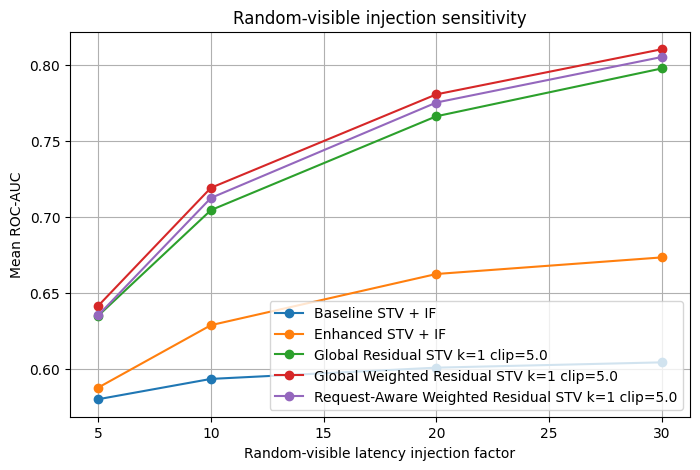

In [129]:
plt.figure(figsize=(8, 5))

for method in RANDOM_VISIBLE_KEY_METHODS:
    mdf = random_visible_sensitivity_key_df[
        random_visible_sensitivity_key_df["method"] == method
    ].copy()

    if mdf.empty:
        continue

    mdf = mdf.sort_values("injection_factor")

    plt.plot(
        mdf["injection_factor"],
        mdf["roc_auc_mean"],
        marker="o",
        label=method
    )

plt.xlabel("Random-visible latency injection factor")
plt.ylabel("Mean ROC-AUC")
plt.title("Random-visible injection sensitivity")
plt.grid(True)
plt.legend()
plt.show()


## Final Summary & Table Pack

Consolidates the key result tables into one folder and prints them for a quick end-to-end audit. Safe to run even if some upstream variables are missing (they'll just be skipped and listed).


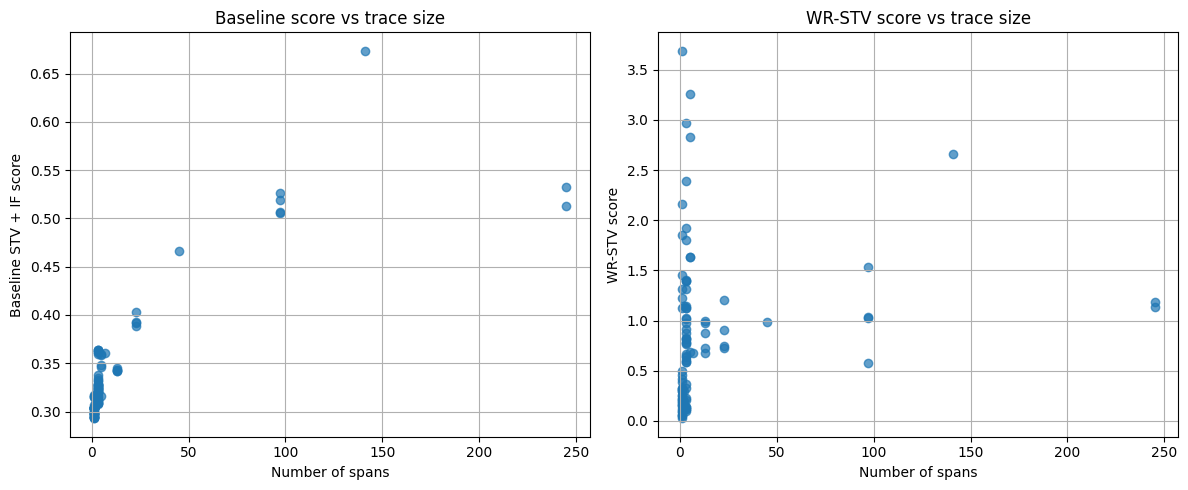

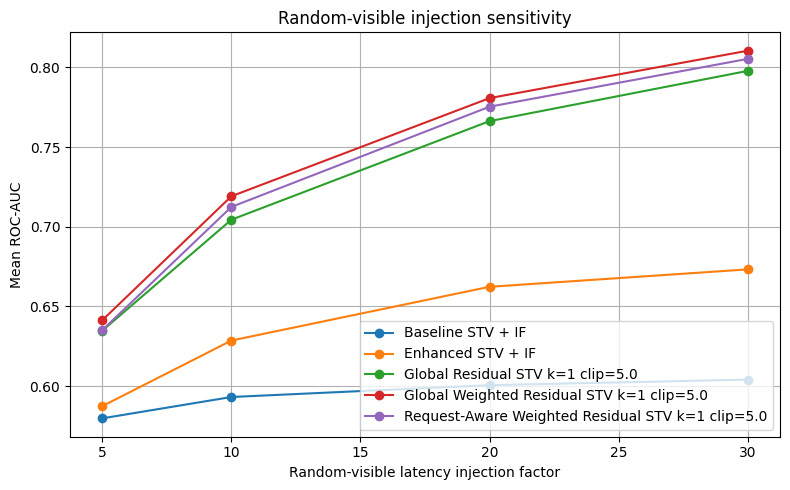

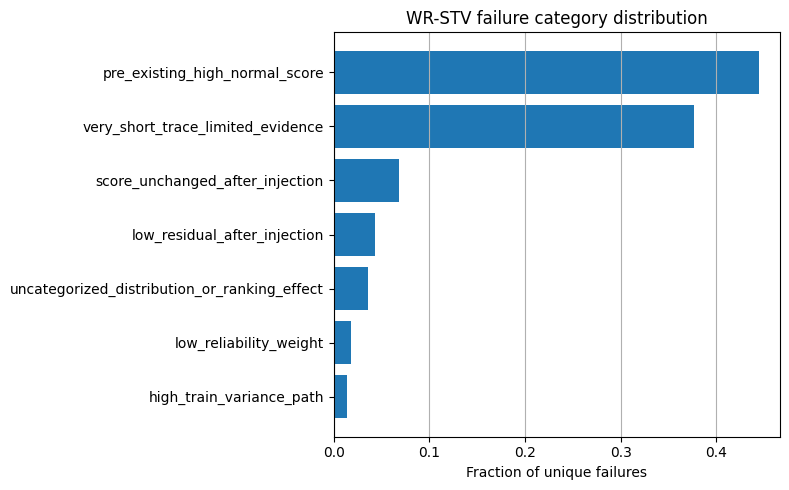

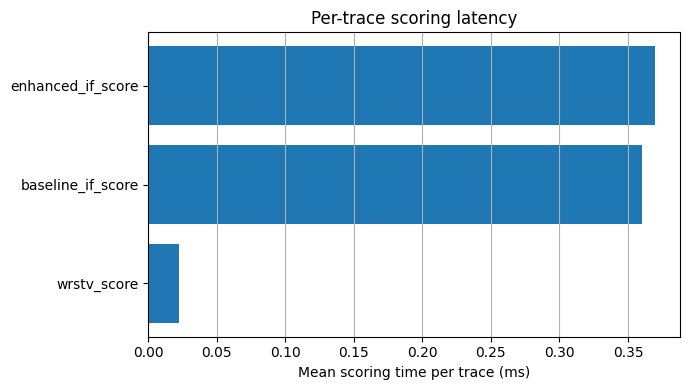

Saved final figures to: /content/drive/MyDrive/anomalies_microservice_trainticket_version_configurations/_processed_phase1/paper_experiment_results/paper_final_figures


In [132]:
FINAL_FIGURE_DIR = RESULTS_DIR / "paper_final_figures"
FINAL_FIGURE_DIR.mkdir(exist_ok=True)

# ------------------------------------------------------------
# Figure 1: Complexity bias scatter, num_spans
# ------------------------------------------------------------
scatter_key = "dataset_1_seed_0"

if "complexity_score_outputs" in globals() and scatter_key in complexity_score_outputs:
    scatter_score_df = complexity_score_outputs[scatter_key]["score_df"].copy()

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.scatter(
        scatter_score_df["num_spans"],
        scatter_score_df["Baseline STV + IF"],
        alpha=0.7
    )
    plt.xlabel("Number of spans")
    plt.ylabel("Baseline STV + IF score")
    plt.title("Baseline score vs trace size")
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.scatter(
        scatter_score_df["num_spans"],
        scatter_score_df["Global Weighted Residual STV k=1"],
        alpha=0.7
    )
    plt.xlabel("Number of spans")
    plt.ylabel("WR-STV score")
    plt.title("WR-STV score vs trace size")
    plt.grid(True)

    plt.tight_layout()
    plt.savefig(
        FINAL_FIGURE_DIR / "fig_complexity_bias_num_spans.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()
else:
    print("Skipping complexity scatter: complexity_score_outputs not available.")


# ------------------------------------------------------------
# Figure 2: Random-visible sensitivity
# ------------------------------------------------------------
if "random_visible_sensitivity_key_df" in globals():
    plt.figure(figsize=(8, 5))

    for method in RANDOM_VISIBLE_KEY_METHODS:
        mdf = random_visible_sensitivity_key_df[
            random_visible_sensitivity_key_df["method"] == method
        ].copy()

        if mdf.empty:
            continue

        mdf = mdf.sort_values("injection_factor")

        plt.plot(
            mdf["injection_factor"],
            mdf["roc_auc_mean"],
            marker="o",
            label=method
        )

    plt.xlabel("Random-visible latency injection factor")
    plt.ylabel("Mean ROC-AUC")
    plt.title("Random-visible injection sensitivity")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig(
        FINAL_FIGURE_DIR / "fig_random_visible_sensitivity_roc_auc.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()
else:
    print("Skipping random-visible sensitivity figure.")


# ------------------------------------------------------------
# Figure 3: Failure category distribution
# ------------------------------------------------------------
if "failure_category_unique_summary_df" in globals():
    plot_df = failure_category_unique_summary_df.sort_values("count", ascending=True)

    plt.figure(figsize=(8, 5))
    plt.barh(plot_df["failure_category"], plot_df["percentage"])
    plt.xlabel("Fraction of unique failures")
    plt.title("WR-STV failure category distribution")
    plt.grid(axis="x")
    plt.tight_layout()
    plt.savefig(
        FINAL_FIGURE_DIR / "fig_failure_categories_unique.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()
else:
    print("Skipping failure category figure.")


# ------------------------------------------------------------
# Figure 4: Runtime scoring latency
# ------------------------------------------------------------
if "scoring_summary_df" in globals():
    plot_df = scoring_summary_df.sort_values("time_per_trace_mean_ms", ascending=True)

    plt.figure(figsize=(7, 4))
    plt.barh(plot_df["stage"], plot_df["time_per_trace_mean_ms"])
    plt.xlabel("Mean scoring time per trace (ms)")
    plt.title("Per-trace scoring latency")
    plt.grid(axis="x")
    plt.tight_layout()
    plt.savefig(
        FINAL_FIGURE_DIR / "fig_runtime_scoring_latency.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()
else:
    print("Skipping runtime figure.")

print("Saved final figures to:", FINAL_FIGURE_DIR)

In [131]:
FINAL_DIR = RESULTS_DIR / "paper_final_tables"
FINAL_DIR.mkdir(exist_ok=True)

_final_exports = {
    "table1_dataset_quality.csv": "quality_df",
    "table2_complexity_bias_baseline.csv": "df",  # per-dataset baseline correlation cell
    "table2b_complexity_bias_all_methods.csv": "main_complexity_bias_pivot",
    "table3_extra_baselines_random_visible.csv": "extra_baseline_summary_df",
    "table4_cross_dataset_key_methods.csv": "cross_key_summary_df",
    "table5_within_stat_tests.csv": "within_stat_tests_df",
    "table6_failure_categories_unique.csv": "failure_category_unique_summary_df",
    "table7_runtime_summary.csv": "method_runtime_summary_df",
    "table8_hyperparameter_validation.csv": "validation_tuning_summary_df",
    "table9_random_visible_sensitivity.csv": "random_visible_sensitivity_key_df",
    "table10_explainability_topk.csv": "explainability_summary_df",
    "table11_cross_dataset_stat_tests.csv": "cross_stat_tests_corrected_df",
    "table12_extra_baseline_stat_tests.csv": "extra_baseline_stat_tests_df",
    "table13_random_visible_monotonicity.csv": "random_visible_monotonicity_df",

}

saved, skipped = [], []

for filename, varname in _final_exports.items():
    obj = globals().get(varname)
    if obj is None:
        skipped.append(varname)
        continue
    try:
        obj.to_csv(FINAL_DIR / filename, index=False)
        saved.append(filename)
    except Exception as exc:
        skipped.append(f"{varname} ({exc})")

print("Saved to", FINAL_DIR)
for f in saved:
    print("  -", f)

if skipped:
    print("\nSkipped (not found in this session, run the corresponding cell above first):")
    for s in skipped:
        print("  -", s)


Saved to /content/drive/MyDrive/anomalies_microservice_trainticket_version_configurations/_processed_phase1/paper_experiment_results/paper_final_tables
  - table1_dataset_quality.csv
  - table2_complexity_bias_baseline.csv
  - table2b_complexity_bias_all_methods.csv
  - table3_extra_baselines_random_visible.csv
  - table4_cross_dataset_key_methods.csv
  - table5_within_stat_tests.csv
  - table6_failure_categories_unique.csv
  - table7_runtime_summary.csv
  - table8_hyperparameter_validation.csv
  - table9_random_visible_sensitivity.csv
  - table10_explainability_topk.csv
  - table11_cross_dataset_stat_tests.csv
  - table12_extra_baseline_stat_tests.csv
  - table13_random_visible_monotonicity.csv
